# Thermal Gradient Figures

TODO:
1. transmission w mux, both peltiers from 50 ->10. 5 degree change every 5 min. Must be stable (within 0.5 deg of target) for at least 1 min.  (~2hr)
2. transmission w mux, starting with 30 +- 0. 1 degree change every 3 min. Must be stable (within 0.5 deg of target) for at least 1 min. (~90 min)

In [39]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonicTesting/')

import pickleJar as pj
import sqliteUtils as squ
import numpy as np
from numpy import fft
import os.path
import matplotlib.pyplot as plt

import pickle

import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from datetime import datetime
import matplotlib.cm as cm


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import Data

In [40]:
def stitch_interp_normalize_pickles(pickleFiles, saveName='combined.pickle', num_points=2500, overwrite=False):
    """
    Stitch together multiple pickle files into one, interpolating the data to a common time base.
    
    Parameters:
    - pickleFiles: list of str, paths to the pickle files to be combined
    - saveName: str, name of the output combined pickle file
    
    Returns:
    - combined_data: dict, the combined data from all pickle files
    """
    combined_data = {'fileName': f'{os.path.split(pickleFiles[0])[0]}/{saveName}', 
                     'parameters': {i: {} for i in range(len(pickleFiles))}}
    
    # check if the pickle file already exists. If it does, print an error message and exit early
    if os.path.isfile(combined_data['fileName']):
        if overwrite:  os.remove(combined_data['fileName'])
        else:
            print("sqliteToPickle Warning: pickle file " + combined_data['fileName'] + " already exists. Conversion aborted.")
            return -1
    
    start, end = 0, 100000
    for i, pickleFile in enumerate(pickleFiles):
        data = pj.loadPickle(pickleFile)
        combined_data['parameters'][i]['original_params'] = data['parameters']
        if data[0]['time'][0]>=start: start = data[0]['time'][0]
        if data[0]['time'][-1]<=end: end = data[0]['time'][-1]
        
    combined_data['parameters']['dt'] = (end-start)/num_points
    idx=0
    
    for i, pickleFile in enumerate(pickleFiles):
        data = pj.loadPickle(pickleFile)
        combined_data['parameters'][i]['file_start_idx'] = int(idx)
        for k,v in data.items():
            if str(k).isdigit(): 
                combined_data[idx] = v.copy()
                combined_data[idx]['time'] = np.linspace(start, end, num_points)
                combined_data[idx]['exp_idx'] = i
                for key in v.keys():
                    if 'voltage' in key:
                        combined_data[idx][key] = np.interp(combined_data[idx]['time'], v['time'], v[key])
                        combined_data[idx][key] -= combined_data[idx][key][-50:].mean() # is there a better way to get the wave on 0?
                        combined_data[idx][key] /= np.max(np.abs(combined_data[idx][key])) # normalize the voltage to [-1, 1]
                idx+=1
        combined_data['parameters'][i]['file_end_idx'] = int(idx)
    
    # save the dataDict as a pickle. We checked if the file exists earlier, so this operation is safe
    with open(combined_data['fileName'], 'wb') as f:
        pickle.dump(combined_data, f)
    
    return combined_data

In [41]:
# First we load the data from the file we want to analyze
# The experiment should always output sqlite3 files, so let's convert them to a more usable pickle form first
sqliteFiles = ['/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/lmfp_cu_mux_avg1782758705.sqlite3',
               '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/lmfp_cu_mux_gradient.sqlite3',
               '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/lmfp_cu_mux_gradient1782763514.sqlite3']

# Convert the sqlite3 to a .pickle
# This takes a few seconds. A progress bar will display in your terminal
pj.multiSqliteToPickle(sqliteFiles)


# Load the pickle
pickleFiles = [os.path.splitext(sqliteFile)[0] + '.pickle' for sqliteFile in sqliteFiles]
data = stitch_interp_normalize_pickles(pickleFiles, saveName='combined.pickle', num_points=2500, overwrite=True)
# data = pj.combineRepeatPulseData([pj.loadPickle(pickle_) for pickle_ in pickleFiles], 
#                           saveName='combined.pickle')


# data = pj.loadPickle(os.path.split(pickleFiles[0])[0]+'/combined.pickle')
# data['parameters']['dt'] = data['parameters']['measureTime']-data['parameters']['measureDelay'] *10-6/ data['parameters']['samples']


Converting /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/lmfp_cu_mux_avg1782758705.sqlite3

sqliteToPickle Warning: pickle file /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/lmfp_cu_mux_avg1782758705.pickle already exists. Conversion aborted.

Converting /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/lmfp_cu_mux_gradient.sqlite3

sqliteToPickle Warning: pickle file /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/lmfp_cu_mux_gradient.pickle already exists. Conversion aborted.

Converting /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/lmfp_cu_mux_gradien

In [18]:
data.keys()

dict_keys(['fileName', 'parameters', 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214

## Merge the waveform and controller data wrt time that UT is running

In [42]:
import pandas as pd
measurements = {k:v for k,v in data.items() if isinstance(k, int)}
waveform_df = pd.DataFrame(measurements).transpose()
waveform_df.head()

,voltage_transmission_forward,voltage_transmission_reverse,time,time_collected,collection_index,exp_idx
0,"[-0.004703905004262971, -0.005783304883992453,...","[-0.005242407446284889, -0.0049487133610443485...","[2750.0, 2751.6998799519806, 2753.399759903961...",1782758706.124326,0.0,0
1,"[-0.004741002055727025, -0.005818312422666706,...","[-0.0037364186517908115, -0.004127439401032553...","[2750.0, 2751.6998799519806, 2753.399759903961...",1782758706.827819,1.0,0
2,"[-0.004887430152995314, -0.00518123152403744, ...","[-0.004689401489779934, -0.004884919931288512,...","[2750.0, 2751.6998799519806, 2753.399759903961...",1782758707.836866,2.0,0
3,"[-0.0055117876654417015, -0.006394045009214263...","[-0.00446893902942821, -0.003687388695569595, ...","[2750.0, 2751.6998799519806, 2753.399759903961...",1782758708.830982,3.0,0
4,"[-0.005252076069830113, -0.005546133859731198,...","[-0.004609962075742181, -0.004120810214756583,...","[2750.0, 2751.6998799519806, 2753.399759903961...",1782758709.854627,4.0,0


In [43]:
## Read in monitor data, add ms to time
from datetime import datetime

monitor_file_path = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/CoSo_2026-06-29_16-39-27_Monitor.csv'
settings_file_path = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/CoSo_2026-06-29_16-39-27_Settings.csv'

controller_monitor_df = pd.read_csv(monitor_file_path,
                            delimiter=';',
                            usecols=[   'Time', 'Milliseconds',
                                        '1000.1: CH1 Object', '1000.2: CH2 Object', # ###.#: is the firmware output for that channel.
                                        '1001.1: CH1 Sink', '1001.2: CH2 Sink',
                                        '1045.1: HR1 Temp', '1045.2: HR2 Temp',
                                        '1044.1: LR1 Temp', '1044.2: LR2 Temp',
                                        '3000.1: CH1 Target', '3000.2: CH2 Target',
                                    ])
controller_monitor_df['Time_str'] = controller_monitor_df['Time']
controller_monitor_df['Time'] = controller_monitor_df['Time'].apply(lambda x: datetime.strptime(x, '%m/%d/%Y %I:%M:%S %p').timestamp())
controller_monitor_df['Time'] += controller_monitor_df['Milliseconds']/1000
controller_monitor_df.drop(columns=['Milliseconds'], inplace=True)

## Read in settings data, add ms to time
controller_settings_df = pd.read_csv(settings_file_path,
                            delimiter=';',
                            usecols=[   'Time', 'Milliseconds',
                                        '2010.1: Output Enable', '2010.2: Output Enable', 
                                        '3034.1: Peltier Polarity', '3034.2: Peltier Polarity',
                                        '1200.1: Temperature is Stable','1200.2: Temperature is Stable'
                                    ])

# to correct later: PID params, max temperature change, )
controller_settings_df['Time'] = controller_settings_df['Time'].apply(lambda x: datetime.strptime(x, '%m/%d/%Y %I:%M:%S %p').timestamp())
controller_settings_df['Time'] += controller_settings_df['Milliseconds']/1000
controller_settings_df.drop(columns=['Milliseconds'], inplace=True)

## Merge monitor and settings data
controller_df = pd.merge_asof(
    left=controller_monitor_df,
    right=controller_settings_df,
    left_on='Time',
    right_on='Time',
    direction='nearest' 
)
## Convert time to float in all dfs
waveform_df['time_collected'] = waveform_df['time_collected'].astype(float)
controller_monitor_df['Time'] = controller_monitor_df['Time'].astype(float)
controller_settings_df['Time'] = controller_settings_df['Time'].astype(float)

## Merge waveform and controller data
merged_df = pd.merge_asof(
    left=waveform_df,
    right=controller_df,
    left_on='time_collected',
    right_on='Time',
    direction='nearest' 
)
## reformat time Time_str to '%m/%d/%y %H:%M:%S'
merged_df['Time_str'] = pd.to_datetime(merged_df['Time_str']).dt.strftime('%m/%d/%y %H:%M:%S')
merged_df.to_csv('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/merged_df.csv')

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_45442/930824303.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['Time_str'] = pd.to_datetime(merged_df['Time_str']).dt.strftime('%m/%d/%y %H:%M:%S')


In [21]:
merged_df.tail()

,voltage_transmission_forward,voltage_transmission_reverse,time,time_collected,collection_index,exp_idx,Time,1000.1: CH1 Object,1000.2: CH2 Object,1001.1: CH1 Sink,...,1045.2: HR2 Temp,3000.1: CH1 Target,3000.2: CH2 Target,Time_str,1200.1: Temperature is Stable,1200.2: Temperature is Stable,2010.1: Output Enable,2010.2: Output Enable,3034.1: Peltier Polarity,3034.2: Peltier Polarity
6036,"[0.029099664070462942, 0.028495232524462184, 0...","[0.028174271162335174, 0.027405415212898434, 0...","[2750.0, 2751.6998799519806, 2753.399759903961...",1.782766e+09,2026.0,2,1.782766e+09,40.912315,20.965601,21.441370,...,20.965601,41.0,19.0,06/29/26 16:39:02,2,1,OFF,ON,Cooling,Cooling
6037,"[0.02884230542359809, 0.029185658127258846, 0....","[0.02918453383825964, 0.028331974786818676, 0....","[2750.0, 2751.6998799519806, 2753.399759903961...",1.782766e+09,2027.0,2,1.782766e+09,40.922081,21.147058,21.490076,...,21.147058,41.0,19.0,06/29/26 16:39:03,2,1,OFF,ON,Cooling,Cooling
6038,"[0.02934116269467721, 0.029342077944093367, 0....","[0.027209515240106164, 0.029510668243487054, 0...","[2750.0, 2751.6998799519806, 2753.399759903961...",1.782766e+09,2028.0,2,1.782766e+09,40.257500,21.509150,21.578272,...,21.509150,41.0,19.0,06/29/26 16:39:04,0,1,OFF,OFF,Cooling,Cooling
6039,"[0.02807913908744862, 0.027993755698033102, 0....","[0.029364304267846458, 0.028767442625174954, 0...","[2750.0, 2751.6998799519806, 2753.399759903961...",1.782766e+09,2029.0,2,1.782766e+09,39.263481,21.963800,21.641718,...,21.963800,41.0,19.0,06/29/26 16:39:05,0,1,OFF,OFF,Cooling,Cooling
6040,"[0.028615505055264615, 0.030158177218304383, 0...","[0.028161380989139576, 0.030122171841728884, 0...","[2750.0, 2751.6998799519806, 2753.399759903961...",1.782766e+09,2030.0,2,1.782766e+09,37.803429,23.848932,21.711267,...,23.848932,41.0,19.0,06/29/26 16:39:07,0,1,OFF,OFF,Cooling,Cooling


## calculate tof and amplitudes

In [44]:
merged_df['index'] = merged_df.index
merged_df['mean_T (°C)'] = merged_df[['1000.1: CH1 Object', '1000.2: CH2 Object']].mean(axis=1)
merged_df['diff_T (°C)'] = merged_df['1000.1: CH1 Object'] - merged_df['1000.2: CH2 Object']

for key_ in ['_forward', '_reverse']:    
    merged_df['amplitude'+key_+'_normalized'] = list(map(pj.maxMinusMin, merged_df['voltage_transmission'+key_]))
    merged_df['Simple_ToF'+key_+' (ns)'] = list(map(pj.simpleThresholdTOF, merged_df['voltage_transmission'+key_], merged_df['time'], [0.15,] * len(merged_df)))
    merged_df['Hilbert_ToF'+key_+' (ns)'] = list(map(pj.envelopeThresholdTOF, merged_df['voltage_transmission'+key_], merged_df['time'], [0.15,] * len(merged_df)))

In [45]:
plt.clf()
plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 16,
        'figure.dpi': 300,
        'savefig.dpi': 300,
    })

def plot_waveform(i):
    fig,ax = plt.subplots(figsize=(8, 4))
               
    ax.plot(merged_df['time'][i], merged_df['voltage_transmission_forward'][i], lw=1, label='forward')
    ax.vlines(merged_df['Simple_ToF_forward (ns)'][i], -1, 1, color='red', lw=1, linestyles='--', label='Simple ToF forward')
    ax.vlines(merged_df['Hilbert_ToF_forward (ns)'][i], -1, 1, color='blue', lw=1, linestyles='--', label='Hilbert ToF forward')
    
    ax.plot(merged_df['time'][i], merged_df['voltage_transmission_reverse'][i], lw=1, label='reverse')
    ax.vlines(merged_df['Simple_ToF_reverse (ns)'][i], -1, 1, color='orange', lw=1, linestyles='--', label='Simple ToF reverse')
    ax.vlines(merged_df['Hilbert_ToF_reverse (ns)'][i], -1, 1, color='green', lw=1, linestyles='--', label='Hilbert ToF reverse')
    
    
    ax.set_title(f'Measurement {i} at ({merged_df["Time_str"][i]})')
    ax.set_ylim(-1, 1)
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Voltage Normalized')
    
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol=2)
    fig.tight_layout()

<Figure size 1920x1440 with 0 Axes>

In [24]:
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(merged_df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

interact(plot_waveform, i=slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='measurement:', max=6040), Outpu…

<function __main__.plot_waveform(i)>

## Experimental conditions v amplitude and tof

In [82]:
## with dT on x axis 
df = merged_df

def plot_temps(i=0, keys_=(), idx_lable_type='', line_width=1, markersize=0.01, include_vline=True):
    """Plot temperature data with optional secondary variables.

    Parameters
    ----------
    i : int, optional
        Index of the measurement to highlight.
    keys_ : tuple or list of str, optional
        Additional columns to plot on a secondary y-axis.
    idx_lable_type : str, optional
        Type of x-axis labels to use ('time', 'dT', 'T').
    """
    
    xticks_labels = df['index'].astype(str) + ': ' + df['Time_str']
    xticks = df['time_collected'].values

    fig, ax1 = plt.subplots(figsize=(8, 6))

    # plot temperature data vs ΔT
    ax1.plot(xticks, df['mean_T (°C)'], label='mean', marker='o', linestyle='-', linewidth=line_width, markersize=markersize)
    lower_bound = df['mean_T (°C)'] - df['diff_T (°C)'] / 2
    ax1.plot(xticks, lower_bound, label='transmitter side', linestyle='--', linewidth=line_width, marker='o', markersize=markersize)
    upper_bound = df['mean_T (°C)'] + df['diff_T (°C)'] / 2
    ax1.plot(xticks, upper_bound, label='receiver side', linestyle='--', linewidth=line_width, marker='o', markersize=markersize)
    ax1.fill_between(xticks, lower_bound, upper_bound, alpha=0.25)
    if include_vline:
        ax1.axvline(xticks[i], color='red', linestyle='--', linewidth=0.8, alpha=0.4)

    # plot secondary keys
    if len(keys_) > 0:
        ax2 = ax1.twinx()  # second y-axis sharing x-axis
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        start_idx = 3
        for idx, key_ in enumerate(keys_):
            ax2.scatter(xticks, df[key_], label=key_, s=10, color=colors[start_idx + idx])
        ax2.set_ylabel('\n'.join([f'{key_}' for key_ in keys_]))
        
    # formatting
    ax1.set_title('Temperature gradient vs ΔT')
    ax1.set_ylabel('Temperature (°C)')
    ax1.set_ylim(0, 60)
    if idx_lable_type == 'time':
        ax1.set_xticks(ticks=xticks[::max(1, len(xticks_labels)//15)], 
                       labels=xticks_labels[::max(1, len(xticks_labels)//15)], 
                       rotation=45, ha='right')
        ax1.set_xlabel('Collection idx: Time')
        
    elif idx_lable_type == 'dT':
        x = (df['3000.1: CH1 Target'] - df['3000.2: CH2 Target']).values
        t_change_idx = np.flatnonzero(np.diff(x, prepend=x[0]) != 0).tolist()
        diffs = np.diff(t_change_idx, prepend=t_change_idx[0])
        for j in range(len(t_change_idx) - 1, 0, -1):
            if diffs[j] < 20: t_change_idx.pop(j)
        t_change_idx = np.asarray(t_change_idx, dtype=int)
        
        # for idx in t_change_idx: # plot temp changes
        ax1.set_xticks(ticks=xticks[t_change_idx][::2], 
                       labels=x[t_change_idx][::2], rotation=45, ha='right')
        ax1.set_xlabel('Target ΔT (°C)')
        for idx in t_change_idx: ax1.axvline(xticks[idx], color='gray', linestyle='--', linewidth=0.8, alpha=0.4)
        
    elif idx_lable_type == 'T':
        x = df['3000.1: CH1 Target'].values
        t_change_idx = np.flatnonzero(np.diff(x, prepend=x[0]) != 0).tolist()
        diffs = np.diff(t_change_idx, prepend=t_change_idx[0])
        for j in range(len(t_change_idx) - 1, 0, -1):
            if diffs[j] < 30: t_change_idx.pop(j)
        t_change_idx = np.asarray(t_change_idx, dtype=int)
        ax1.set_xticks(ticks=xticks[t_change_idx], 
                       labels=x[t_change_idx], rotation=45, ha='right')
        ax1.set_xlabel('Target Temperature (°C)')
        for idx in t_change_idx: ax1.axvline(xticks[idx], color='gray', linestyle='--', linewidth=0.8, alpha=0.4)
    
    else:
        ax1.set_xticks([])
        ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    
    fig.legend(bbox_to_anchor=(0.5, 0.03), loc='upper center', ncols=min(max(len(keys_)//2+1,1), 3))
    fig.tight_layout()


### unfiltered

In [47]:
df = merged_df

def run_plotter(i=0, keys_=()):
    plot_temps(i=i, keys_=list(keys_), idx_lable_type='dT')
    

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

selected_keys = [col for col in df.columns if col.startswith(('Simple_ToF', 'Hilbert_ToF', 'amplitude'))]
selected_keys.sort()
keys = widgets.SelectMultiple(
    options=selected_keys,
    value=tuple([]),
    description='Variable:',
    disabled=False,
)

interact(lambda i, key_: run_plotter(i=i, keys_=list(key_)), i=slider, key_=keys)

interactive(children=(IntSlider(value=0, continuous_update=False, description='measurement:', max=6040), Selec…

<function __main__.<lambda>(i, key_)>

### Subtract out overal trends in amplitude and tof

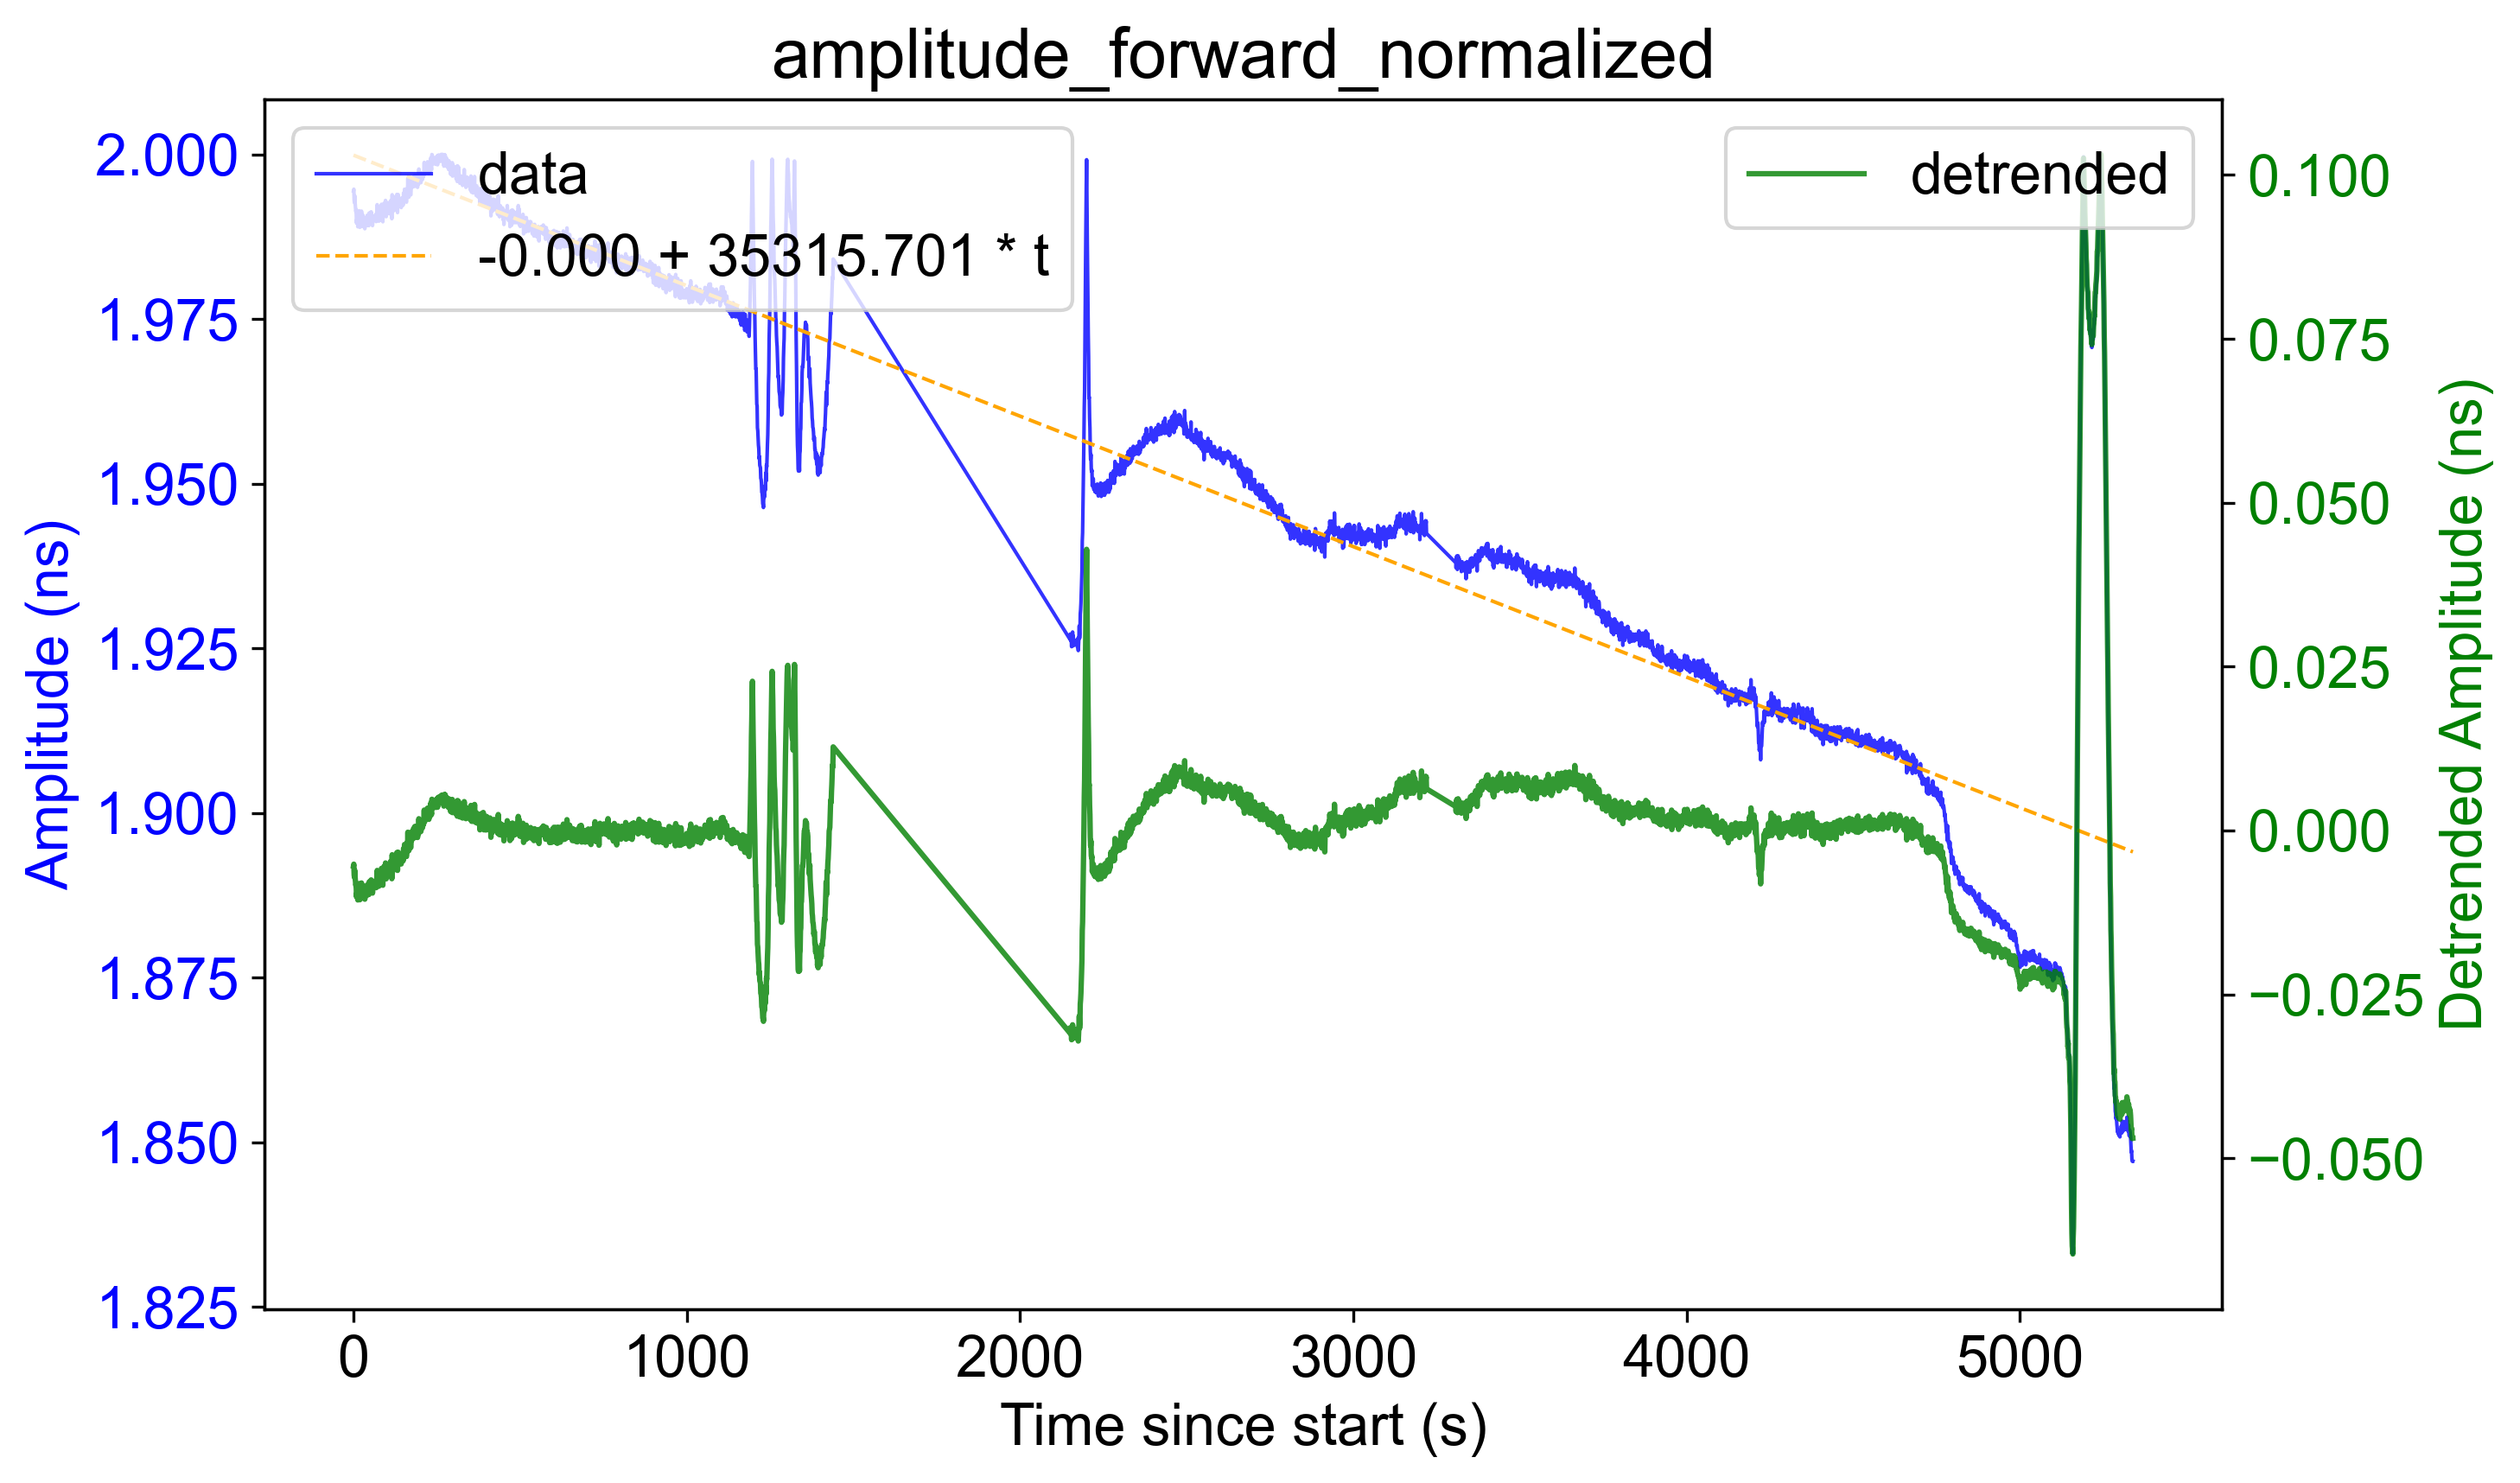

In [28]:
# before/ater detrending amplitude
df = merged_df.iloc[1500:]
k = 'amplitude_forward_normalized'
a,b = np.polyfit(df['time_collected'], df[k], 1)
fit = a * df['time_collected'] + b
t_rel = df['time_collected'] - df['time_collected'].iloc[0]

plt.figure(figsize=(10, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()
    
ax1.plot(t_rel, df[k], label='data', alpha=0.8, color='blue', lw=1)
ax1.plot(t_rel, fit, label=f'{a:.3f} + {b:.3f} * t', lw=1, linestyle='--', color='orange')
ax1.set_xlabel('Time since start (s)')
ax1.set_ylabel('Amplitude (ns)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2.plot(t_rel, df[k] - fit, label='detrended', alpha=0.8, color='green')
ax2.set_ylabel('Detrended Amplitude (ns)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title(k)
plt.tight_layout()
plt.show()

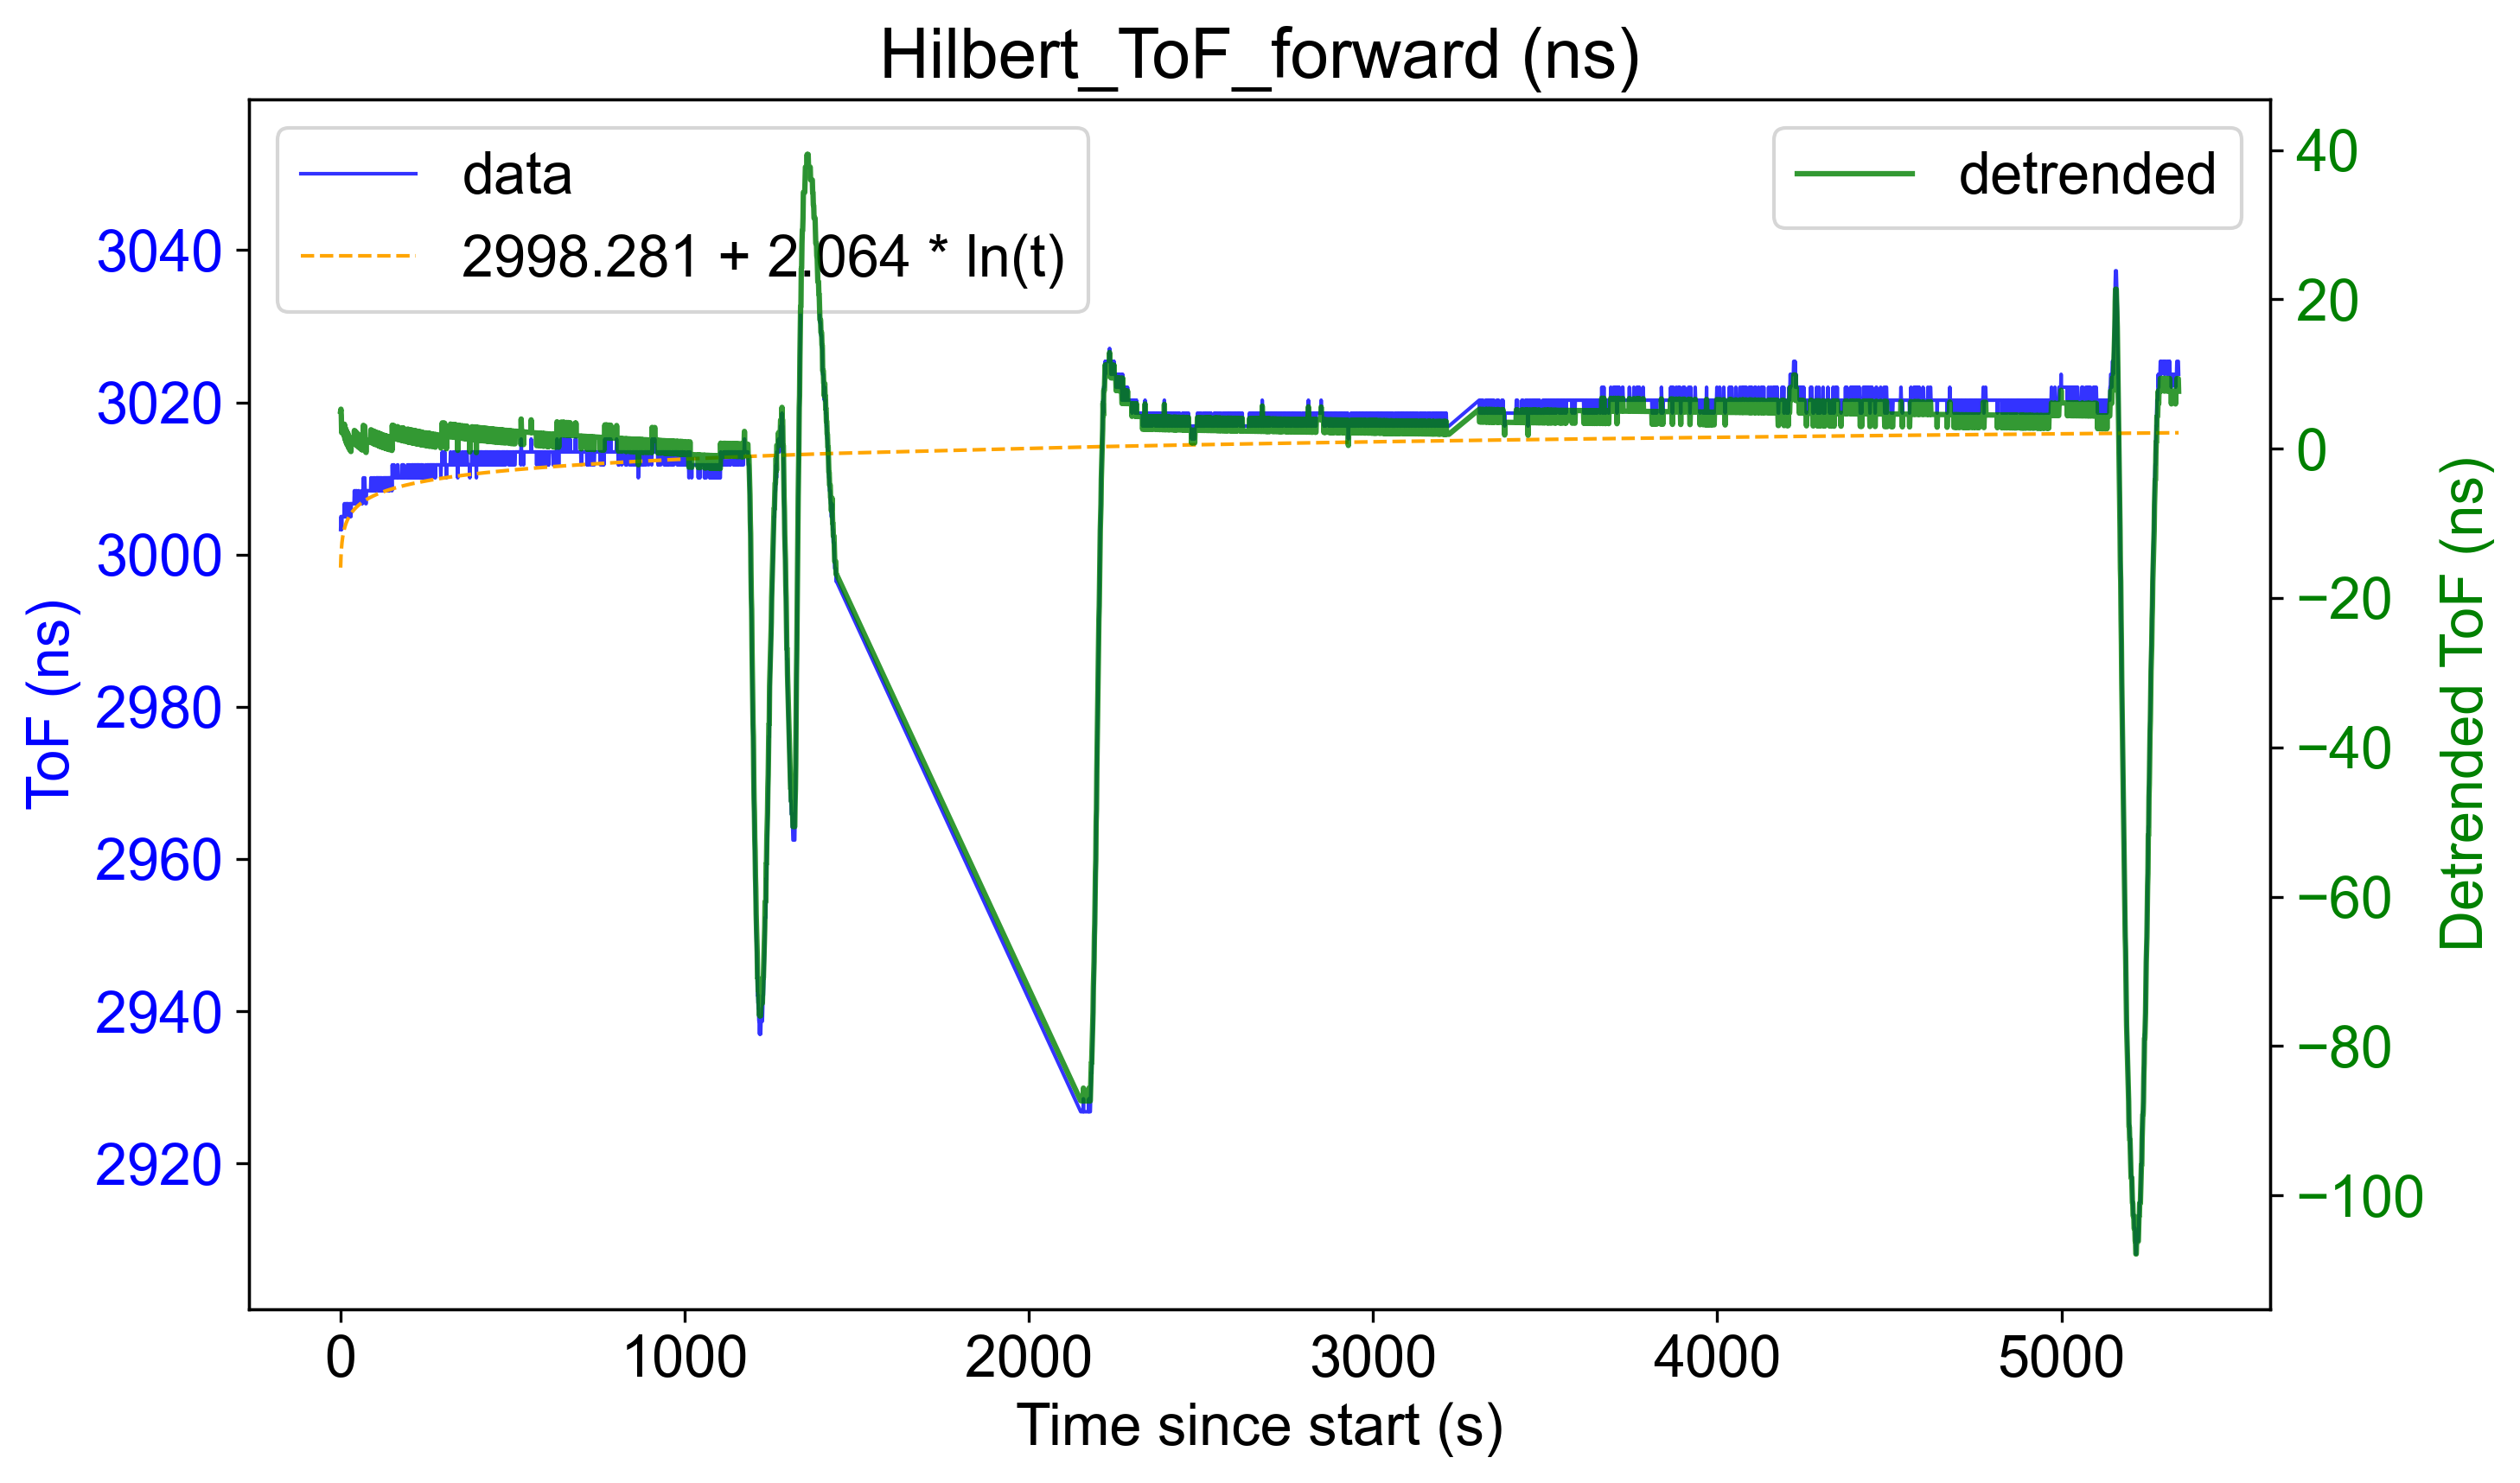

In [13]:
# before/after detrednging tof
from scipy.optimize import curve_fit

df = merged_df.iloc[1500:].copy()
k = 'Hilbert_ToF_forward (ns)'

# use relative time to keep log-fit numerically stable
t = df['time_collected'].to_numpy(dtype=float)
y = df[k].to_numpy(dtype=float)
t0 = t.min()
t_rel = t - t0 + 1.0  # strictly > 0 for log

def log_func(t_rel, a, b): return a + b * np.log(t_rel)

popt, _ = curve_fit(log_func, t_rel, y, maxfev=20000)
fit = log_func(t_rel, *popt)

plt.figure(figsize=(10, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(t_rel, y, label='data', alpha=0.8, color='blue', lw=1)
ax1.plot(t_rel, fit, label=f'{popt[0]:.3f} + {popt[1]:.3f} * ln(t)', lw=1, linestyle='--', color='orange')
ax1.set_xlabel('Time since start (s)')
ax1.set_ylabel('ToF (ns)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2.plot(t_rel, y - fit, label='detrended', alpha=0.8, color='green')
ax2.set_ylabel('Detrended ToF (ns)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title(k)
plt.tight_layout()
plt.show()


In [9]:
# detrend data func
from scipy.optimize import curve_fit

def detrend_filtered_data(df, amplitude_keys=None, tof_keys=None):
    """
    Detrend amplitude and ToF data using polynomial and logarithmic fits.
    
    Parameters:
    - df: pandas.DataFrame, the filtered dataframe to detrend
    - amplitude_keys: list of str, column names for amplitude data to detrend (default: forward and reverse)
    - tof_keys: list of str, column names for ToF data to detrend (default: Hilbert and Simple ToF)
    
    Returns:
    - df: pandas.DataFrame, the detrended dataframe (modifies in place)
    """
    if amplitude_keys is None:  amplitude_keys = ['amplitude_forward_normalized', 'amplitude_reverse_normalized']
    
    if tof_keys is None: tof_keys = ['Hilbert_ToF_forward (ns)', 'Hilbert_ToF_reverse (ns)', 
                                     'Simple_ToF_forward (ns)', 'Simple_ToF_reverse (ns)']
    
    # Detrend amplitude with linear fit
    for k in amplitude_keys:
        a, b = np.polyfit(df['time_collected'], df[k], 1)
        fit = a * df['time_collected'] + b
        df[k] -= fit
    
    # Detrend ToF with logarithmic fit
    def log_func(t_rel, a, b): 
        return a + b * np.log(t_rel)
    
    t = df['time_collected'].to_numpy(dtype=float)
    t0 = t.min()
    t_rel = t - t0 + 1.0  # strictly > 0 for log
    
    for k in tof_keys:
        y = df[k].to_numpy(dtype=float)
        popt, _ = curve_fit(log_func, t_rel, y, maxfev=20000)
        fit = log_func(t_rel, *popt)
        df[k] -= fit
    
    return df

In [42]:
# detrend/interactive visualizer

df = merged_df.iloc[1500:]
df = detrend_filtered_data(df)

def run_plotter(i=0, keys_=()): plot_temps(i=i, keys_=list(keys_), idx_lable_type='dT')

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

selected_keys = [col for col in df.columns if col.startswith(('Simple_ToF', 'Hilbert_ToF', 'amplitude'))]
selected_keys.sort()
keys = widgets.SelectMultiple(
    options=selected_keys,
    value=tuple([]),
    description='Variable:',
    disabled=False,
)

interact(lambda i, key_: run_plotter(i=i, keys_=list(key_)), i=slider, key_=keys)

### Filter out outliers (+/- 0.25 from target)

In [86]:
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from datetime import datetime

# calculate mask
mask = ( (merged_df['1000.1: CH1 Object'] - merged_df['3000.1: CH1 Target']).abs() < 0.5  
   ) & ( (merged_df['1000.2: CH2 Object'] - merged_df['3000.2: CH2 Target']).abs() < 0.5 )

# detrend after 1500 bc that is when gradient exp starts
# merged_df.iloc[1500:] = detrend_filtered_data(merged_df.iloc[1500:])

# filter
merged_filtered_df = merged_df.loc[mask].copy().reset_index(drop=True)

In [87]:
df = merged_filtered_df

def run_plotter(i=0, keys_=()): plot_temps(i=i, keys_=list(keys_), idx_lable_type='', line_width=1, markersize=0.01, include_vline=False)

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

selected_keys = [col for col in df.columns if col.startswith(('Hilbert_ToF', 'amplitude'))]
selected_keys.sort()
keys = widgets.SelectMultiple(
    options=selected_keys,
    value=tuple([]),
    description='Variable:',
    disabled=False,
)

interact(lambda i, key_: run_plotter(i=i, keys_=list(key_)), i=slider, key_=keys)

interactive(children=(IntSlider(value=0, continuous_update=False, description='measurement:', max=4407), Selec…

<function __main__.<lambda>(i, key_)>

## plot mean + stdv tof and amplitudes against temperature

### avg

https://www.mdpi.com/1424-8220/25/2/385 this article uses 2nd order polynomial on speed of sound. But our amplitude was the polynoial like fit


In [73]:
# fit means and tof
import matplotlib.pyplot as plt

temps = range(10,55,5)
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []
f_simple_tof_arr, f_simple_tof_err = [], []
r_simple_tof_arr, r_simple_tof_err = [], []
f_hilbert_tof_arr, f_hilbert_tof_err = [], []
r_hilbert_tof_arr, r_hilbert_tof_err = [], []

for i in temps:
    mask =  (merged_filtered_df['3000.1: CH1 Target'] == i) & \
            (merged_filtered_df['3000.2: CH2 Target'] == i) & \
            (merged_filtered_df.index < 996)
    filtered_df = merged_filtered_df[mask]
    
    if filtered_df.empty: 
        print(i)
        continue
    
    
    f_amp_arr.append(filtered_df[f'amplitude_forward_normalized'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward_normalized'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse_normalized'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse_normalized'].std())
    
    f_simple_tof_arr.append(filtered_df[f'Simple_ToF_forward (ns)'].mean())
    f_simple_tof_err.append(filtered_df[f'Simple_ToF_forward (ns)'].std())
    
    r_simple_tof_arr.append(filtered_df[f'Simple_ToF_reverse (ns)'].mean())
    r_simple_tof_err.append(filtered_df[f'Simple_ToF_reverse (ns)'].std())
    
    f_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_forward (ns)'].mean())
    f_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_forward (ns)'].std())
    
    r_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].mean())
    r_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].std())
    
f_amp_fit = np.polyfit(temps, f_amp_arr, 2)
f_amp_fit = f_amp_fit[0] * np.array(temps)**2 + f_amp_fit[1] * np.array(temps) + f_amp_fit[2]
r_amp_fit = np.polyfit(temps, r_amp_arr, 2)
r_amp_fit = r_amp_fit[0] * np.array(temps)**2 + r_amp_fit[1] * np.array(temps) + r_amp_fit[2]
f_amp_residuals = f_amp_arr - f_amp_fit
r_amp_residuals = r_amp_arr - r_amp_fit

f_simple_tof_fit = np.polyfit(temps, f_simple_tof_arr, 1)
f_simple_tof_fit = f_simple_tof_fit[0] * np.array(temps) + f_simple_tof_fit[1]
r_simple_tof_fit = np.polyfit(temps, r_simple_tof_arr, 1)
r_simple_tof_fit = r_simple_tof_fit[0] * np.array(temps) + r_simple_tof_fit[1]
f_simple_tof_residuals = f_simple_tof_arr - f_simple_tof_fit
r_simple_tof_residuals = r_simple_tof_arr - r_simple_tof_fit

f_hilbert_tof_fit = np.polyfit(temps, f_hilbert_tof_arr, 1)
f_hilbert_tof_fit = f_hilbert_tof_fit[0] * np.array(temps) + f_hilbert_tof_fit[1]
r_hilbert_tof_fit = np.polyfit(temps, r_hilbert_tof_arr, 1)
r_hilbert_tof_fit = r_hilbert_tof_fit[0] * np.array(temps) + r_hilbert_tof_fit[1]
f_hilbert_tof_residuals = f_hilbert_tof_arr - f_hilbert_tof_fit
r_hilbert_tof_residuals = r_hilbert_tof_arr - r_hilbert_tof_fit

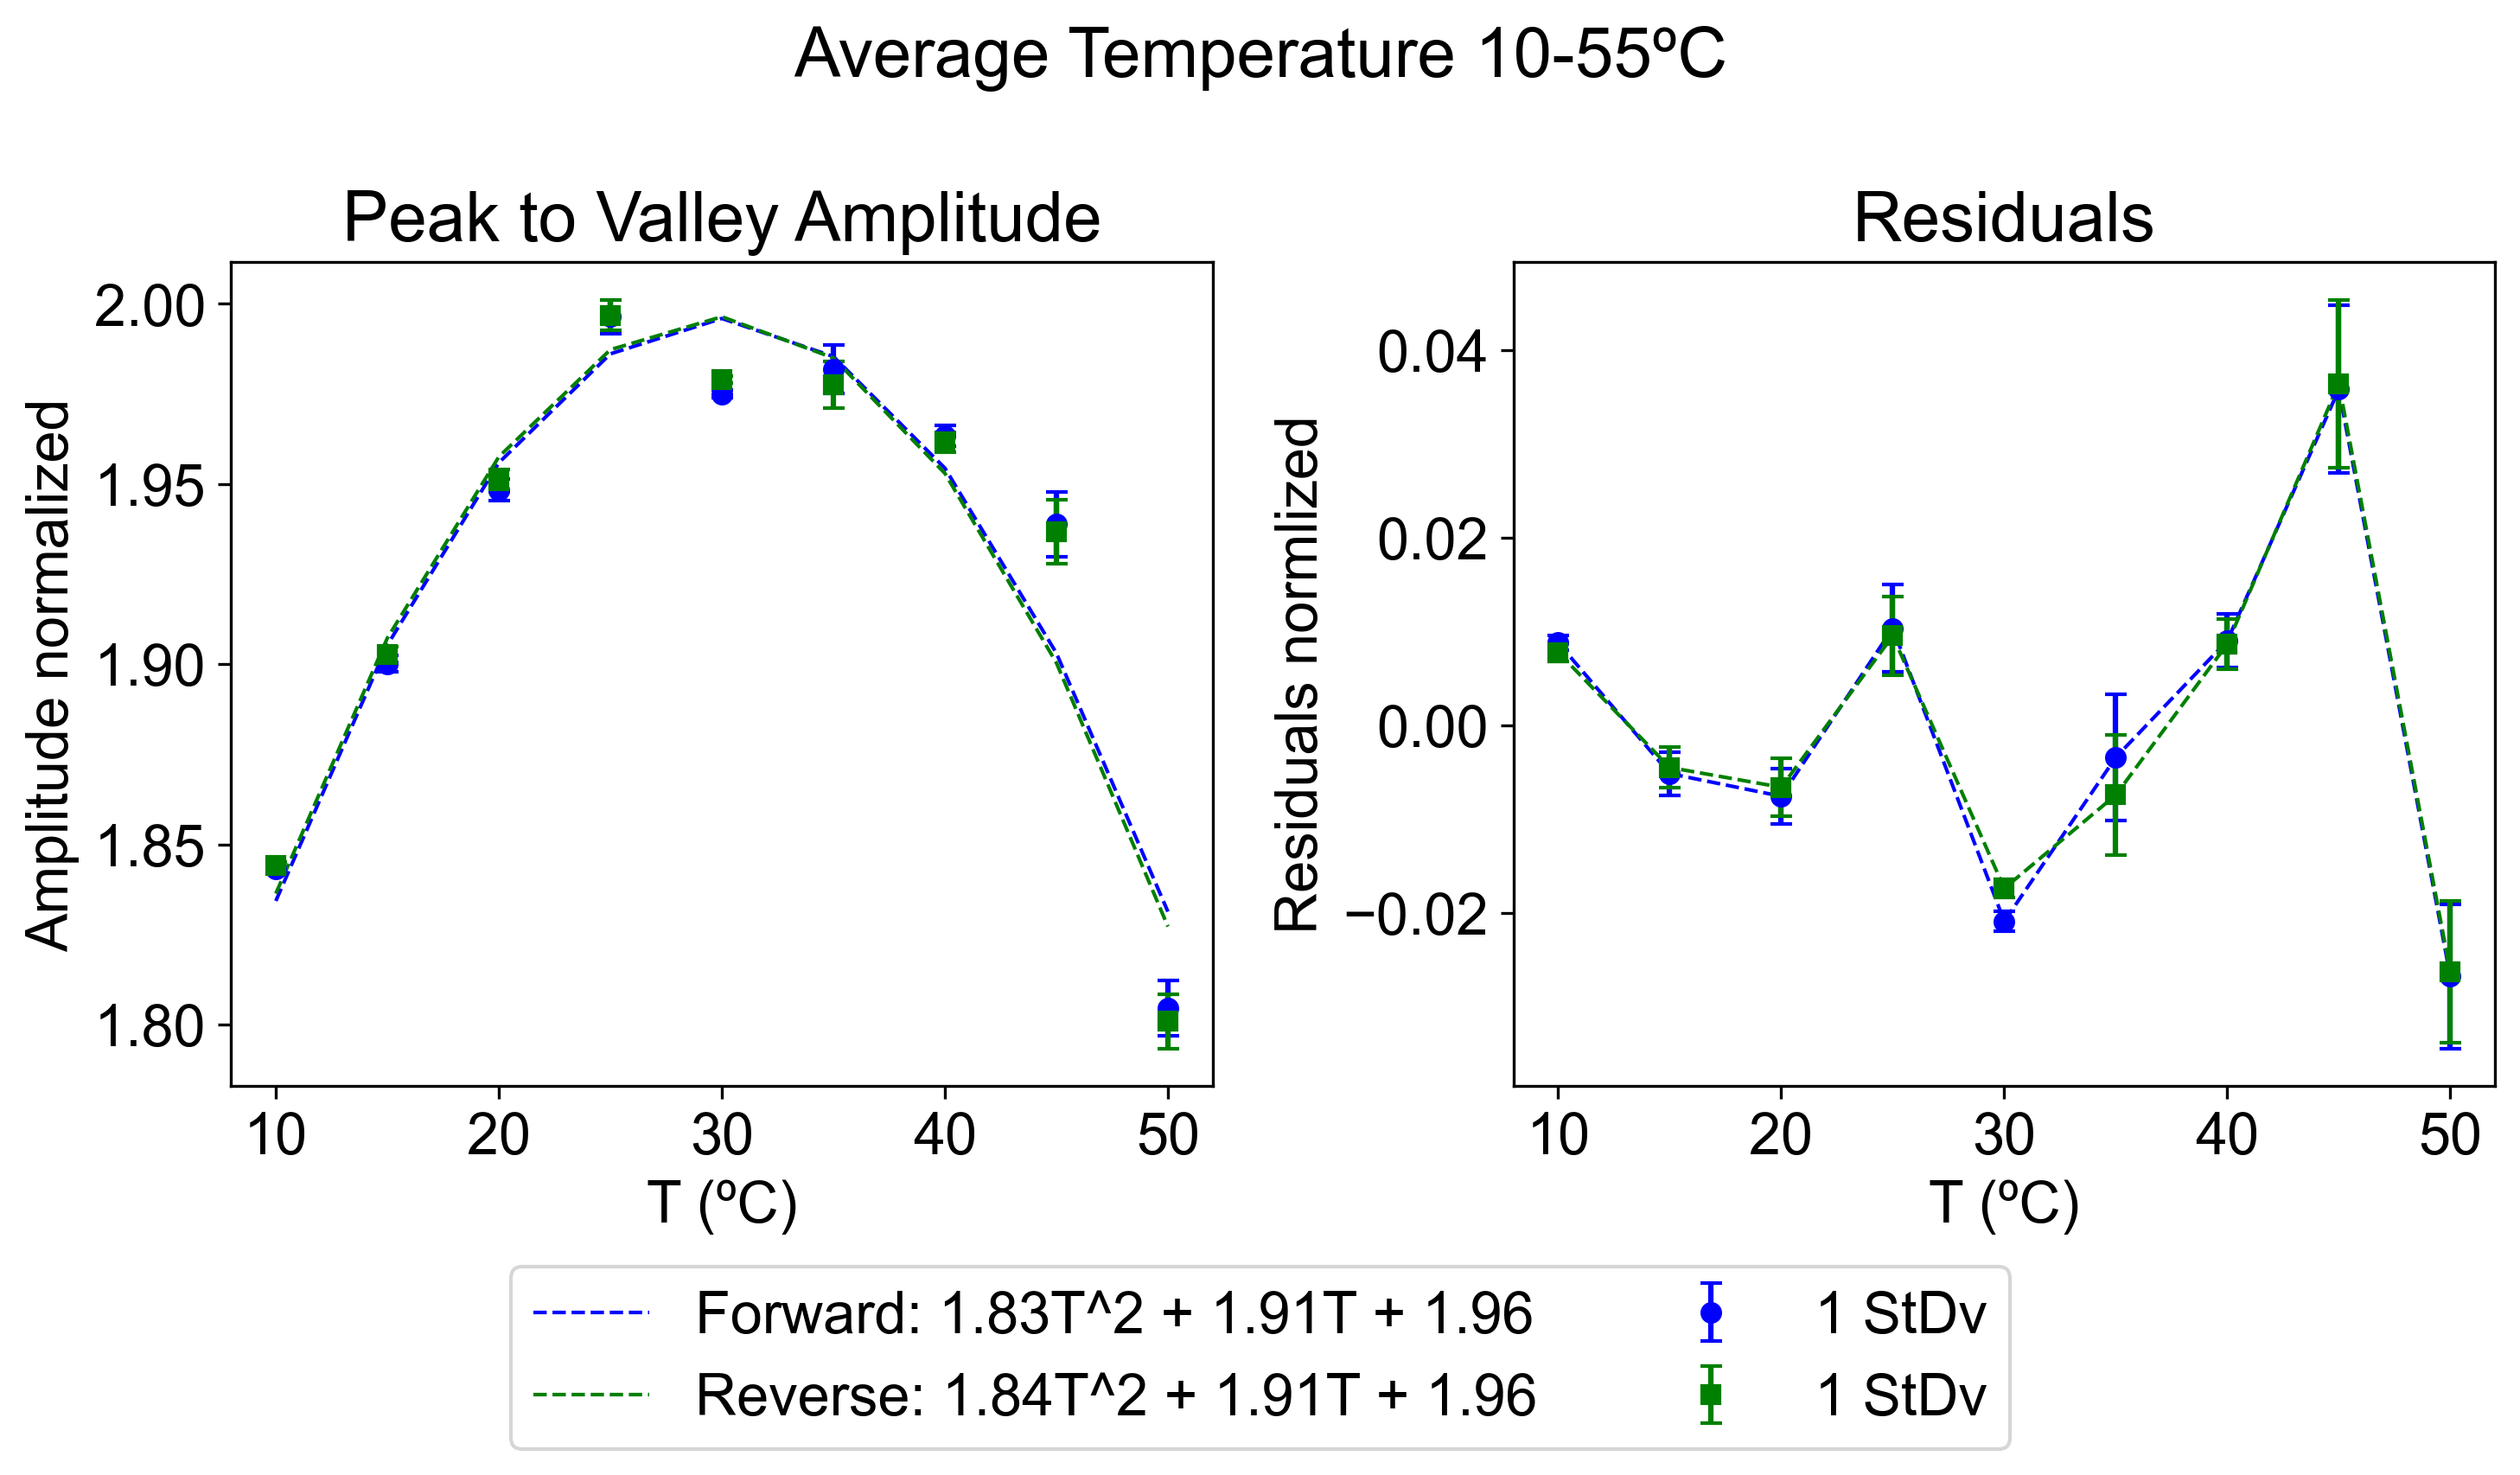

In [74]:
# plot amplitudes
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Average Temperature 10-55ºC')

ax[0].plot(temps, f_amp_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_amp_fit[0]:.2f}T^2 + {f_amp_fit[1]:.2f}T + {f_amp_fit[2]:.2f}')
ax[0].errorbar(temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(temps, r_amp_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_amp_fit[0]:.2f}T^2 + {r_amp_fit[1]:.2f}T + {r_amp_fit[2]:.2f}')
ax[0].errorbar(temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('Peak to Valley Amplitude')
ax[0].set_xlabel('T (ºC)')
ax[0].set_ylabel('Amplitude normalized')

ax[1].plot(temps, f_amp_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(temps, f_amp_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(temps, r_amp_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(temps, r_amp_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('T (ºC)')
ax[1].set_ylabel('Residuals normlized')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

In [75]:
# fig, ax = plt.subplots(1,2, figsize=(10,5))
# fig.suptitle('Average Temperature 10-55ºC')

# ax[0].plot(temps, f_simple_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_simple_tof_fit[0]:.2f}T + {f_simple_tof_fit[1]:.2f} (ns)')
# ax[0].errorbar(temps, f_simple_tof_arr, yerr=f_simple_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
# ax[0].plot(temps, r_simple_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_simple_tof_fit[0]:.2f}T + {r_simple_tof_fit[1]:.2f} (ns)')
# ax[0].errorbar(temps, r_simple_tof_arr, yerr=r_simple_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
# ax[0].set_title('15% threshold ToF')
# ax[0].set_xlabel('T (ºC)')
# ax[0].set_ylabel('ToF (ns)' )

# ax[1].plot(temps, f_simple_tof_residuals, color='blue', linewidth=1, linestyle='--')
# ax[1].errorbar(temps, f_simple_tof_residuals, yerr=f_simple_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
# ax[1].plot(temps, r_simple_tof_residuals, color='green', linewidth=1, linestyle='--',)
# ax[1].errorbar(temps, r_simple_tof_residuals, yerr=r_simple_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
# ax[1].set_title('Residuals')
# ax[1].set_xlabel('T (ºC)')
# ax[1].set_ylabel('ToF (ns) Residuals')

# fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

# fig.tight_layout()

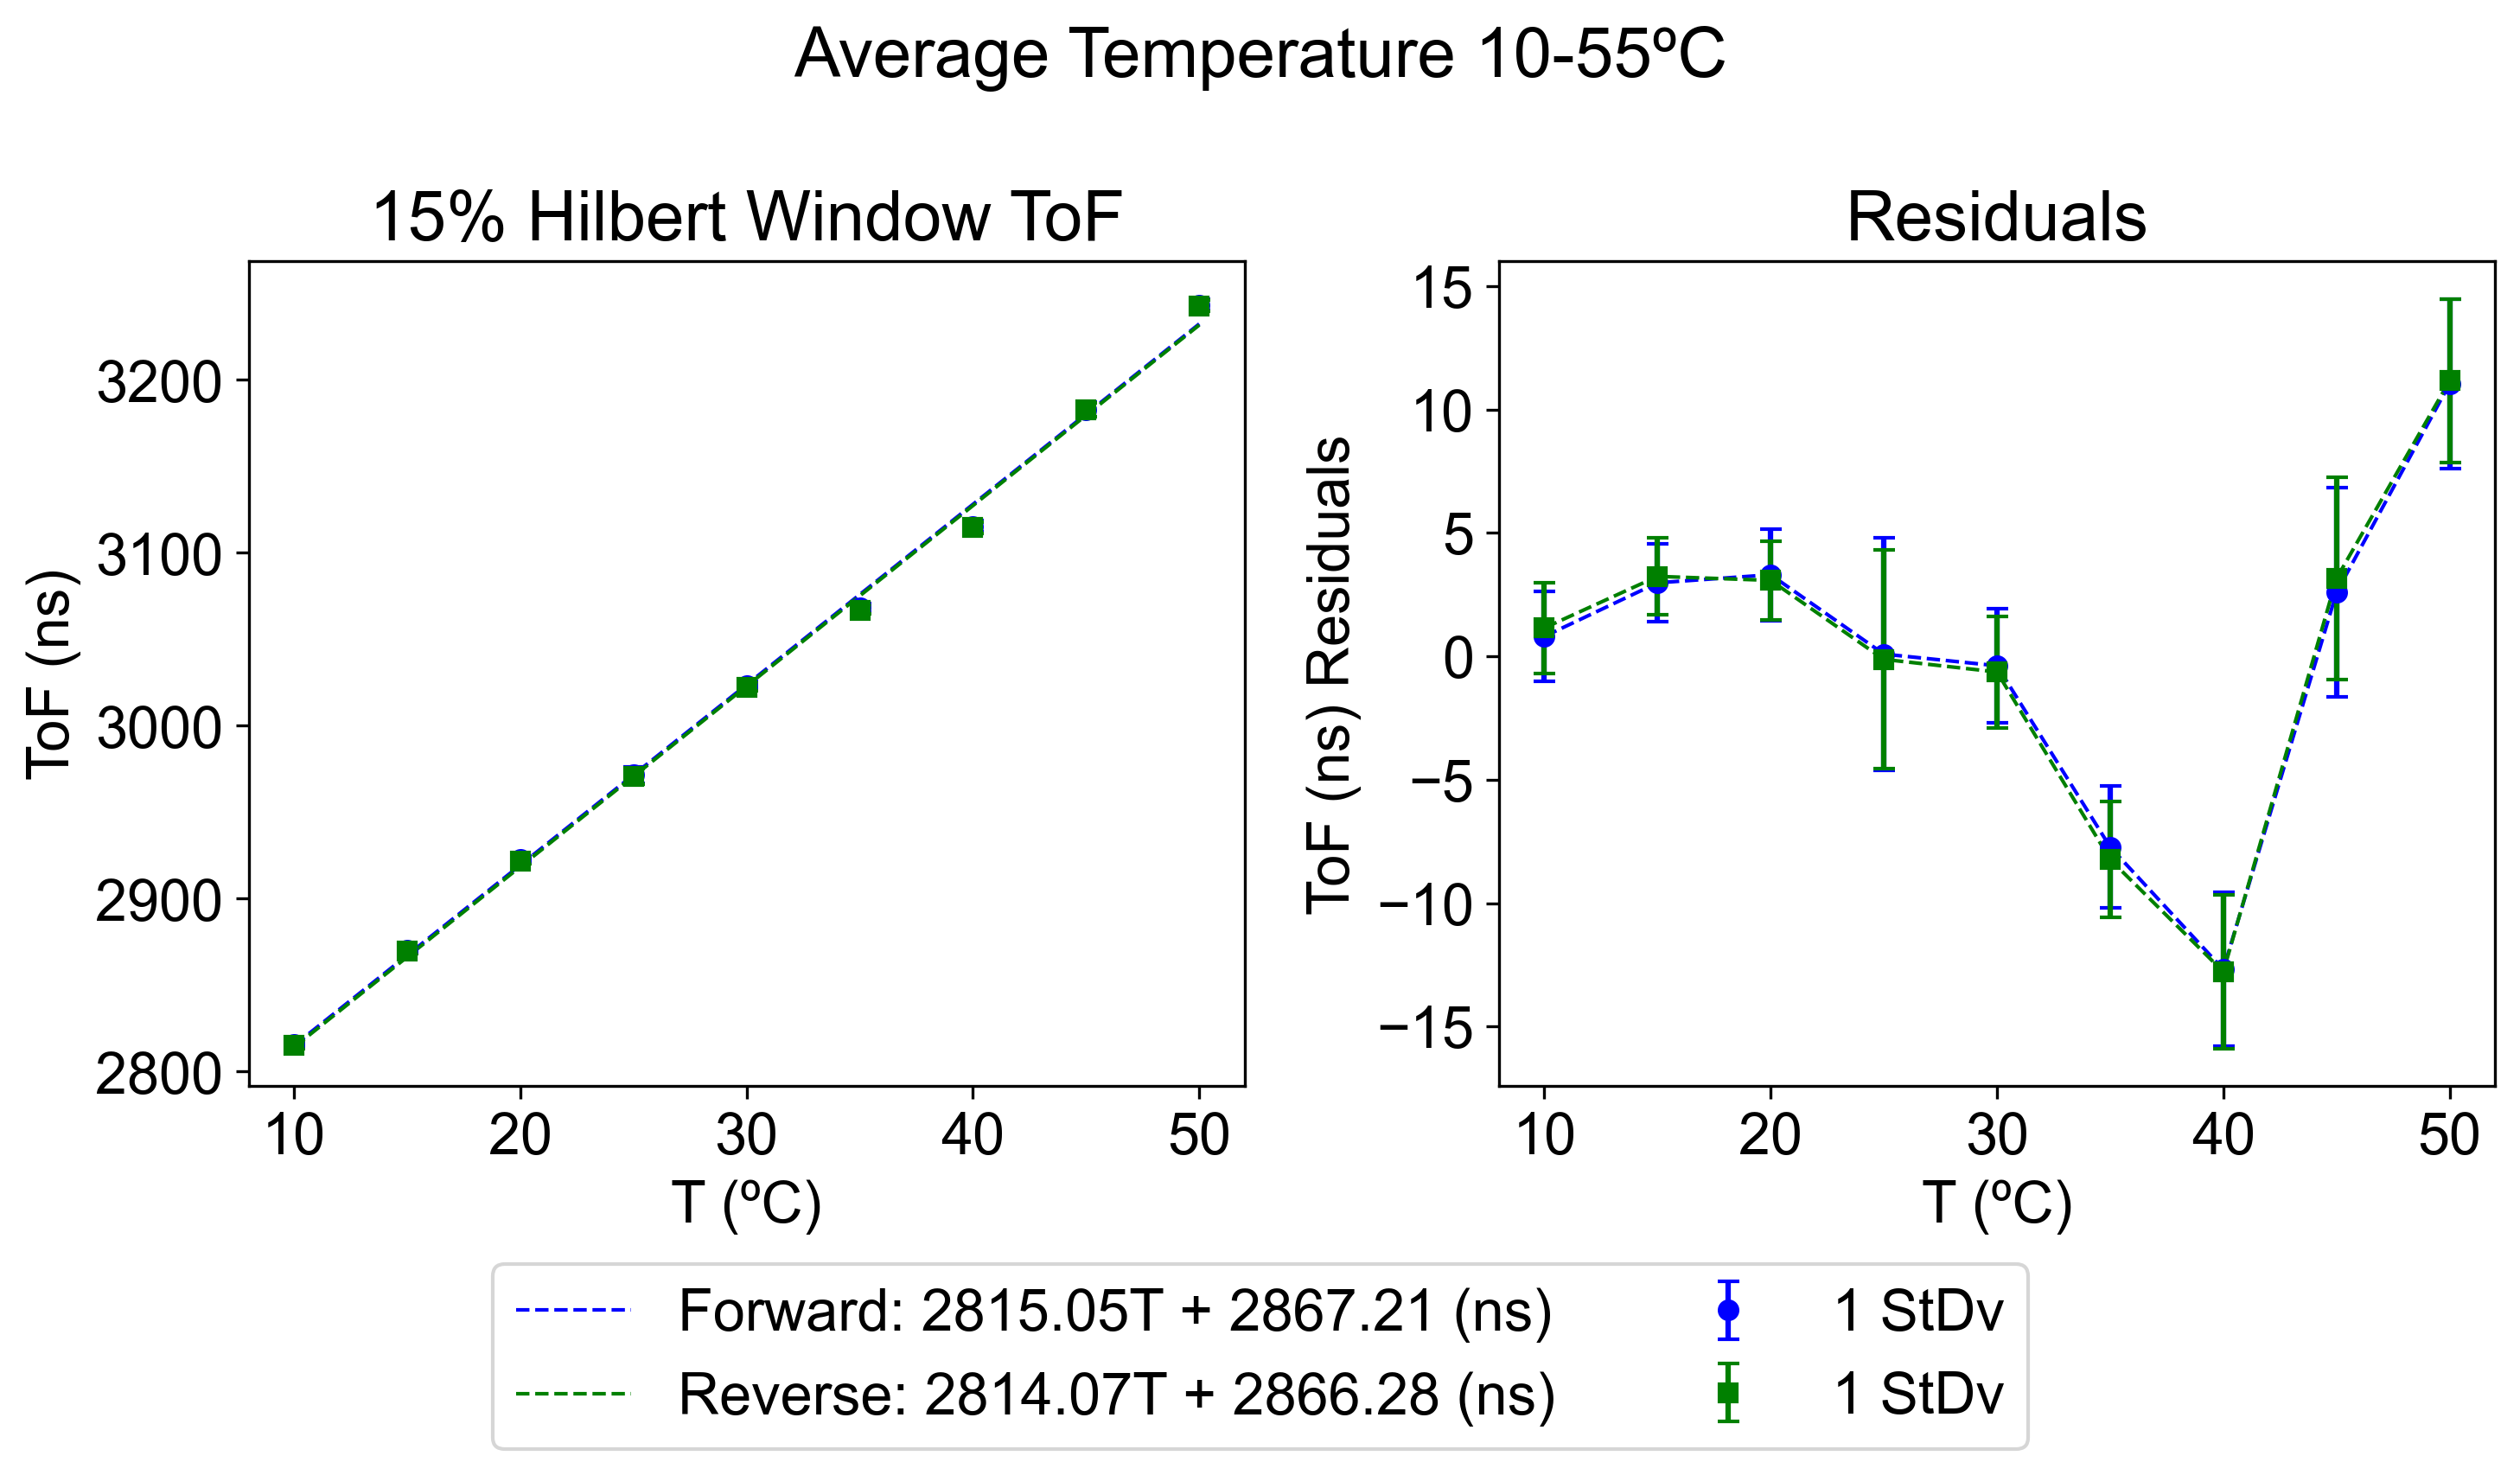

In [76]:
# plot hilbert window tof
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Average Temperature 10-55ºC')

ax[0].plot(temps, f_hilbert_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_hilbert_tof_fit[0]:.2f}T + {f_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(temps, f_hilbert_tof_arr, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(temps, r_hilbert_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_hilbert_tof_fit[0]:.2f}T + {r_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(temps, r_hilbert_tof_arr, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% Hilbert Window ToF')
ax[0].set_xlabel('T (ºC)')
ax[0].set_ylabel('ToF (ns)' )

ax[1].plot(temps, f_hilbert_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(temps, f_hilbert_tof_residuals, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(temps, r_hilbert_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(temps, r_hilbert_tof_residuals, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('T (ºC)')
ax[1].set_ylabel('ToF (ns) Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

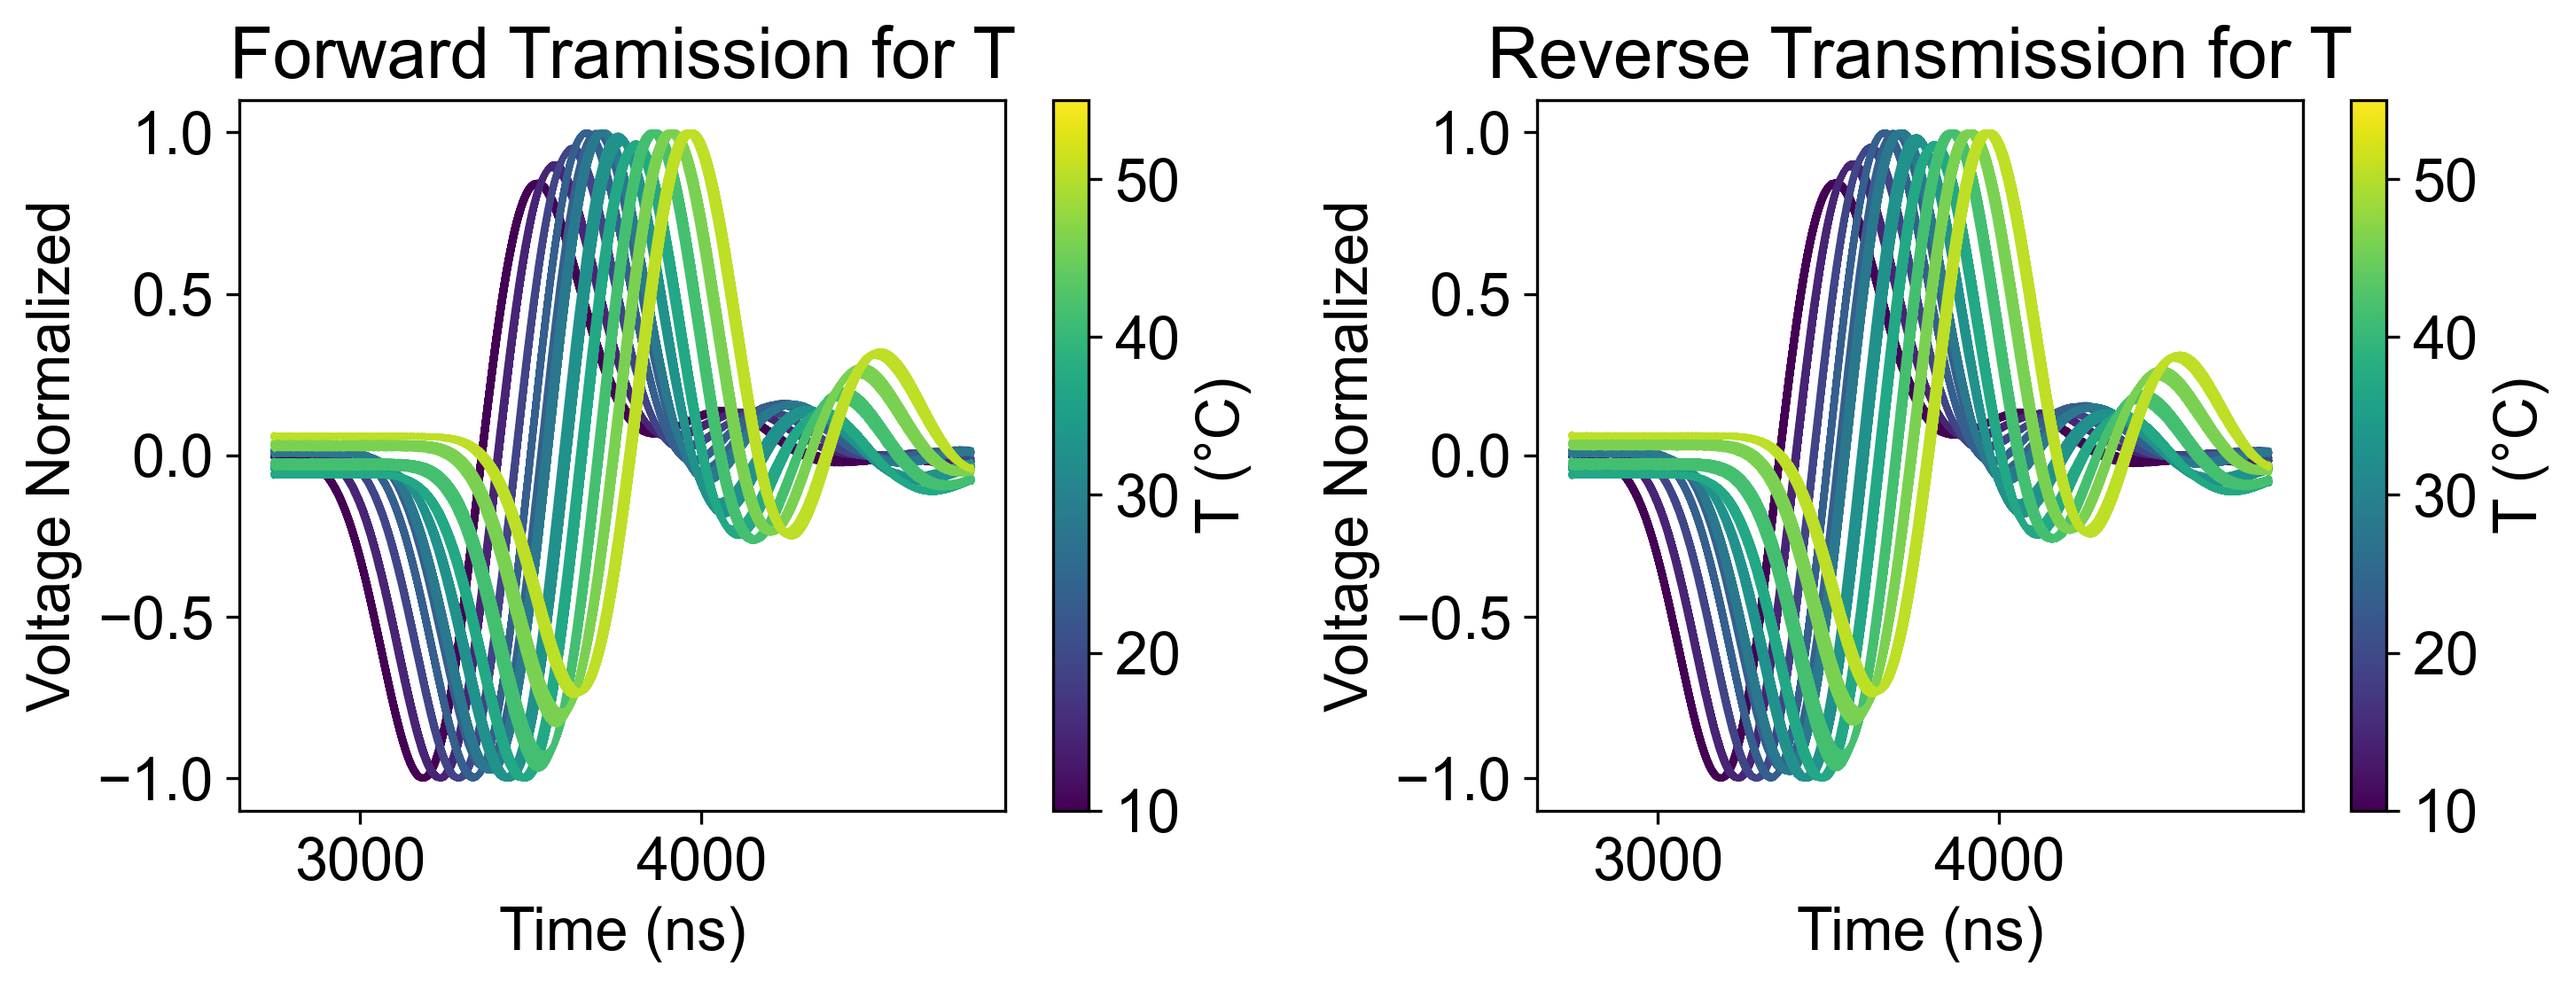

In [92]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
steps_ = 10
for i in range(steps_):
    mask = (merged_filtered_df['3000.1: CH1 Target'] == 10+i*5) & \
           (merged_filtered_df['3000.2: CH2 Target'] == 10+i*5) & \
           (merged_filtered_df.index < 996)
           
    for idx, row in merged_filtered_df.loc[mask].iterrows():
        ax[0].plot(
            row['time'][:1200],
            row['voltage_transmission_forward'][:1200],
            color=cm.viridis(i / steps_),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
        ax[1].plot(
            row['time'][:1200],
            row['voltage_transmission_reverse'][:1200],
            color=cm.viridis(i / steps_),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel('Voltage Normalized')
ax[0].set_title(f'Forward Tramission for T')
# ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel('Voltage Normalized')
ax[1].set_title(f'Reverse Transmission for T')
ax[1].set_xlabel('Time (ns)')

sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(vmin=10, vmax=55))
cbar = fig.colorbar(sm, ax=ax[0], label='T (°C)', pad=0.05)
cbar = fig.colorbar(sm, ax=ax[1], label='T (°C)', pad=0.05)

fig.tight_layout()

### dt

In [18]:
# calculate trends and detrended data for dT experiments
import matplotlib.pyplot as plt
d_temps = range(0, 14, 2)
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []
f_simple_tof_arr, f_simple_tof_err = [], []
r_simple_tof_arr, r_simple_tof_err = [], []
f_hilbert_tof_arr, f_hilbert_tof_err = [], []
r_hilbert_tof_arr, r_hilbert_tof_err = [], []

for i in range(7):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 30 + i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 30 - i)
        & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
        & (merged_filtered_df.index > 755)
    )
    filtered_df = merged_filtered_df[mask]
    if filtered_df.empty: 
        print(i)
        continue
    
    f_amp_arr.append(filtered_df[f'amplitude_forward_normalized'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward_normalized'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse_normalized'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse_normalized'].std())
    
    f_simple_tof_arr.append(filtered_df[f'Simple_ToF_forward (ns)'].mean())
    f_simple_tof_err.append(filtered_df[f'Simple_ToF_forward (ns)'].std())
    
    r_simple_tof_arr.append(filtered_df[f'Simple_ToF_reverse (ns)'].mean())
    r_simple_tof_err.append(filtered_df[f'Simple_ToF_reverse (ns)'].std())
    
    f_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_forward (ns)'].mean())
    f_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_forward (ns)'].std())
    
    r_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].mean())
    r_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].std())
    
f_amp_fit = np.polyfit(d_temps, f_amp_arr, 1)
f_amp_fit = f_amp_fit[0] * np.array(d_temps) + f_amp_fit[1]
r_amp_fit = np.polyfit(d_temps, r_amp_arr, 1)
r_amp_fit = r_amp_fit[0] * np.array(d_temps) + r_amp_fit[1]
f_amp_residuals = f_amp_arr - f_amp_fit
r_amp_residuals = r_amp_arr - r_amp_fit

f_simple_tof_fit = np.polyfit(d_temps, f_simple_tof_arr, 1)
f_simple_tof_fit = f_simple_tof_fit[0] * np.array(d_temps) + f_simple_tof_fit[1]
r_simple_tof_fit = np.polyfit(d_temps, r_simple_tof_arr, 1)
r_simple_tof_fit = r_simple_tof_fit[0] * np.array(d_temps) + r_simple_tof_fit[1]
f_simple_tof_residuals = f_simple_tof_arr - f_simple_tof_fit
r_simple_tof_residuals = r_simple_tof_arr - r_simple_tof_fit

f_hilbert_tof_fit = np.polyfit(d_temps, f_hilbert_tof_arr, 1)
f_hilbert_tof_fit = f_hilbert_tof_fit[0] * np.array(d_temps) + f_hilbert_tof_fit[1]
r_hilbert_tof_fit = np.polyfit(d_temps, r_hilbert_tof_arr, 1)
r_hilbert_tof_fit = r_hilbert_tof_fit[0] * np.array(d_temps) + r_hilbert_tof_fit[1]
f_hilbert_tof_residuals = f_hilbert_tof_arr - f_hilbert_tof_fit
r_hilbert_tof_residuals = r_hilbert_tof_arr - r_hilbert_tof_fit

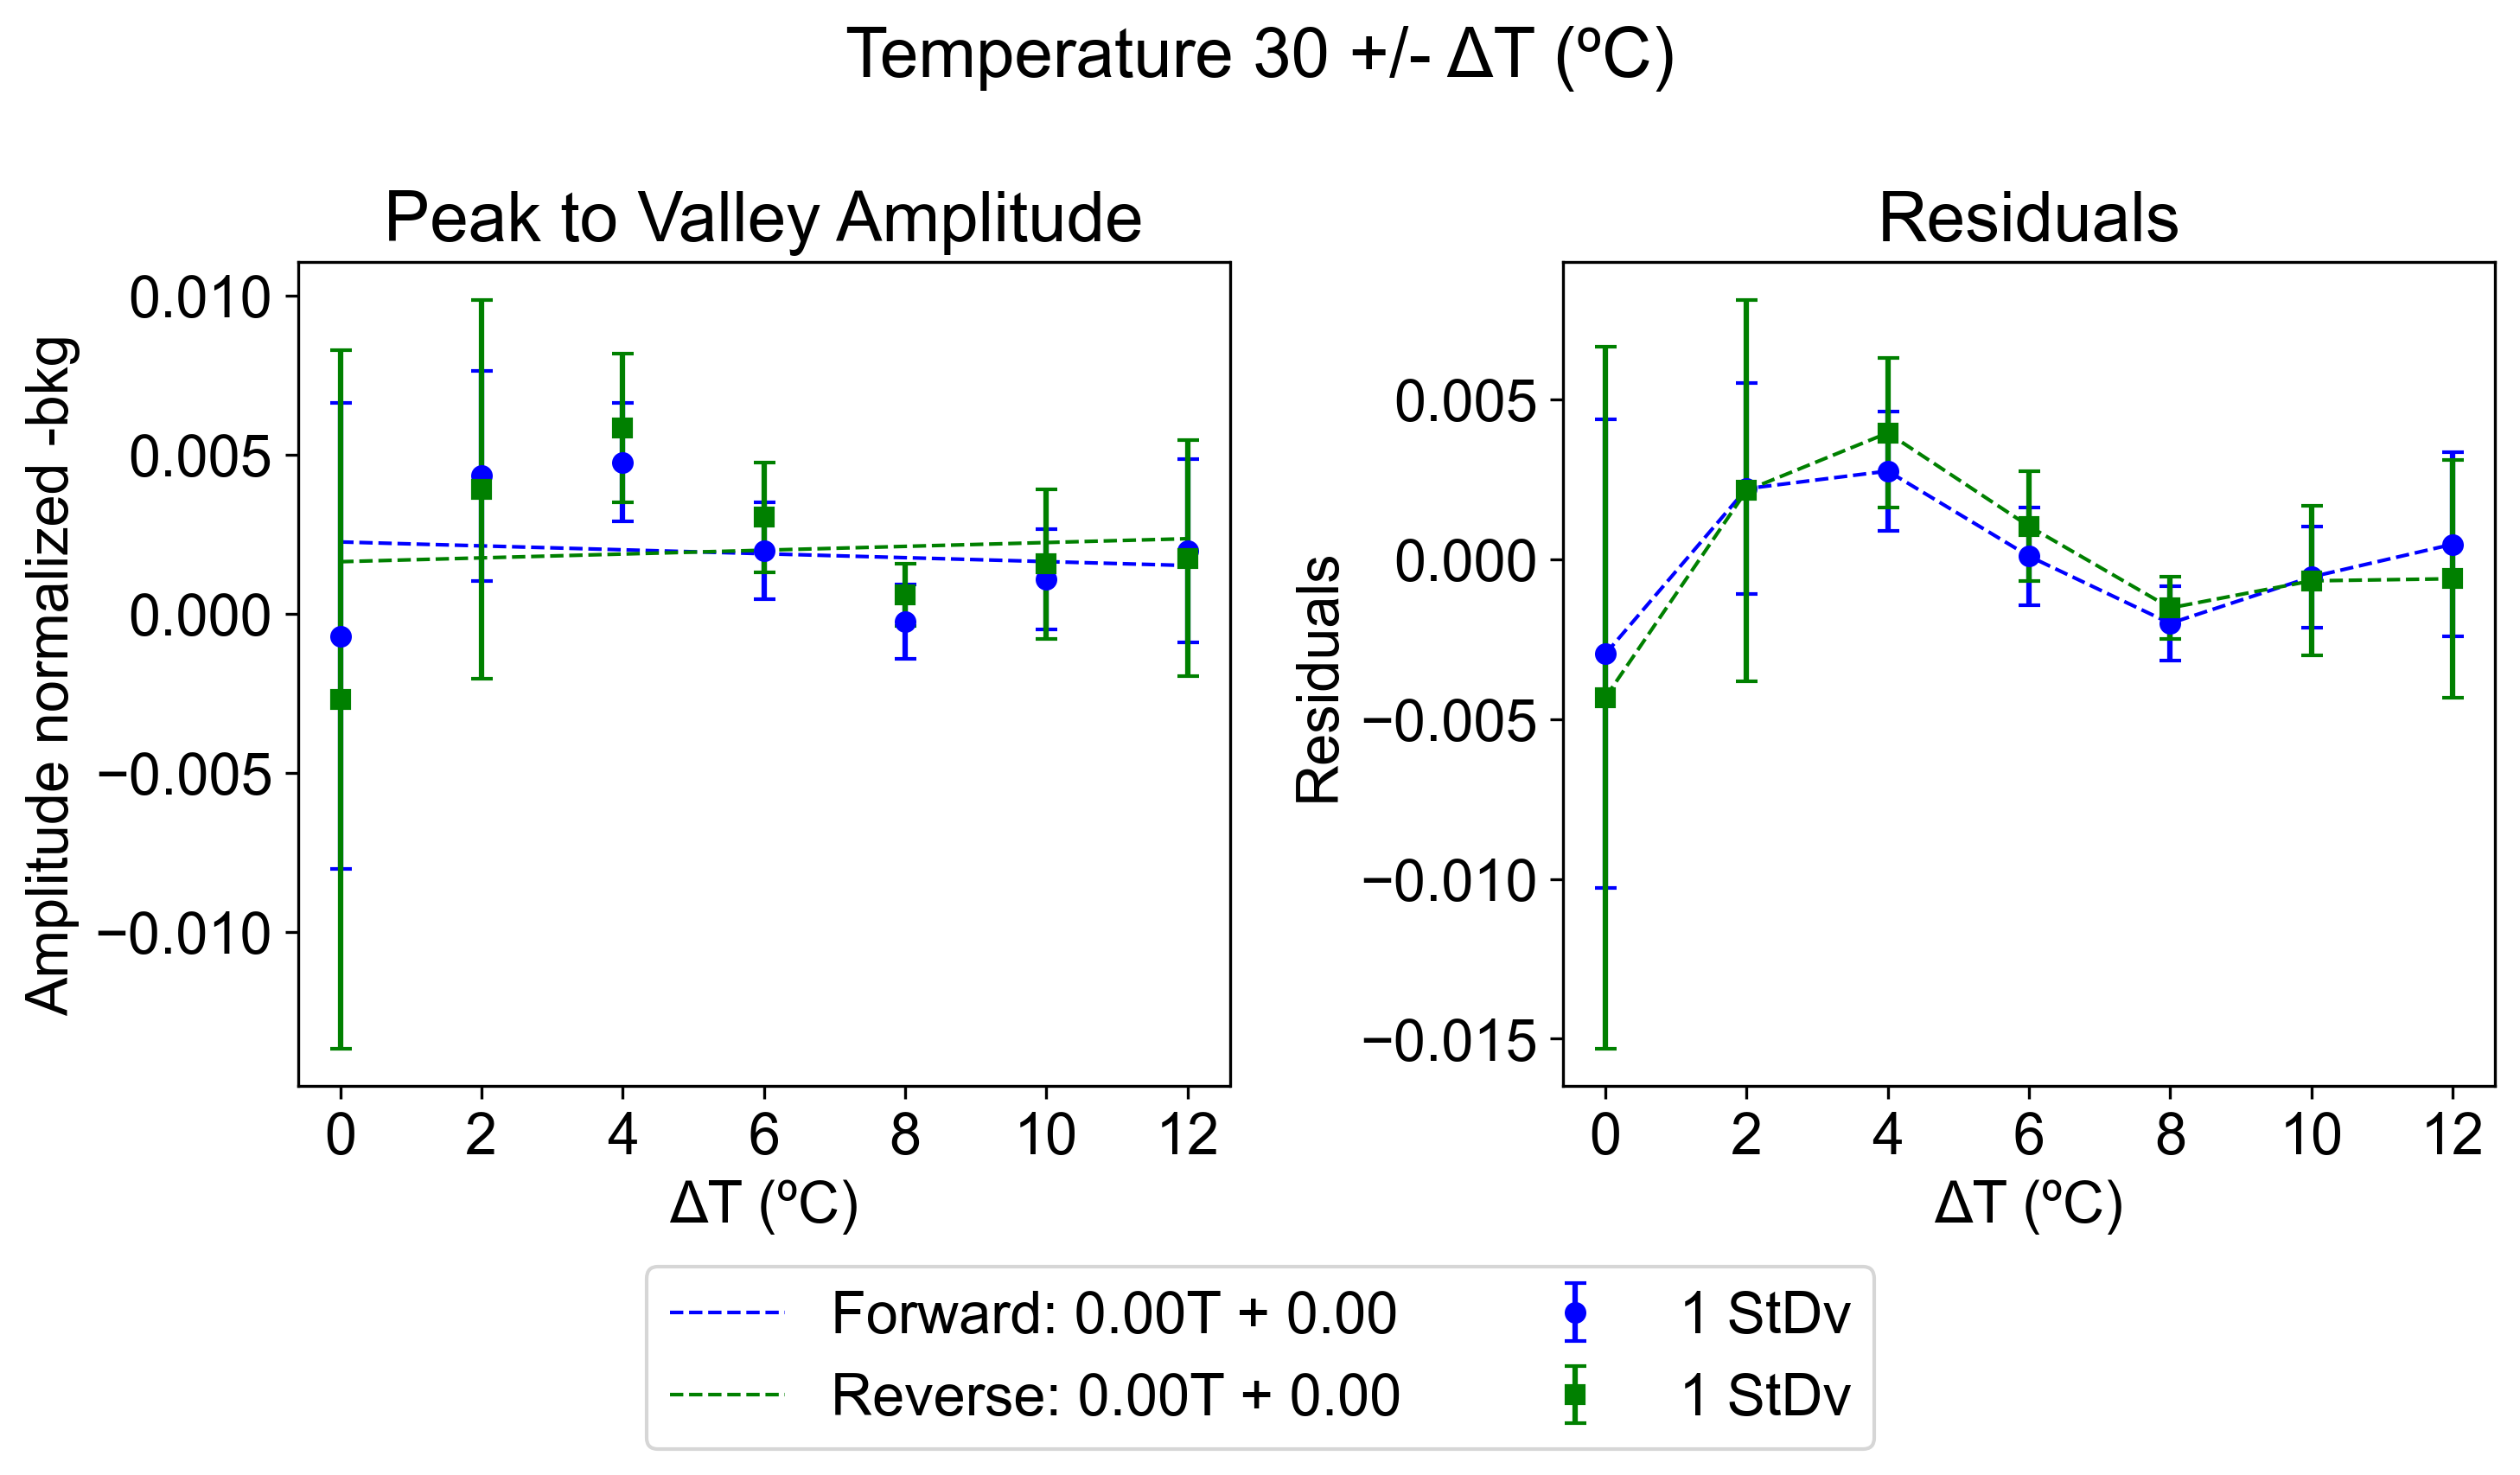

In [23]:
# plot amplitude
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_amp_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_amp_fit[0]:.2f}T + {f_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_amp_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_amp_fit[0]:.2f}T + {r_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('Peak to Valley Amplitude')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('Amplitude normalized -bkg')

ax[1].plot(d_temps, f_amp_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_amp_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_amp_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_amp_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

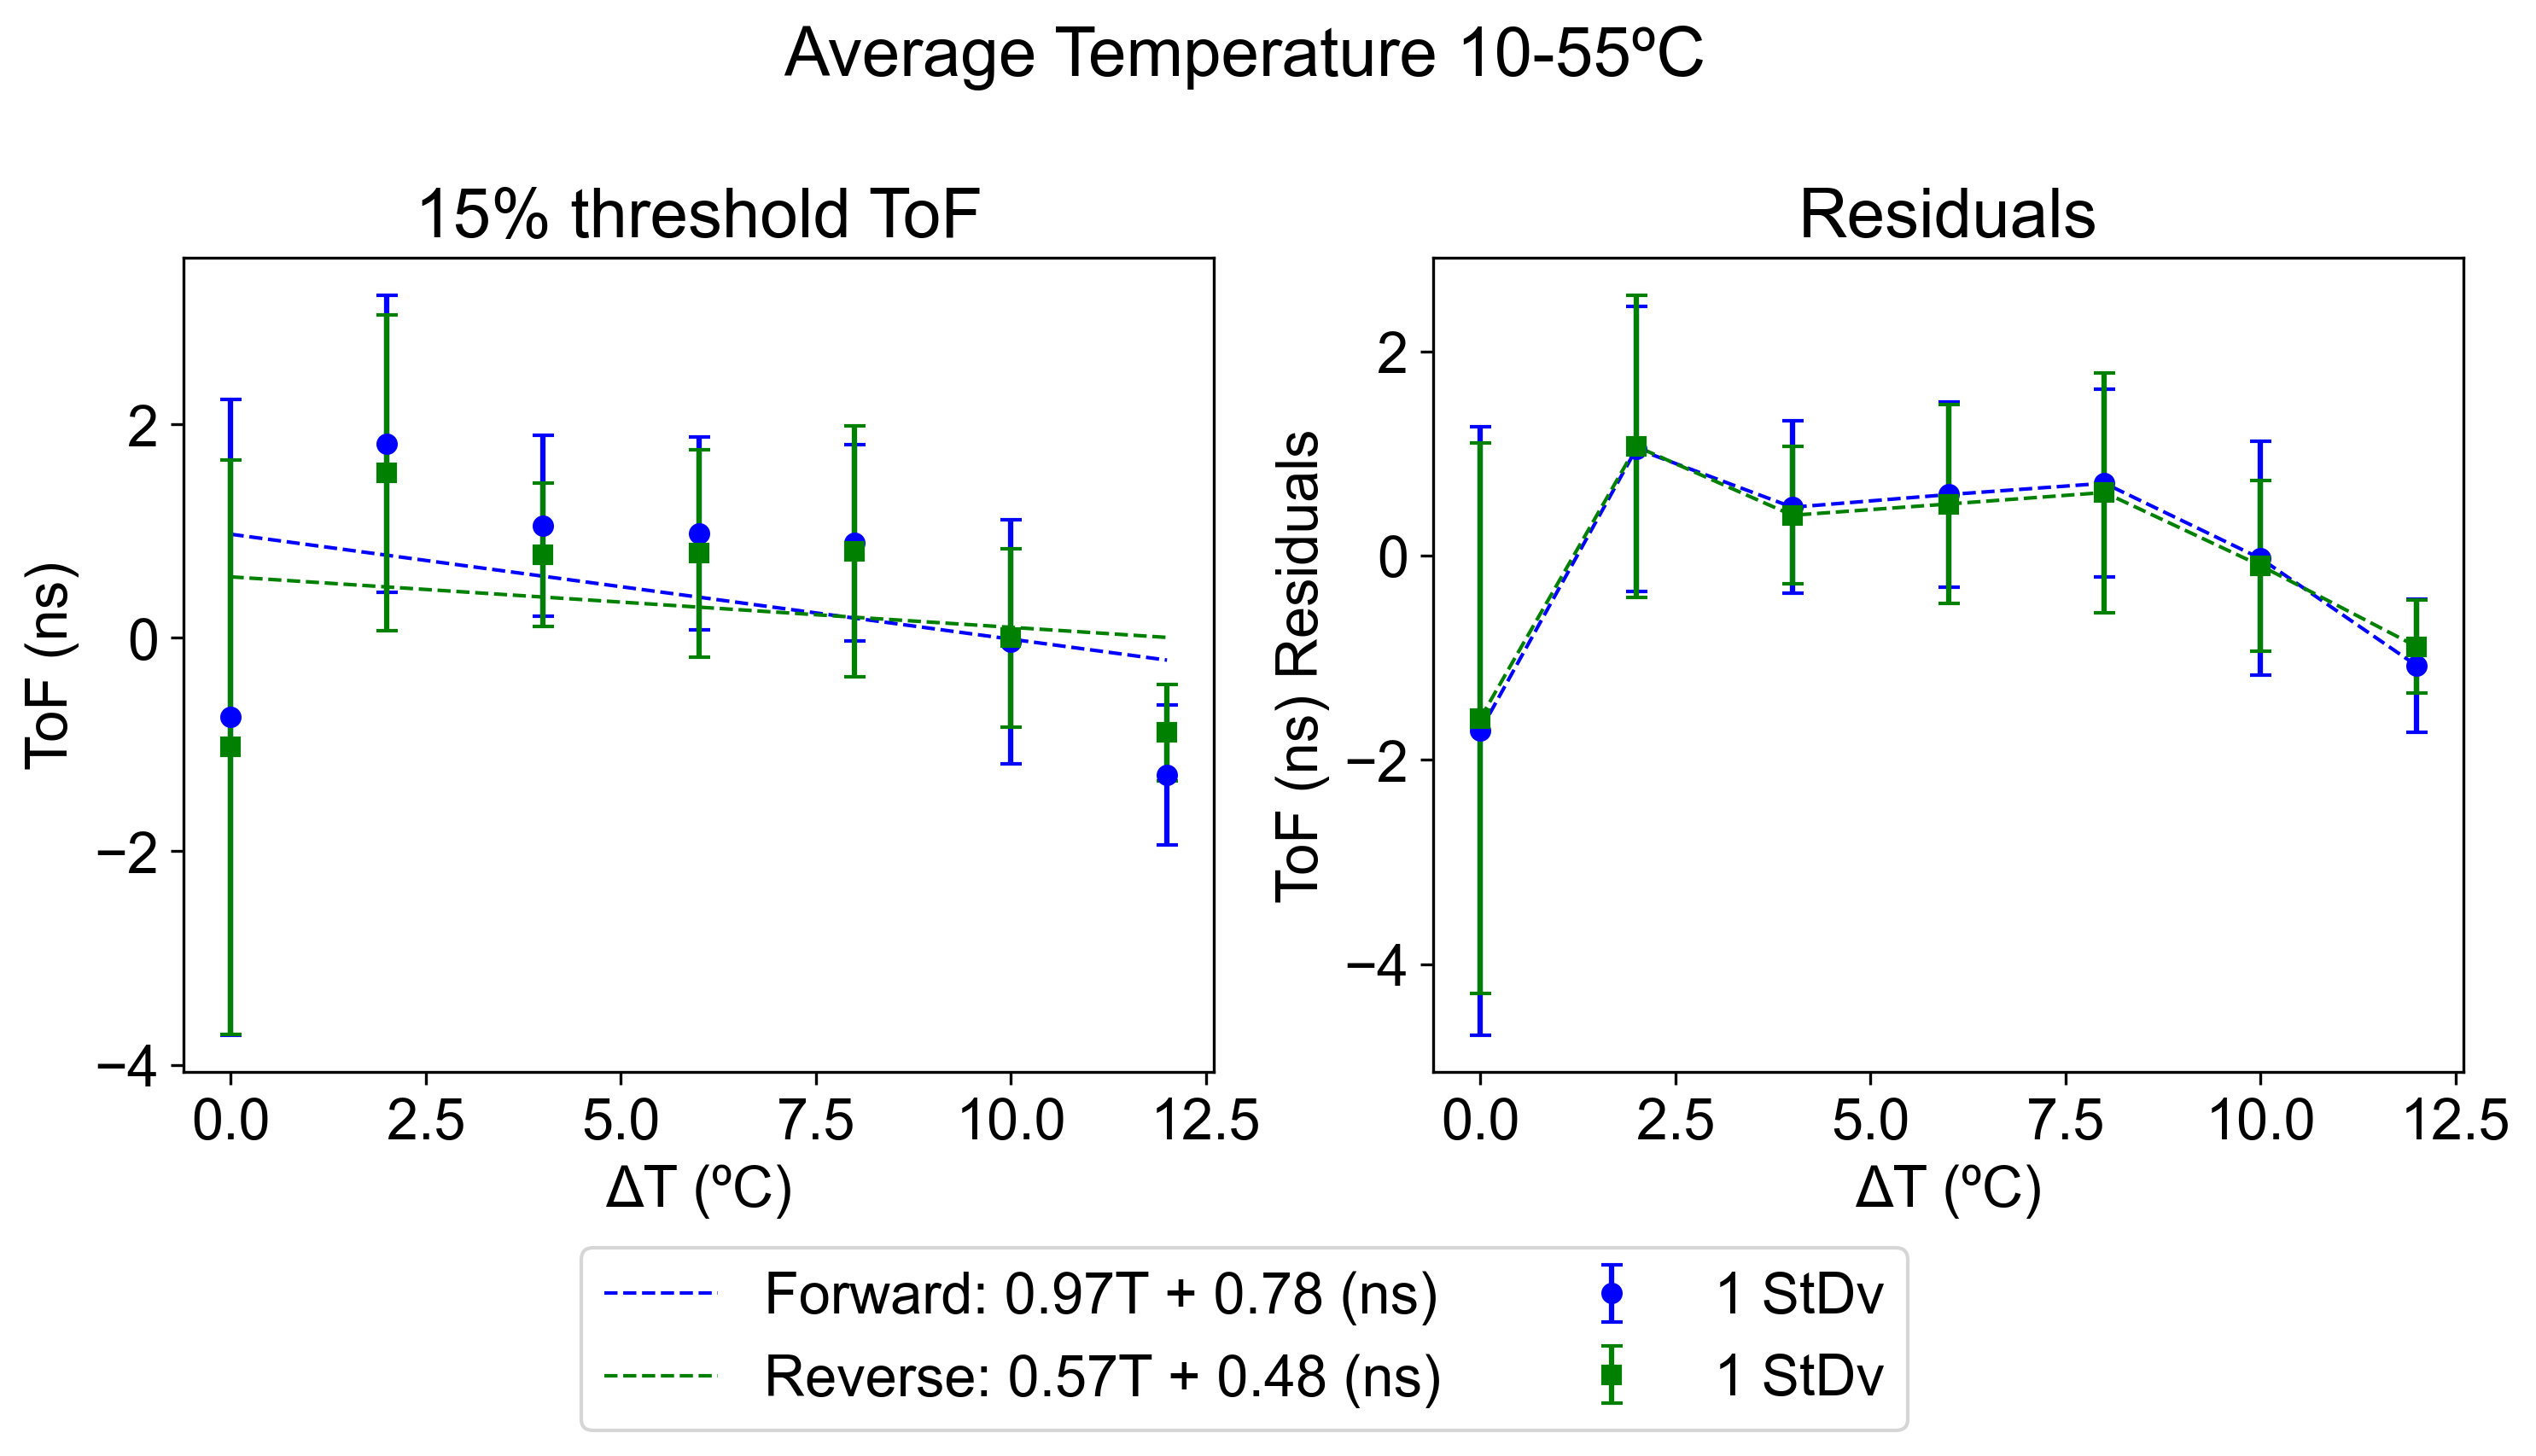

In [35]:
# plot simple tof
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Average Temperature 10-55ºC')

ax[0].plot(d_temps, f_simple_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_simple_tof_fit[0]:.2f}T + {f_simple_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, f_simple_tof_arr, yerr=f_simple_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_simple_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_simple_tof_fit[0]:.2f}T + {r_simple_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, r_simple_tof_arr, yerr=r_simple_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% threshold ToF')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_ylabel('ToF (ns)' )

ax[1].plot(d_temps, f_simple_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_simple_tof_residuals, yerr=f_simple_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_simple_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_simple_tof_residuals, yerr=r_simple_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_ylabel('ToF (ns) Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

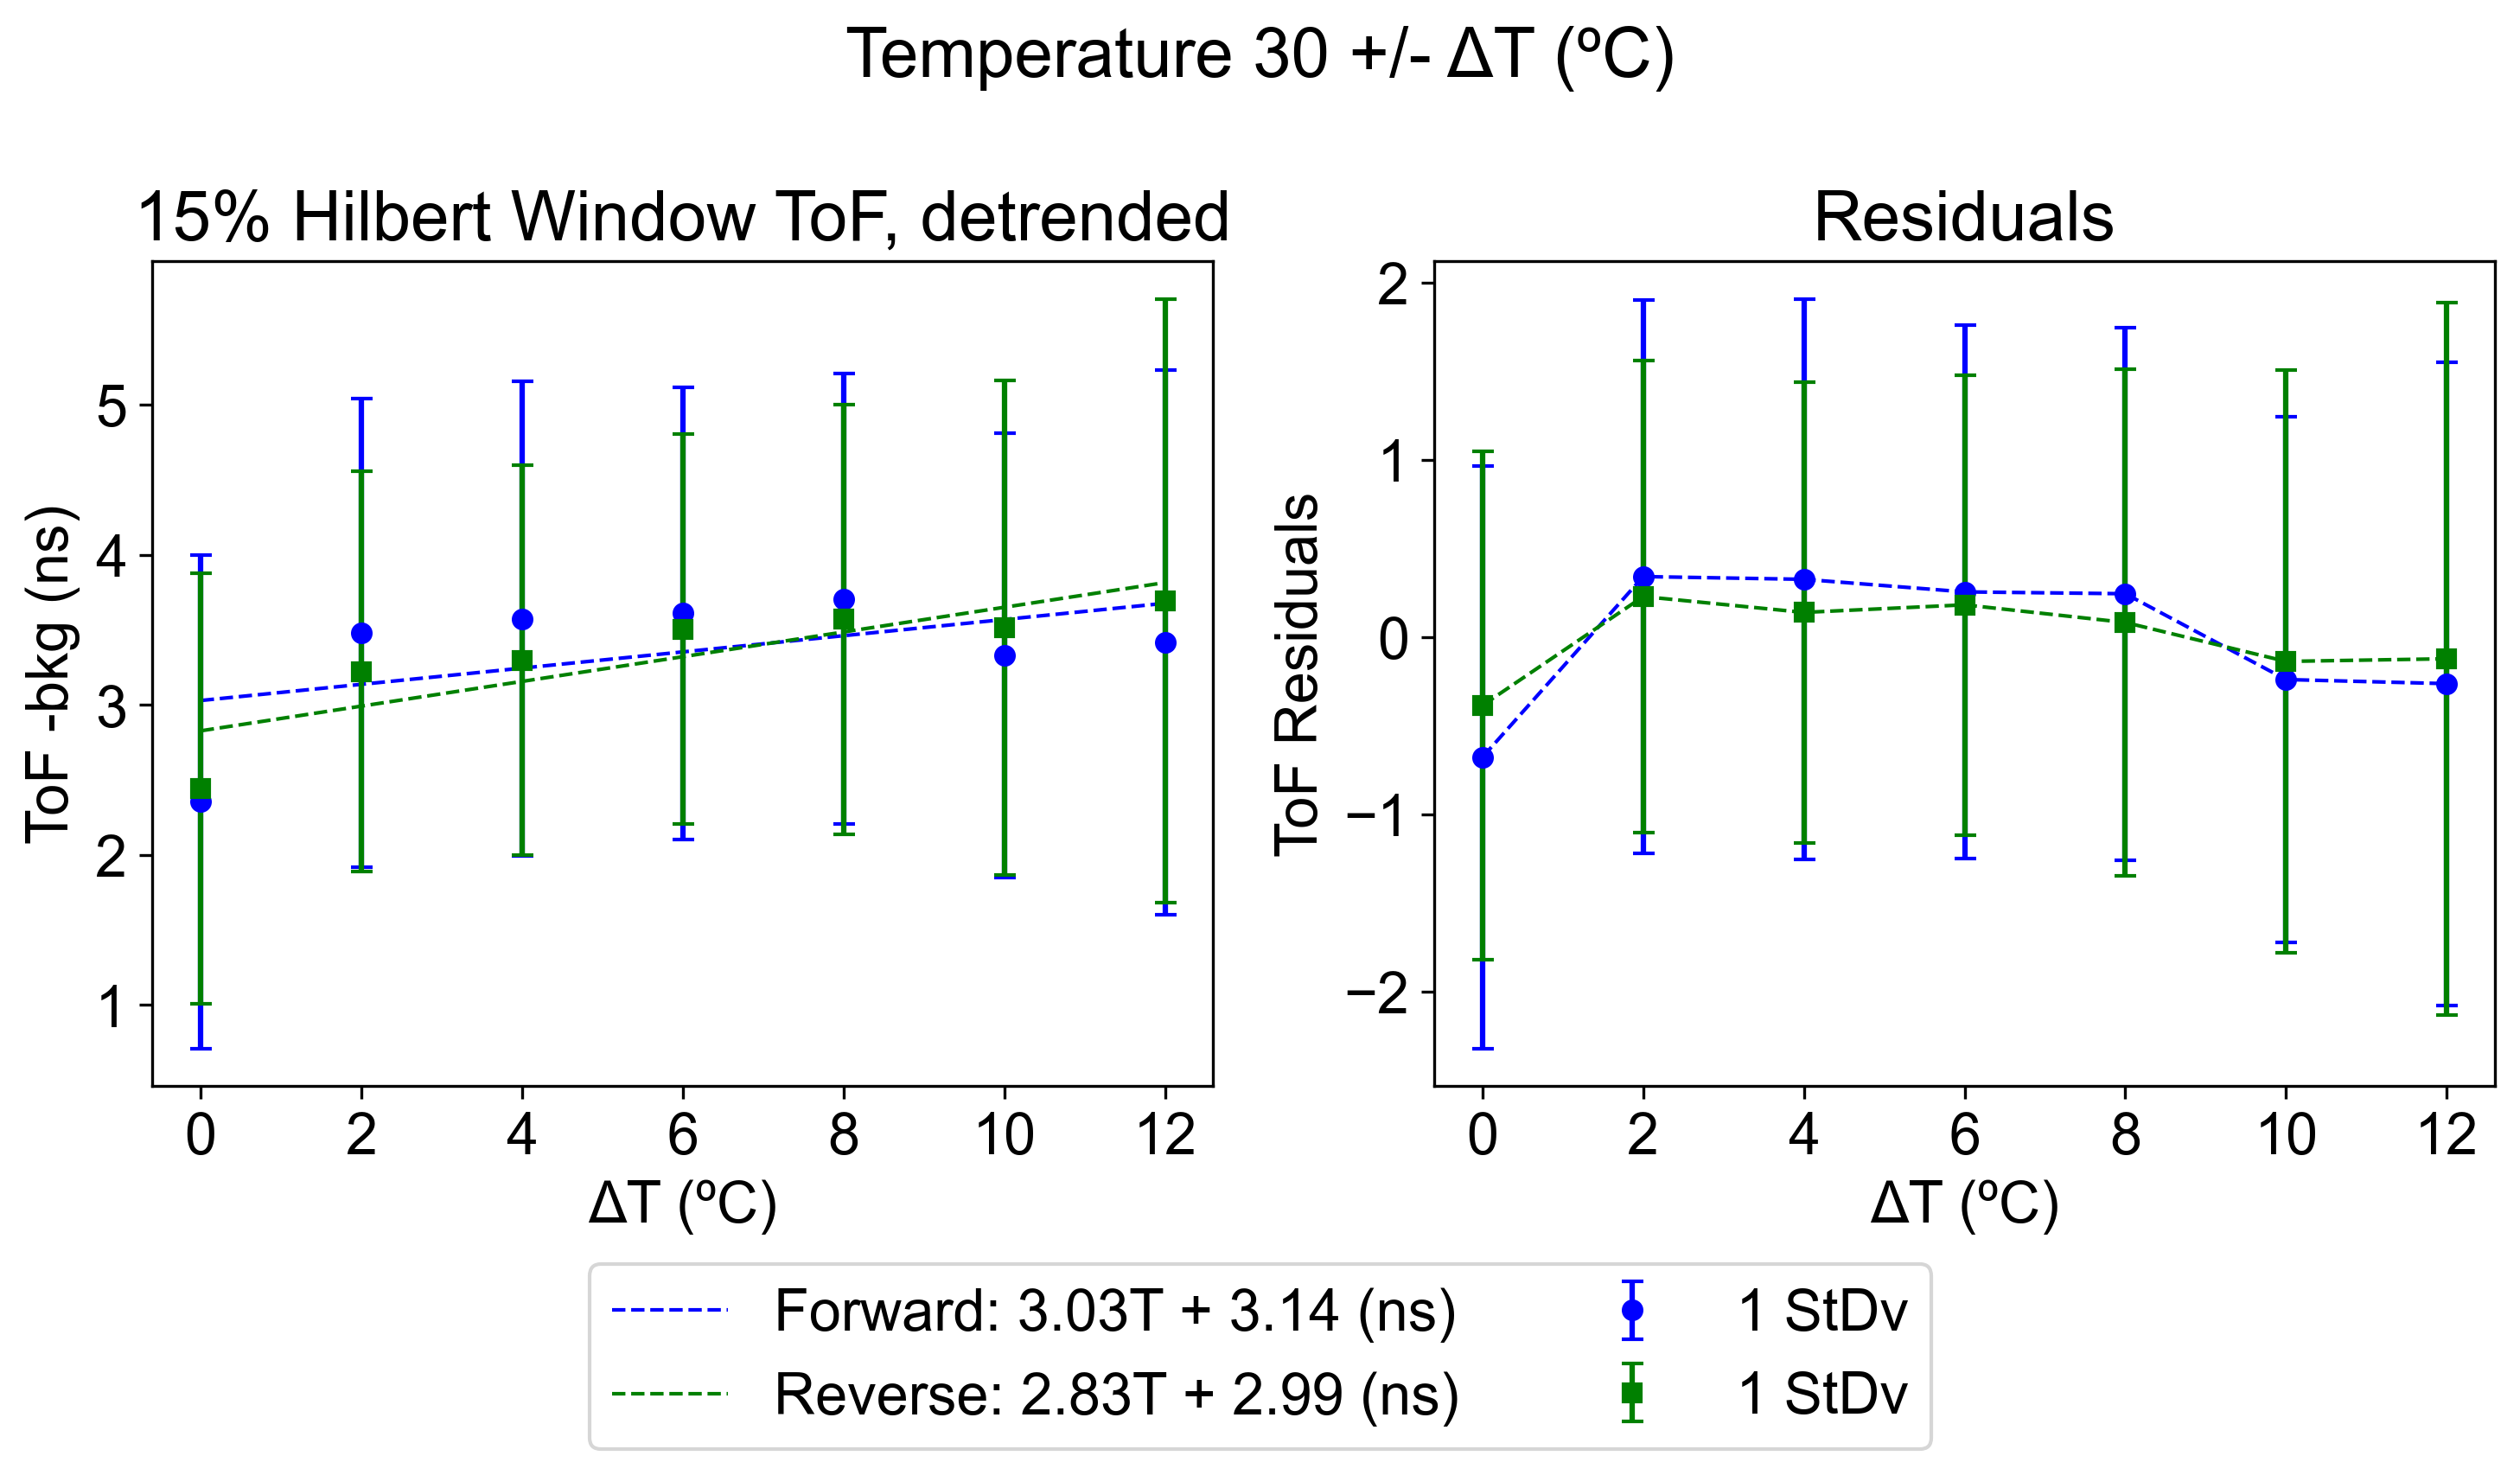

In [22]:
# plot hilbert window tof
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_hilbert_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_hilbert_tof_fit[0]:.2f}T + {f_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, f_hilbert_tof_arr, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_hilbert_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_hilbert_tof_fit[0]:.2f}T + {r_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, r_hilbert_tof_arr, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% Hilbert Window ToF, detrended')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('ToF -bkg (ns)' )

ax[1].plot(d_temps, f_hilbert_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_hilbert_tof_residuals, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_hilbert_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_hilbert_tof_residuals, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('ToF Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)
fig.tight_layout()

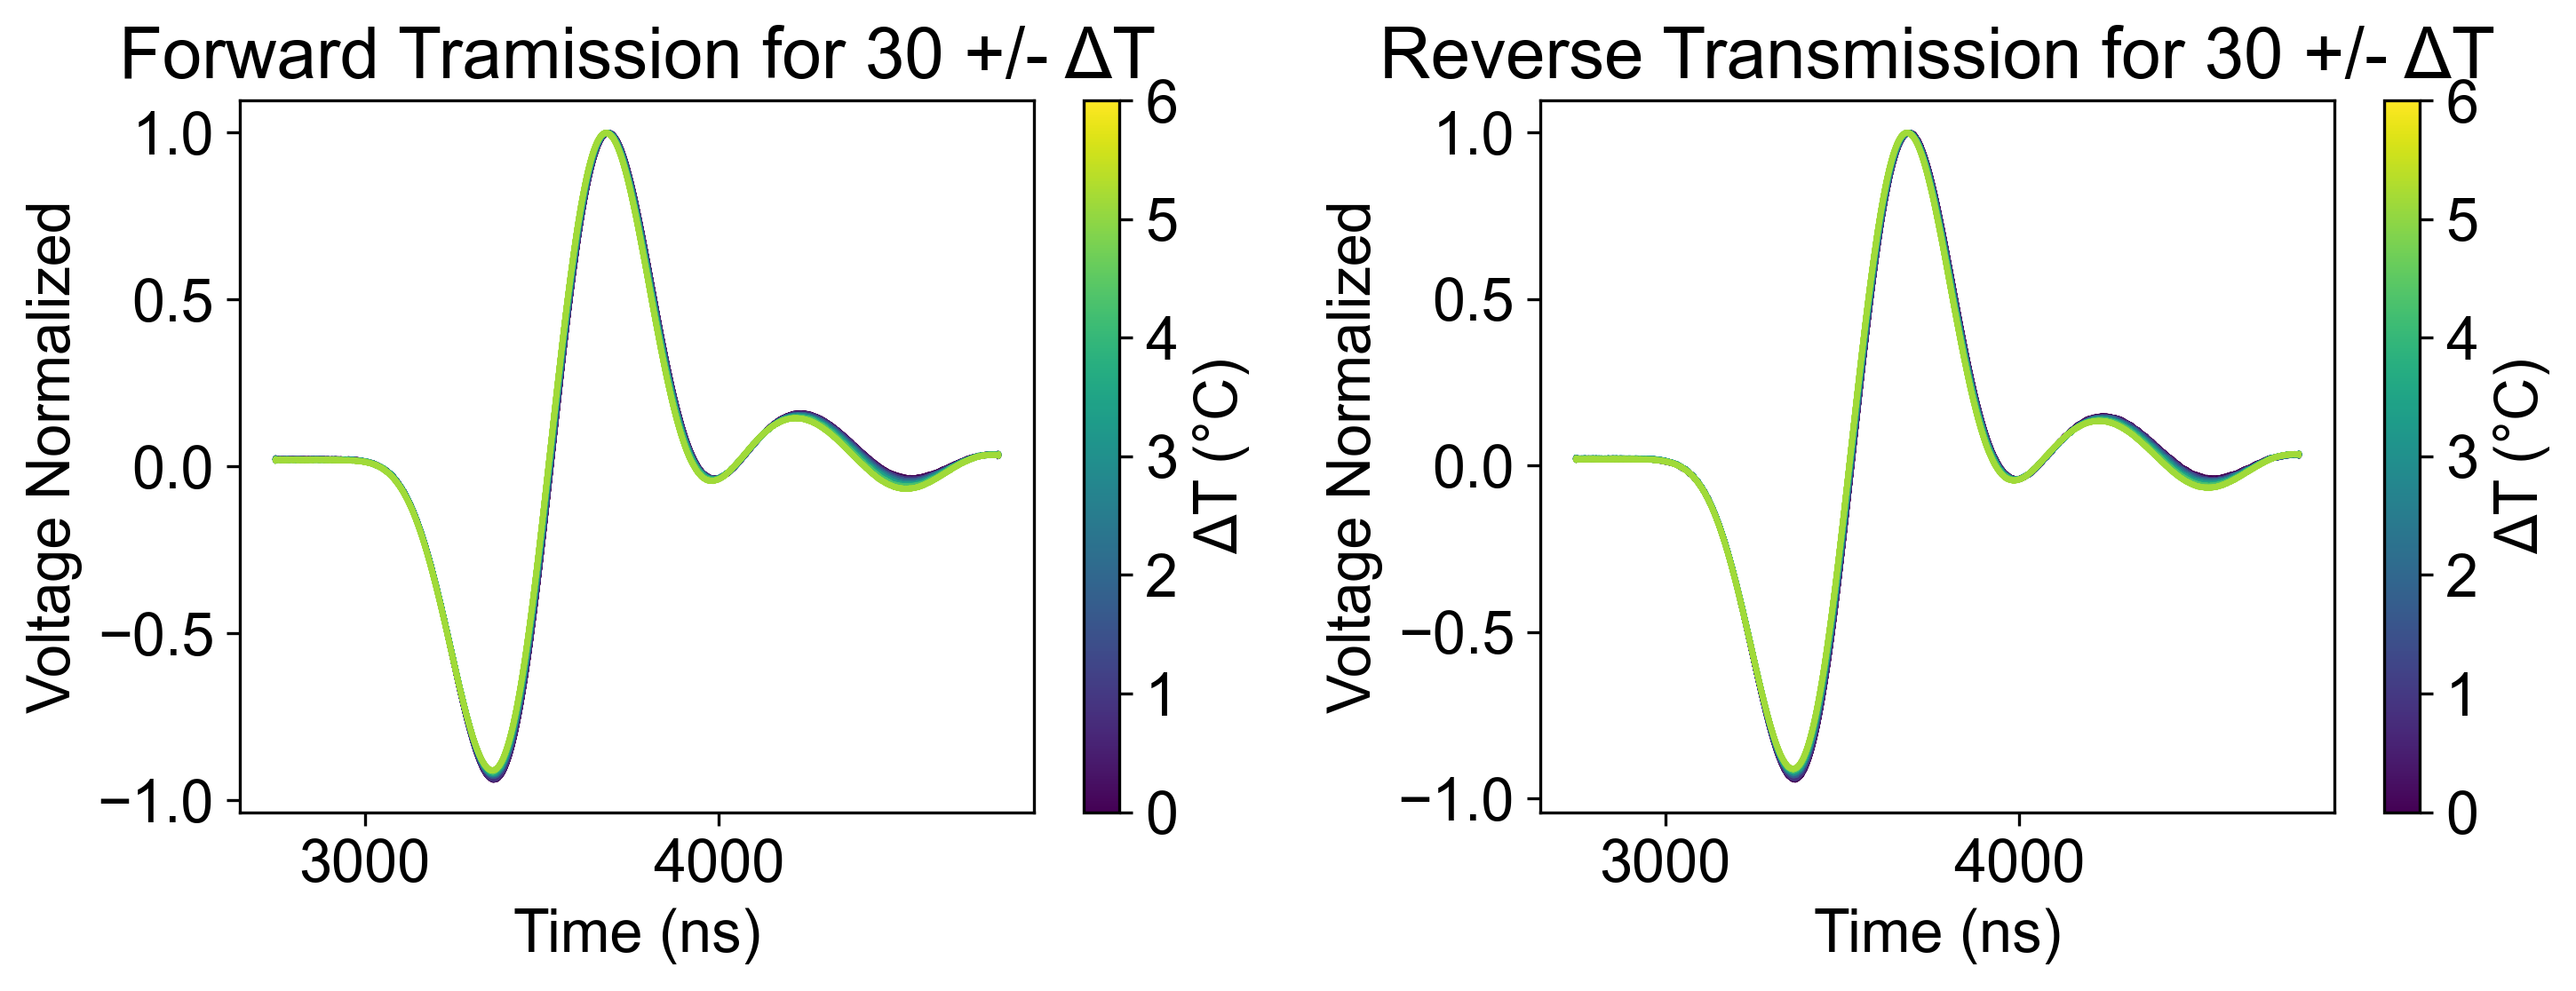

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i in range(7):
    mask = (merged_filtered_df['3000.1: CH1 Target'] == 30+i) & \
           (merged_filtered_df['3000.2: CH2 Target'] == 30-i) & \
           (merged_filtered_df.index > 750)
           
    for idx, row in merged_filtered_df.loc[mask].iloc[-10:].iterrows():
        ax[0].plot(
            row['time'][:1200],
            row['voltage_transmission_forward'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
        ax[1].plot(
            row['time'][:1200],
            row['voltage_transmission_reverse'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel('Voltage Normalized')
ax[0].set_title(f'Forward Tramission for 30 +/- ΔT')
# ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel('Voltage Normalized')
ax[1].set_title(f'Reverse Transmission for 30 +/- ΔT')
ax[1].set_xlabel('Time (ns)')

sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(vmin=0, vmax=6))
cbar = fig.colorbar(sm, ax=ax[0], label='ΔT (°C)', pad=0.05)
cbar = fig.colorbar(sm, ax=ax[1], label='ΔT (°C)', pad=0.05)

fig.tight_layout()

### dt individual experiment results

#### gradient 1

In [ ]:
df = merged_filtered_df.iloc[755:1500]

def run_plotter(i=0, keys_=()): plot_temps(i=i, keys_=list(keys_), idx_lable_type='dT')

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

selected_keys = [col for col in df.columns if col.startswith(('Simple_ToF', 'Hilbert_ToF', 'amplitude'))]
selected_keys.sort()
keys = widgets.SelectMultiple(
    options=selected_keys,
    value=tuple([]),
    description='Variable:',
    disabled=False,
)

interact(lambda i, key_: run_plotter(i=i, keys_=list(key_)), i=slider, key_=keys)

interactive(children=(IntSlider(value=0, continuous_update=False, description='measurement:', max=744), Select…

<function __main__.<lambda>(i, key_)>

In [ ]:
# calculate trends and detrended data for dT experiments
import matplotlib.pyplot as plt
d_temps = range(0, 14, 2)
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []
f_simple_tof_arr, f_simple_tof_err = [], []
r_simple_tof_arr, r_simple_tof_err = [], []
f_hilbert_tof_arr, f_hilbert_tof_err = [], []
r_hilbert_tof_arr, r_hilbert_tof_err = [], []

for i in range(7):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 30 + i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 30 - i)
        & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
        & (merged_filtered_df.index > 755)
    )
    filtered_df = merged_filtered_df[mask]
    if filtered_df.empty: 
        print(i)
        continue
    
    f_amp_arr.append(filtered_df[f'amplitude_forward_normalized'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward_normalized'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse_normalized'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse_normalized'].std())
    
    f_simple_tof_arr.append(filtered_df[f'Simple_ToF_forward (ns)'].mean())
    f_simple_tof_err.append(filtered_df[f'Simple_ToF_forward (ns)'].std())
    
    r_simple_tof_arr.append(filtered_df[f'Simple_ToF_reverse (ns)'].mean())
    r_simple_tof_err.append(filtered_df[f'Simple_ToF_reverse (ns)'].std())
    
    f_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_forward (ns)'].mean())
    f_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_forward (ns)'].std())
    
    r_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].mean())
    r_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].std())
    
f_amp_fit = np.polyfit(d_temps, f_amp_arr, 1)
f_amp_fit = f_amp_fit[0] * np.array(d_temps) + f_amp_fit[1]
r_amp_fit = np.polyfit(d_temps, r_amp_arr, 1)
r_amp_fit = r_amp_fit[0] * np.array(d_temps) + r_amp_fit[1]
f_amp_residuals = f_amp_arr - f_amp_fit
r_amp_residuals = r_amp_arr - r_amp_fit

f_simple_tof_fit = np.polyfit(d_temps, f_simple_tof_arr, 1)
f_simple_tof_fit = f_simple_tof_fit[0] * np.array(d_temps) + f_simple_tof_fit[1]
r_simple_tof_fit = np.polyfit(d_temps, r_simple_tof_arr, 1)
r_simple_tof_fit = r_simple_tof_fit[0] * np.array(d_temps) + r_simple_tof_fit[1]
f_simple_tof_residuals = f_simple_tof_arr - f_simple_tof_fit
r_simple_tof_residuals = r_simple_tof_arr - r_simple_tof_fit

f_hilbert_tof_fit = np.polyfit(d_temps, f_hilbert_tof_arr, 1)
f_hilbert_tof_fit = f_hilbert_tof_fit[0] * np.array(d_temps) + f_hilbert_tof_fit[1]
r_hilbert_tof_fit = np.polyfit(d_temps, r_hilbert_tof_arr, 1)
r_hilbert_tof_fit = r_hilbert_tof_fit[0] * np.array(d_temps) + r_hilbert_tof_fit[1]
f_hilbert_tof_residuals = f_hilbert_tof_arr - f_hilbert_tof_fit
r_hilbert_tof_residuals = r_hilbert_tof_arr - r_hilbert_tof_fit

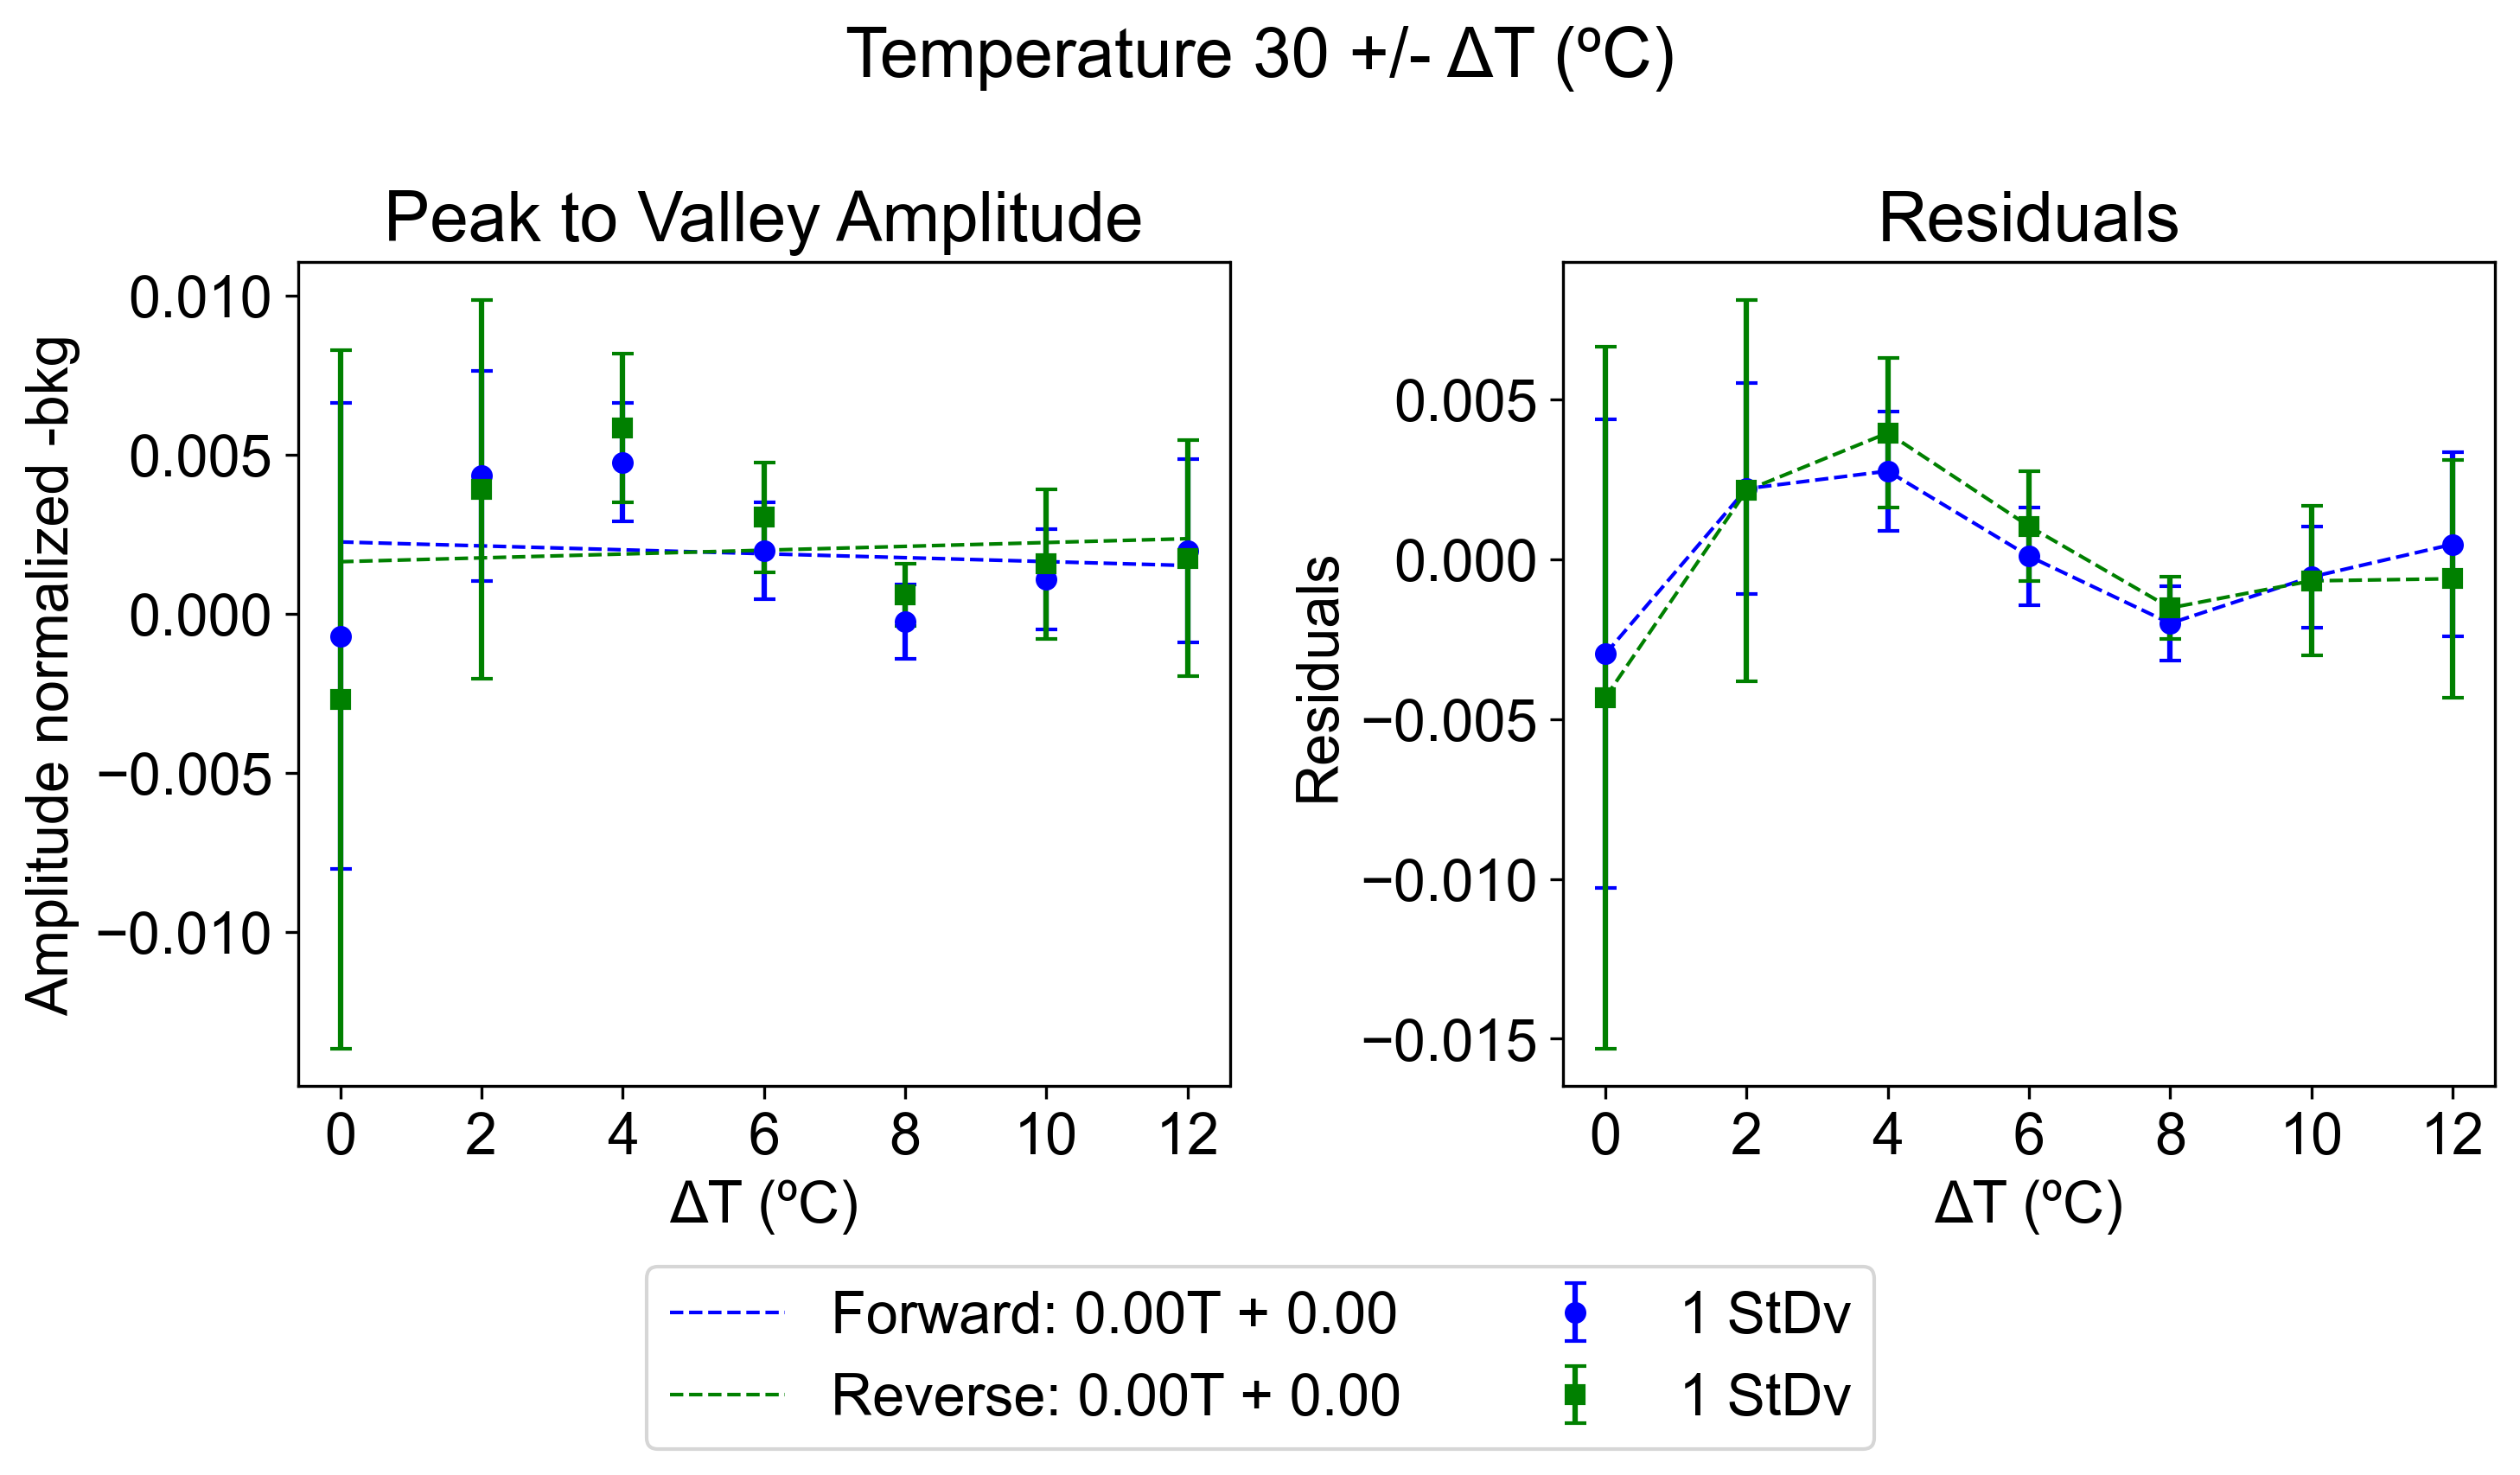

In [ ]:
# plot amplitude
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_amp_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_amp_fit[0]:.2f}T + {f_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_amp_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_amp_fit[0]:.2f}T + {r_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('Peak to Valley Amplitude')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('Amplitude normalized -bkg')

ax[1].plot(d_temps, f_amp_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_amp_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_amp_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_amp_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

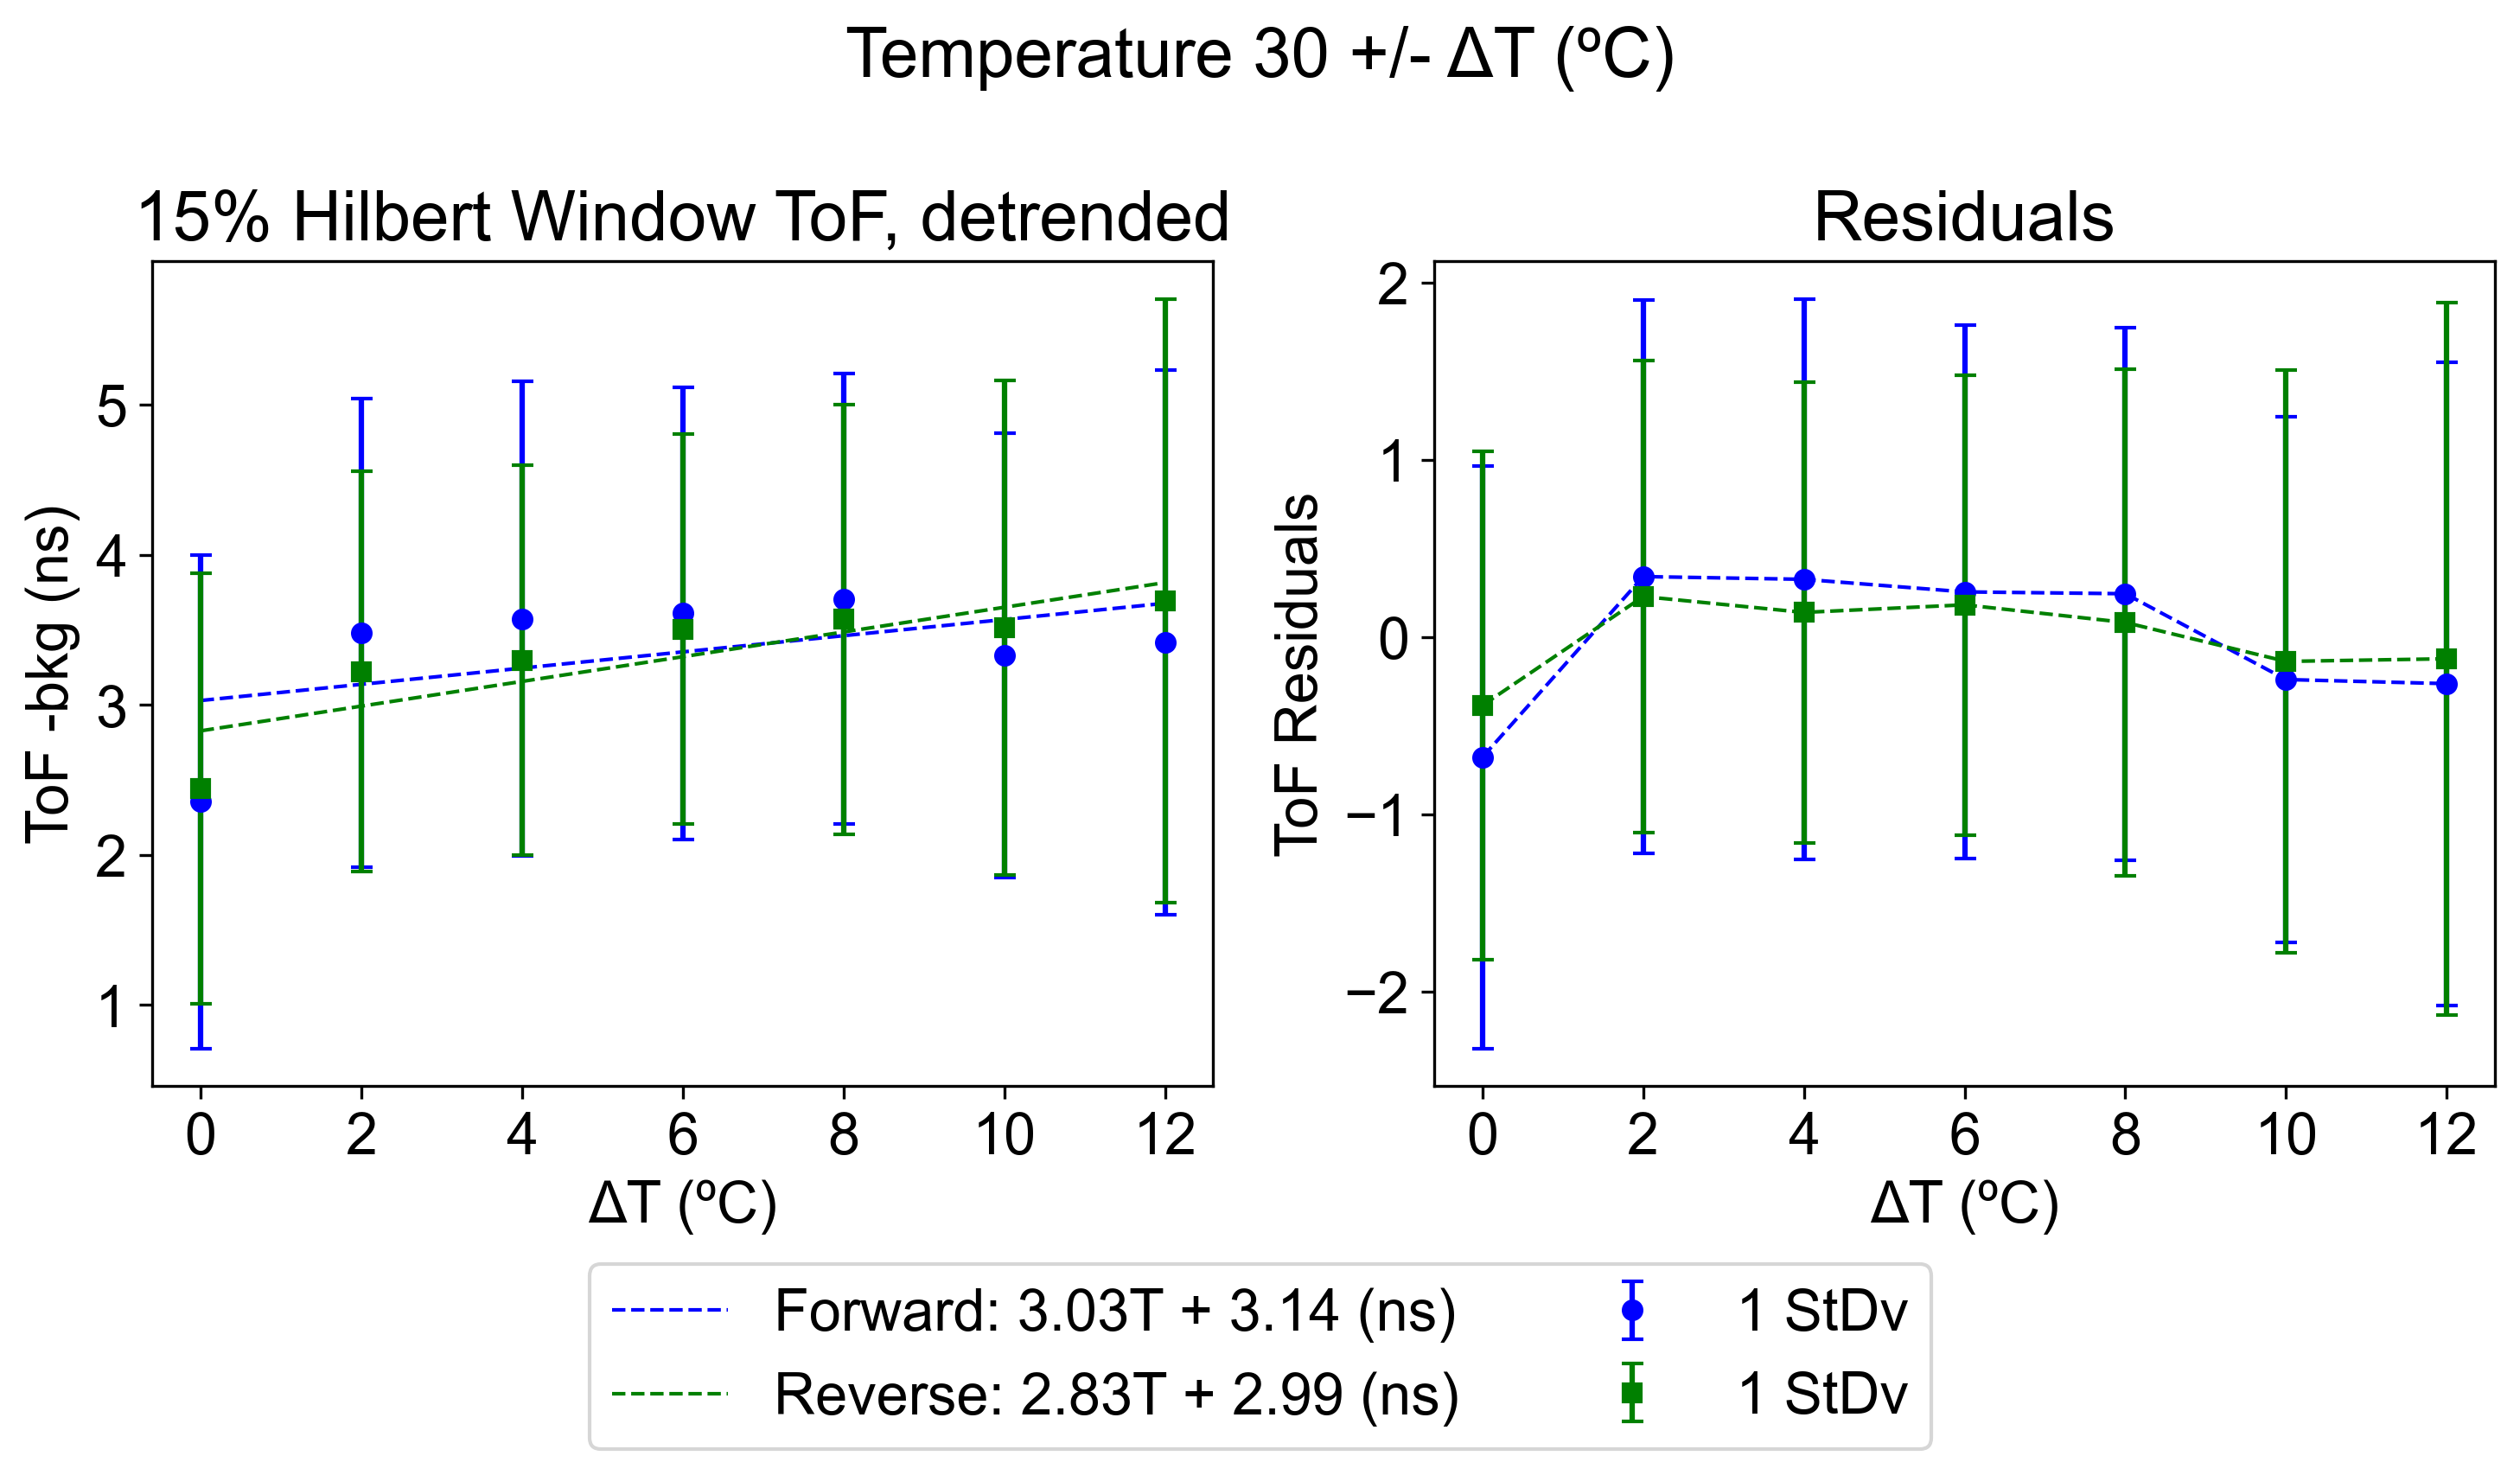

In [ ]:
# plot hilbert window tof
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_hilbert_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_hilbert_tof_fit[0]:.2f}T + {f_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, f_hilbert_tof_arr, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_hilbert_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_hilbert_tof_fit[0]:.2f}T + {r_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, r_hilbert_tof_arr, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% Hilbert Window ToF, detrended')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('ToF -bkg (ns)' )

ax[1].plot(d_temps, f_hilbert_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_hilbert_tof_residuals, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_hilbert_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_hilbert_tof_residuals, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('ToF Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)
fig.tight_layout()

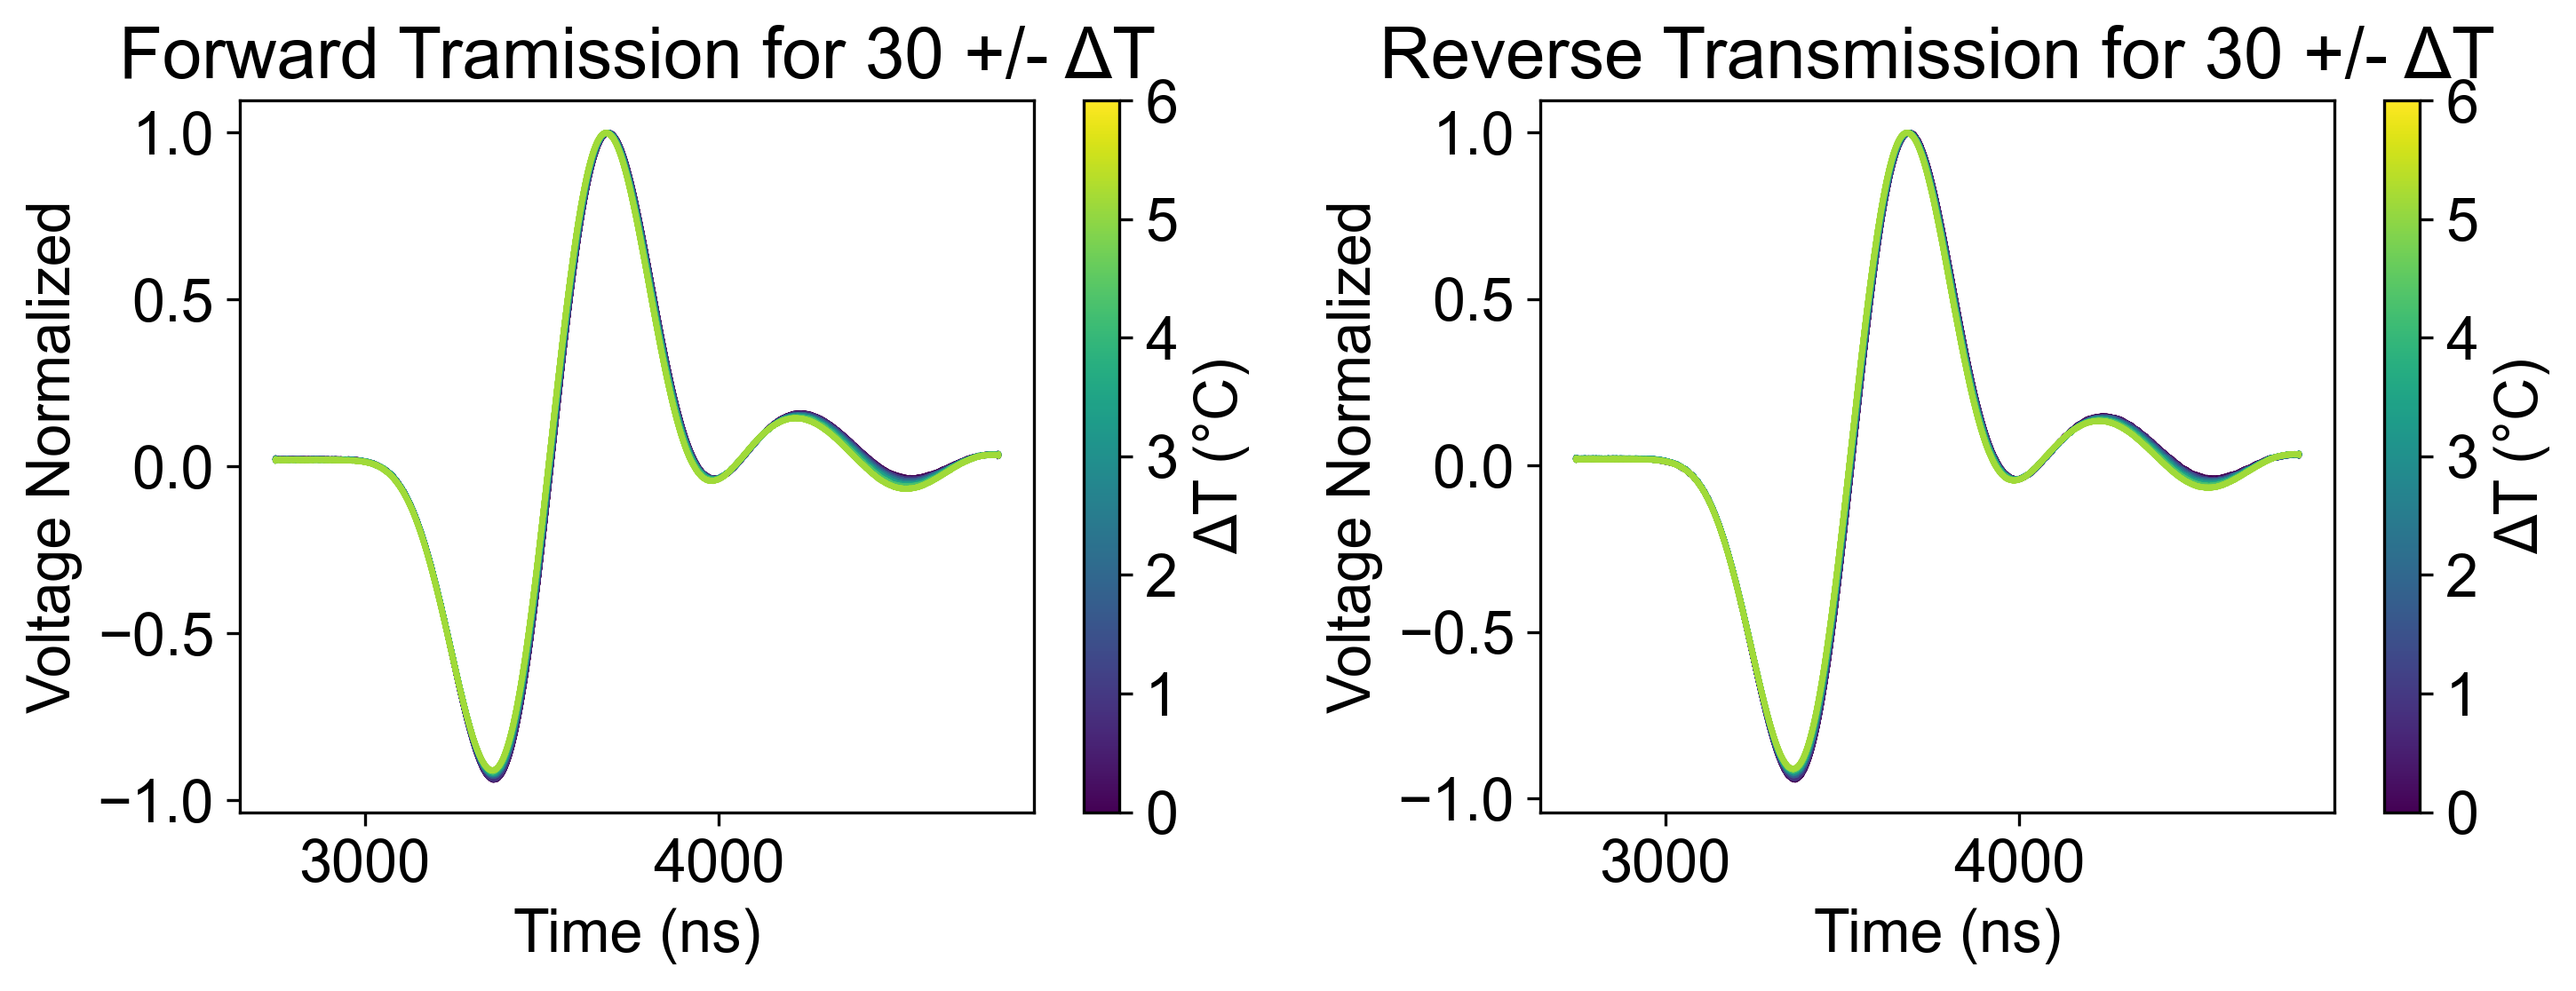

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i in range(7):
    mask = (merged_filtered_df['3000.1: CH1 Target'] == 30+i) & \
           (merged_filtered_df['3000.2: CH2 Target'] == 30-i) & \
           (merged_filtered_df.index > 750)
           
    for idx, row in merged_filtered_df.loc[mask].iloc[-10:].iterrows():
        ax[0].plot(
            row['time'][:1200],
            row['voltage_transmission_forward'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
        ax[1].plot(
            row['time'][:1200],
            row['voltage_transmission_reverse'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel('Voltage Normalized')
ax[0].set_title(f'Forward Tramission for 30 +/- ΔT')
# ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel('Voltage Normalized')
ax[1].set_title(f'Reverse Transmission for 30 +/- ΔT')
ax[1].set_xlabel('Time (ns)')

sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(vmin=0, vmax=6))
cbar = fig.colorbar(sm, ax=ax[0], label='ΔT (°C)', pad=0.05)
cbar = fig.colorbar(sm, ax=ax[1], label='ΔT (°C)', pad=0.05)

fig.tight_layout()

#### gradient 1

In [ ]:
df = merged_filtered_df.iloc[755:1500]

def run_plotter(i=0, keys_=()): plot_temps(i=i, keys_=list(keys_), idx_lable_type='dT')

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

selected_keys = [col for col in df.columns if col.startswith(('Simple_ToF', 'Hilbert_ToF', 'amplitude'))]
selected_keys.sort()
keys = widgets.SelectMultiple(
    options=selected_keys,
    value=tuple([]),
    description='Variable:',
    disabled=False,
)

interact(lambda i, key_: run_plotter(i=i, keys_=list(key_)), i=slider, key_=keys)

interactive(children=(IntSlider(value=0, continuous_update=False, description='measurement:', max=744), Select…

<function __main__.<lambda>(i, key_)>

In [ ]:
# calculate trends and detrended data for dT experiments
import matplotlib.pyplot as plt
d_temps = range(0, 14, 2)
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []
f_simple_tof_arr, f_simple_tof_err = [], []
r_simple_tof_arr, r_simple_tof_err = [], []
f_hilbert_tof_arr, f_hilbert_tof_err = [], []
r_hilbert_tof_arr, r_hilbert_tof_err = [], []

for i in range(7):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 30 + i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 30 - i)
        & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
        & (merged_filtered_df.index > 755)
    )
    filtered_df = merged_filtered_df[mask]
    if filtered_df.empty: 
        print(i)
        continue
    
    f_amp_arr.append(filtered_df[f'amplitude_forward_normalized'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward_normalized'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse_normalized'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse_normalized'].std())
    
    f_simple_tof_arr.append(filtered_df[f'Simple_ToF_forward (ns)'].mean())
    f_simple_tof_err.append(filtered_df[f'Simple_ToF_forward (ns)'].std())
    
    r_simple_tof_arr.append(filtered_df[f'Simple_ToF_reverse (ns)'].mean())
    r_simple_tof_err.append(filtered_df[f'Simple_ToF_reverse (ns)'].std())
    
    f_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_forward (ns)'].mean())
    f_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_forward (ns)'].std())
    
    r_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].mean())
    r_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].std())
    
f_amp_fit = np.polyfit(d_temps, f_amp_arr, 1)
f_amp_fit = f_amp_fit[0] * np.array(d_temps) + f_amp_fit[1]
r_amp_fit = np.polyfit(d_temps, r_amp_arr, 1)
r_amp_fit = r_amp_fit[0] * np.array(d_temps) + r_amp_fit[1]
f_amp_residuals = f_amp_arr - f_amp_fit
r_amp_residuals = r_amp_arr - r_amp_fit

f_simple_tof_fit = np.polyfit(d_temps, f_simple_tof_arr, 1)
f_simple_tof_fit = f_simple_tof_fit[0] * np.array(d_temps) + f_simple_tof_fit[1]
r_simple_tof_fit = np.polyfit(d_temps, r_simple_tof_arr, 1)
r_simple_tof_fit = r_simple_tof_fit[0] * np.array(d_temps) + r_simple_tof_fit[1]
f_simple_tof_residuals = f_simple_tof_arr - f_simple_tof_fit
r_simple_tof_residuals = r_simple_tof_arr - r_simple_tof_fit

f_hilbert_tof_fit = np.polyfit(d_temps, f_hilbert_tof_arr, 1)
f_hilbert_tof_fit = f_hilbert_tof_fit[0] * np.array(d_temps) + f_hilbert_tof_fit[1]
r_hilbert_tof_fit = np.polyfit(d_temps, r_hilbert_tof_arr, 1)
r_hilbert_tof_fit = r_hilbert_tof_fit[0] * np.array(d_temps) + r_hilbert_tof_fit[1]
f_hilbert_tof_residuals = f_hilbert_tof_arr - f_hilbert_tof_fit
r_hilbert_tof_residuals = r_hilbert_tof_arr - r_hilbert_tof_fit

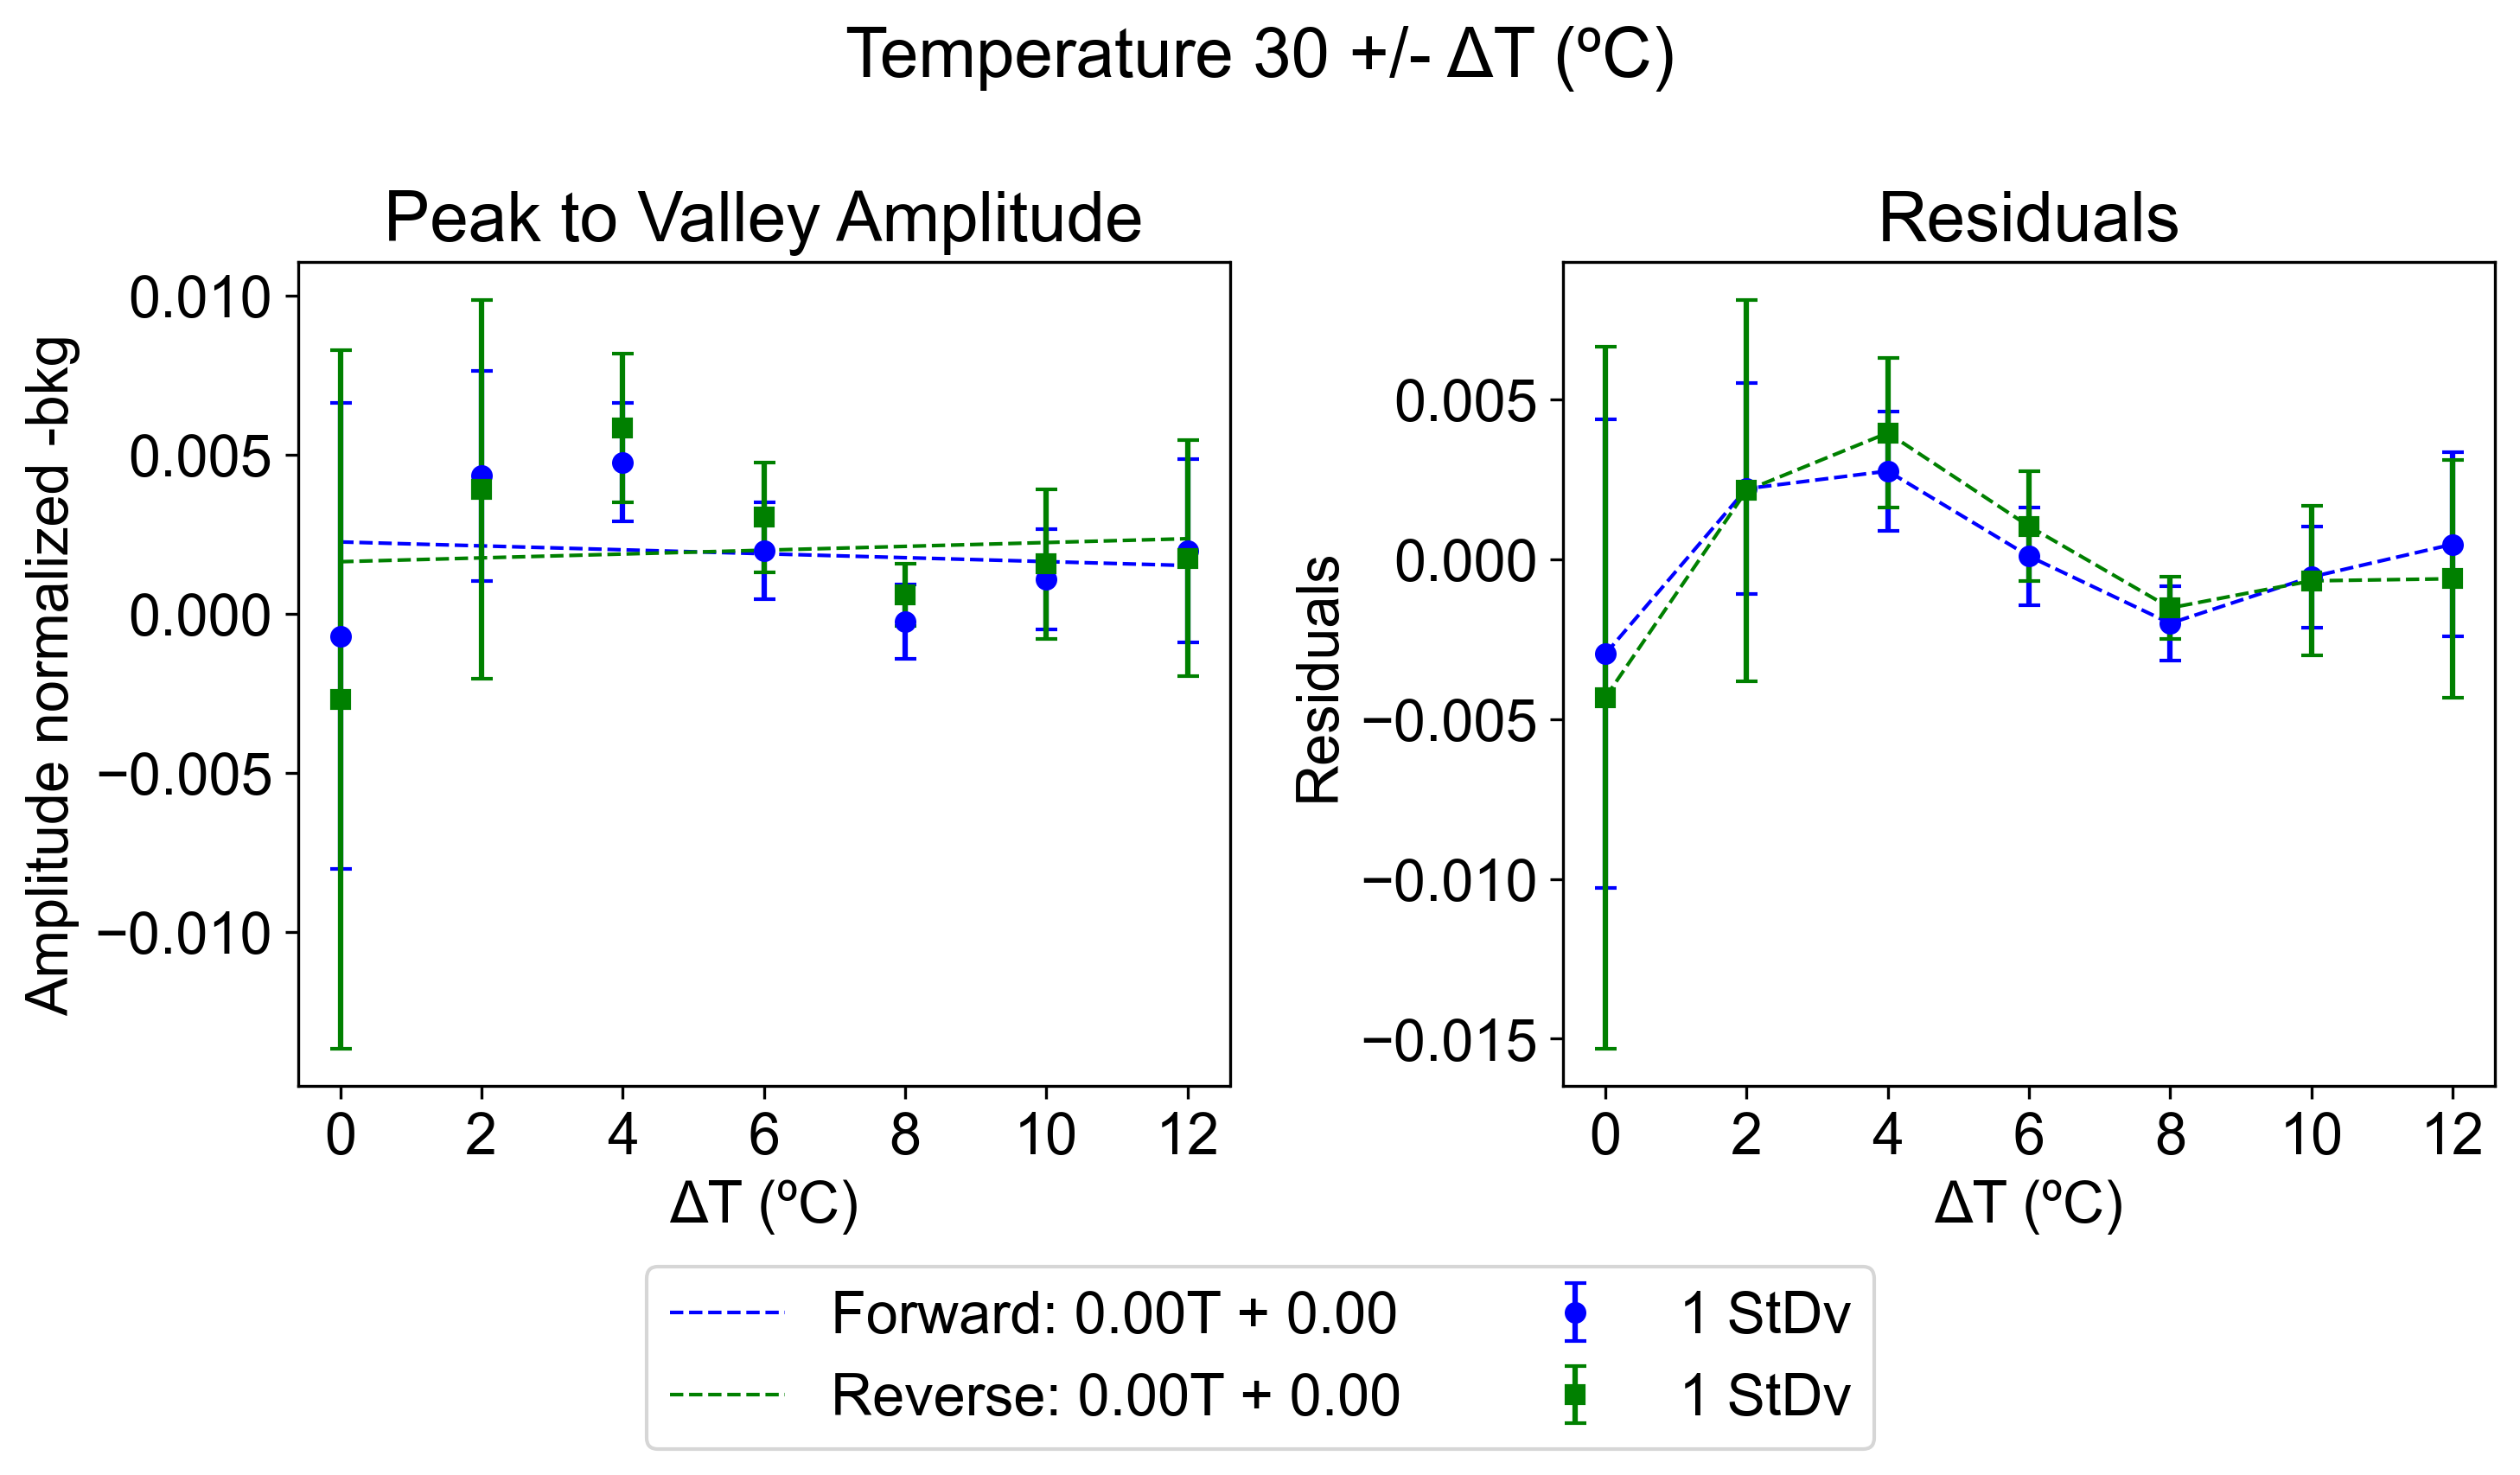

In [ ]:
# plot amplitude
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_amp_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_amp_fit[0]:.2f}T + {f_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_amp_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_amp_fit[0]:.2f}T + {r_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('Peak to Valley Amplitude')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('Amplitude normalized -bkg')

ax[1].plot(d_temps, f_amp_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_amp_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_amp_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_amp_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

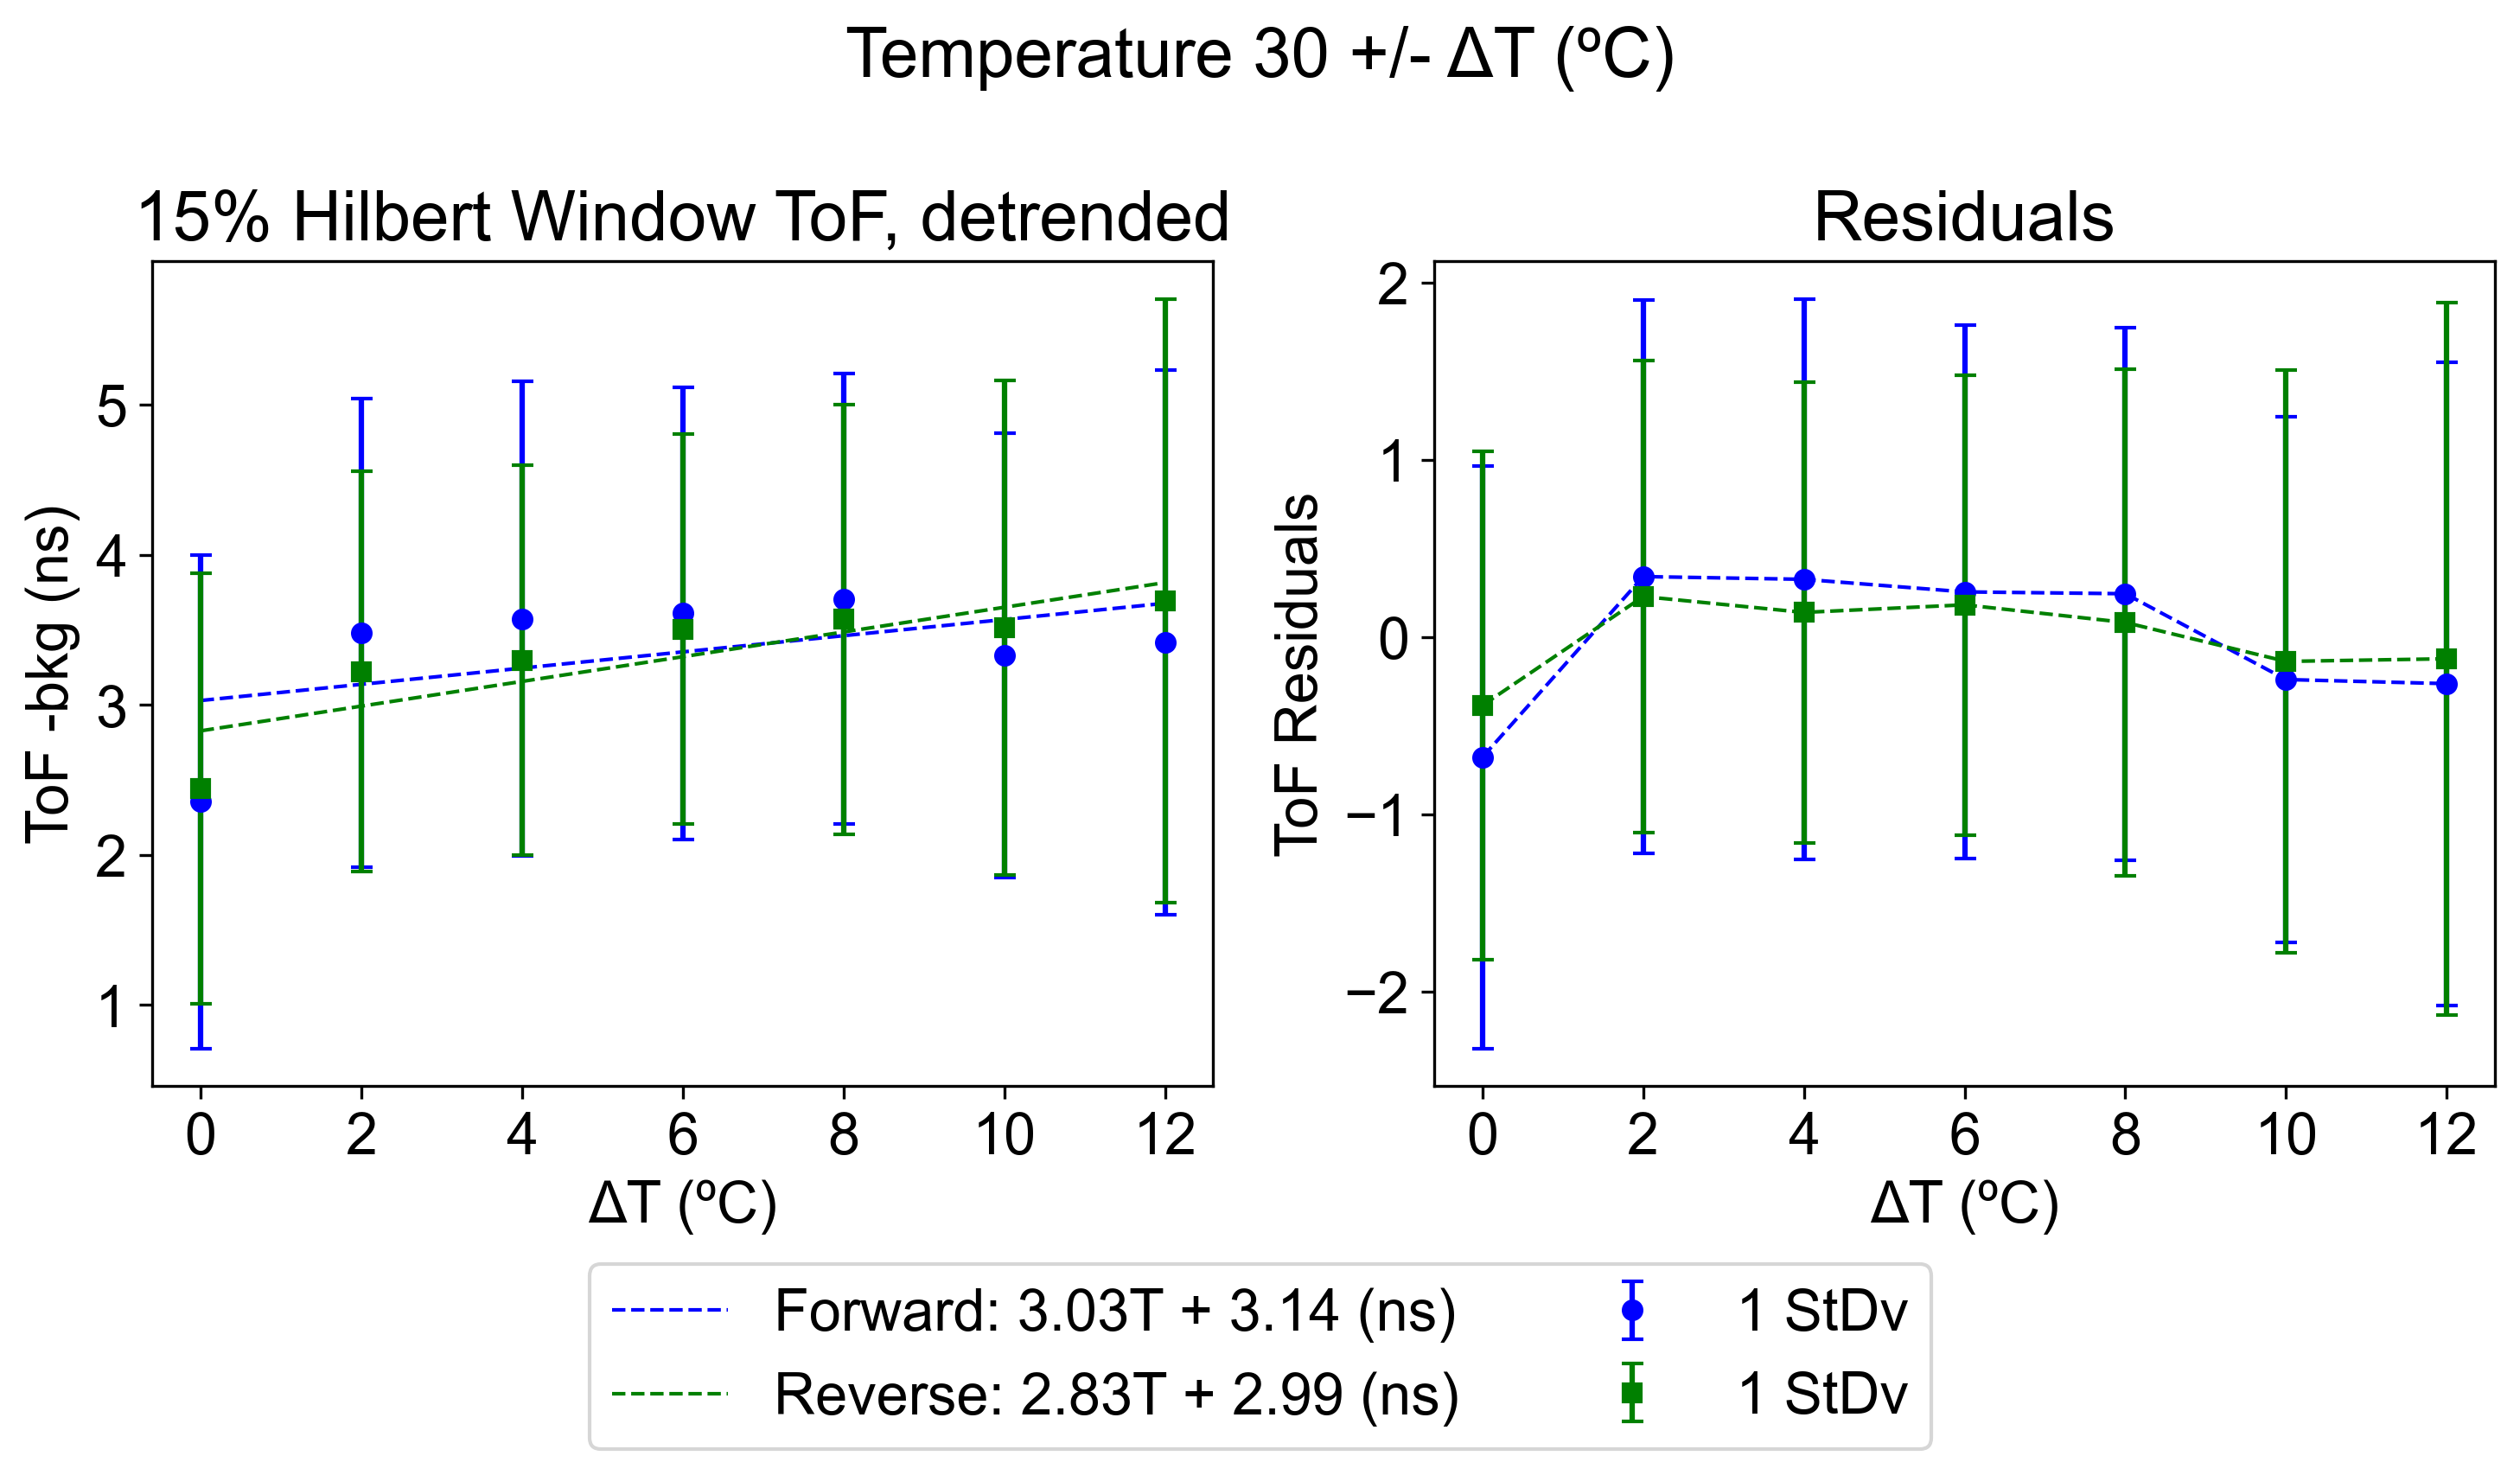

In [ ]:
# plot hilbert window tof
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_hilbert_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_hilbert_tof_fit[0]:.2f}T + {f_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, f_hilbert_tof_arr, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_hilbert_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_hilbert_tof_fit[0]:.2f}T + {r_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, r_hilbert_tof_arr, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% Hilbert Window ToF, detrended')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('ToF -bkg (ns)' )

ax[1].plot(d_temps, f_hilbert_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_hilbert_tof_residuals, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_hilbert_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_hilbert_tof_residuals, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('ToF Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)
fig.tight_layout()

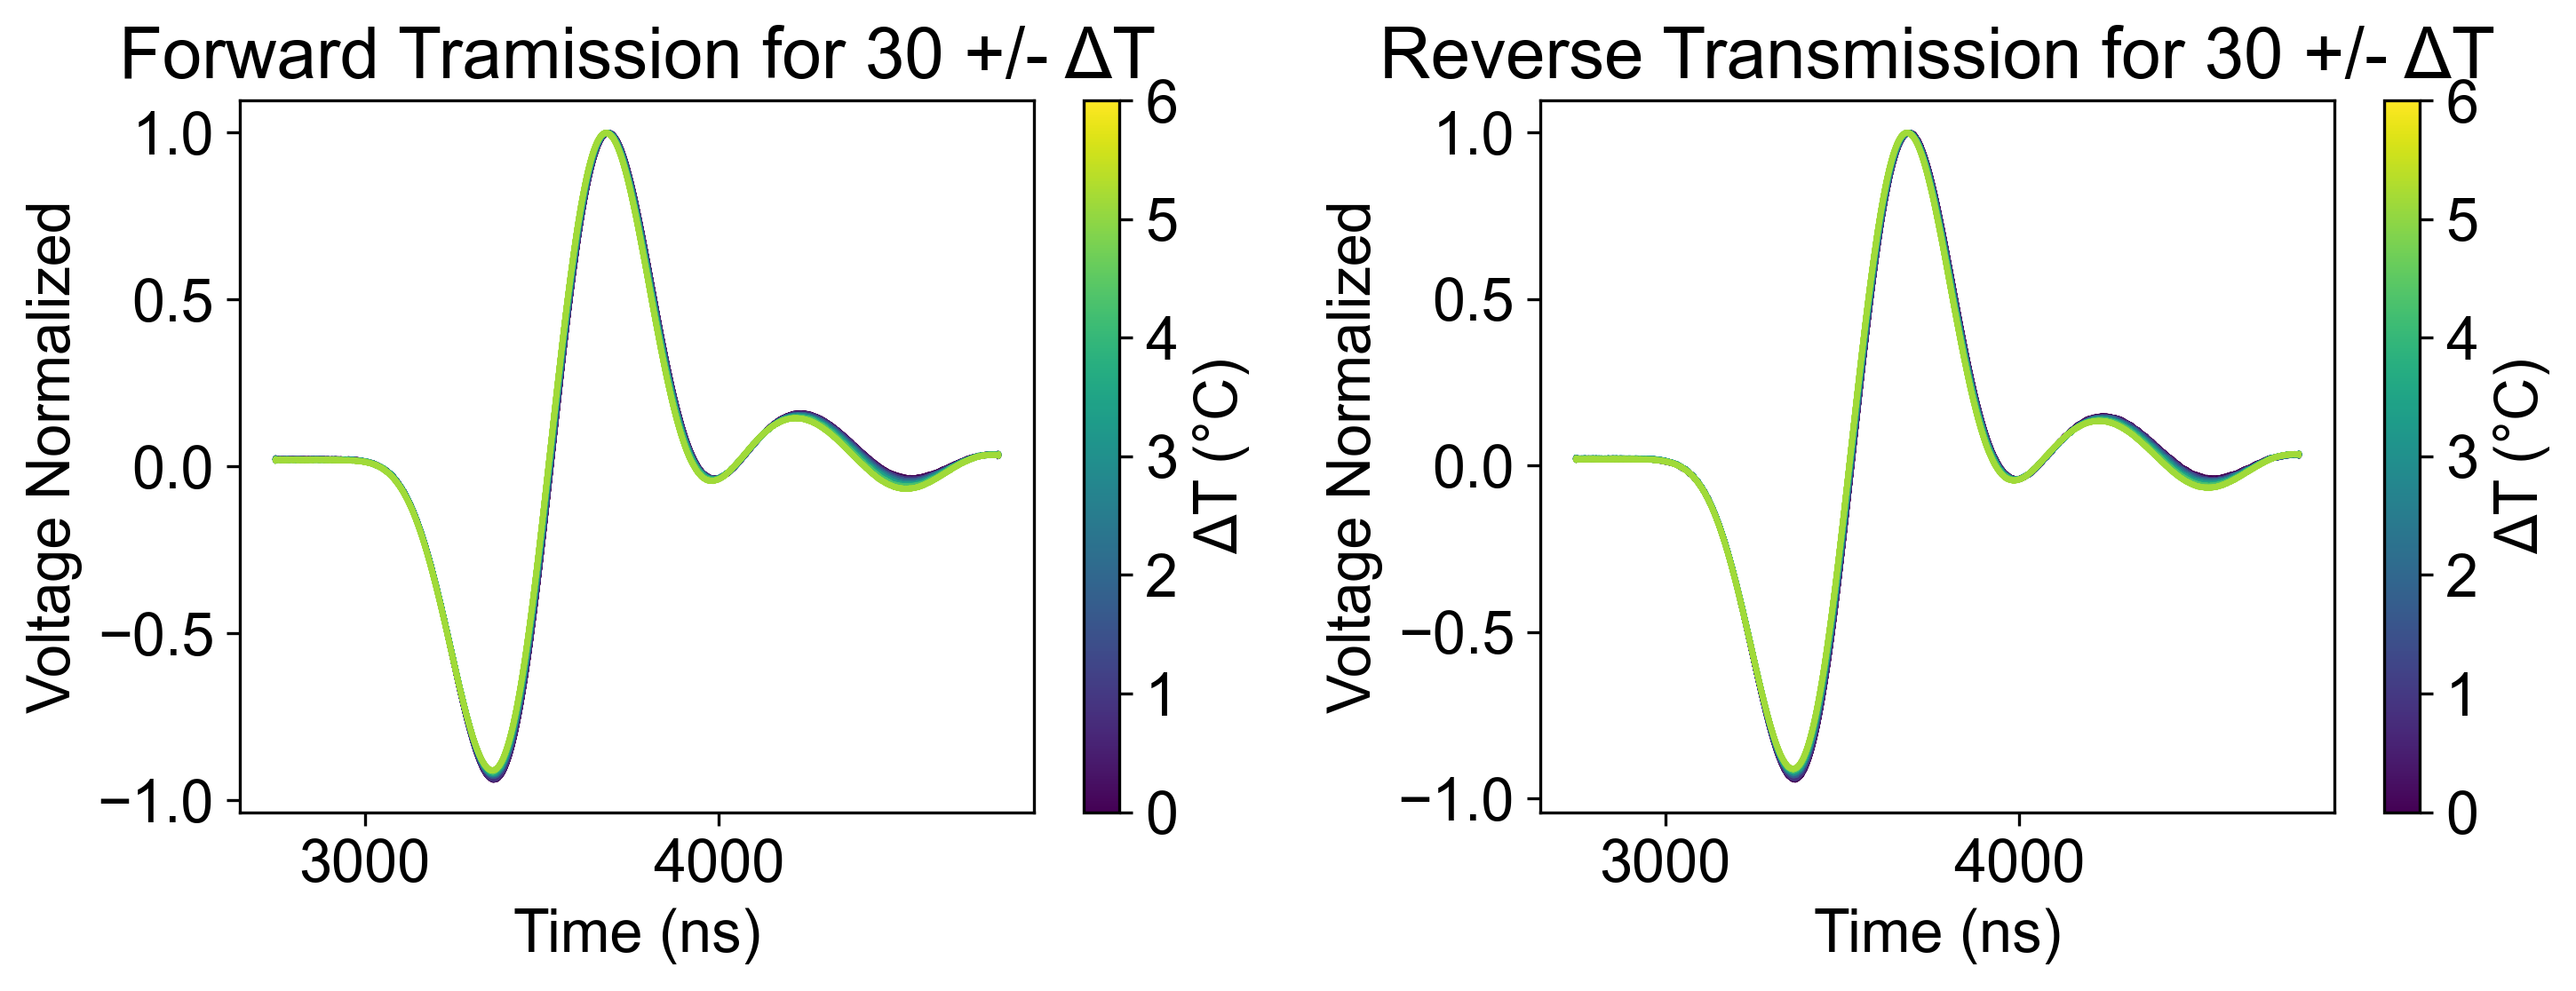

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i in range(7):
    mask = (merged_filtered_df['3000.1: CH1 Target'] == 30+i) & \
           (merged_filtered_df['3000.2: CH2 Target'] == 30-i) & \
           (merged_filtered_df.index > 750)
           
    for idx, row in merged_filtered_df.loc[mask].iloc[-10:].iterrows():
        ax[0].plot(
            row['time'][:1200],
            row['voltage_transmission_forward'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
        ax[1].plot(
            row['time'][:1200],
            row['voltage_transmission_reverse'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel('Voltage Normalized')
ax[0].set_title(f'Forward Tramission for 30 +/- ΔT')
# ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel('Voltage Normalized')
ax[1].set_title(f'Reverse Transmission for 30 +/- ΔT')
ax[1].set_xlabel('Time (ns)')

sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(vmin=0, vmax=6))
cbar = fig.colorbar(sm, ax=ax[0], label='ΔT (°C)', pad=0.05)
cbar = fig.colorbar(sm, ax=ax[1], label='ΔT (°C)', pad=0.05)

fig.tight_layout()

#### gradient 1

In [ ]:
df = merged_filtered_df.iloc[755:1500]

def run_plotter(i=0, keys_=()): plot_temps(i=i, keys_=list(keys_), idx_lable_type='dT')

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

selected_keys = [col for col in df.columns if col.startswith(('Simple_ToF', 'Hilbert_ToF', 'amplitude'))]
selected_keys.sort()
keys = widgets.SelectMultiple(
    options=selected_keys,
    value=tuple([]),
    description='Variable:',
    disabled=False,
)

interact(lambda i, key_: run_plotter(i=i, keys_=list(key_)), i=slider, key_=keys)

interactive(children=(IntSlider(value=0, continuous_update=False, description='measurement:', max=744), Select…

<function __main__.<lambda>(i, key_)>

In [ ]:
# calculate trends and detrended data for dT experiments
import matplotlib.pyplot as plt
d_temps = range(0, 14, 2)
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []
f_simple_tof_arr, f_simple_tof_err = [], []
r_simple_tof_arr, r_simple_tof_err = [], []
f_hilbert_tof_arr, f_hilbert_tof_err = [], []
r_hilbert_tof_arr, r_hilbert_tof_err = [], []

for i in range(7):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 30 + i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 30 - i)
        & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
        & (merged_filtered_df.index > 755)
    )
    filtered_df = merged_filtered_df[mask]
    if filtered_df.empty: 
        print(i)
        continue
    
    f_amp_arr.append(filtered_df[f'amplitude_forward_normalized'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward_normalized'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse_normalized'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse_normalized'].std())
    
    f_simple_tof_arr.append(filtered_df[f'Simple_ToF_forward (ns)'].mean())
    f_simple_tof_err.append(filtered_df[f'Simple_ToF_forward (ns)'].std())
    
    r_simple_tof_arr.append(filtered_df[f'Simple_ToF_reverse (ns)'].mean())
    r_simple_tof_err.append(filtered_df[f'Simple_ToF_reverse (ns)'].std())
    
    f_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_forward (ns)'].mean())
    f_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_forward (ns)'].std())
    
    r_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].mean())
    r_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].std())
    
f_amp_fit = np.polyfit(d_temps, f_amp_arr, 1)
f_amp_fit = f_amp_fit[0] * np.array(d_temps) + f_amp_fit[1]
r_amp_fit = np.polyfit(d_temps, r_amp_arr, 1)
r_amp_fit = r_amp_fit[0] * np.array(d_temps) + r_amp_fit[1]
f_amp_residuals = f_amp_arr - f_amp_fit
r_amp_residuals = r_amp_arr - r_amp_fit

f_simple_tof_fit = np.polyfit(d_temps, f_simple_tof_arr, 1)
f_simple_tof_fit = f_simple_tof_fit[0] * np.array(d_temps) + f_simple_tof_fit[1]
r_simple_tof_fit = np.polyfit(d_temps, r_simple_tof_arr, 1)
r_simple_tof_fit = r_simple_tof_fit[0] * np.array(d_temps) + r_simple_tof_fit[1]
f_simple_tof_residuals = f_simple_tof_arr - f_simple_tof_fit
r_simple_tof_residuals = r_simple_tof_arr - r_simple_tof_fit

f_hilbert_tof_fit = np.polyfit(d_temps, f_hilbert_tof_arr, 1)
f_hilbert_tof_fit = f_hilbert_tof_fit[0] * np.array(d_temps) + f_hilbert_tof_fit[1]
r_hilbert_tof_fit = np.polyfit(d_temps, r_hilbert_tof_arr, 1)
r_hilbert_tof_fit = r_hilbert_tof_fit[0] * np.array(d_temps) + r_hilbert_tof_fit[1]
f_hilbert_tof_residuals = f_hilbert_tof_arr - f_hilbert_tof_fit
r_hilbert_tof_residuals = r_hilbert_tof_arr - r_hilbert_tof_fit

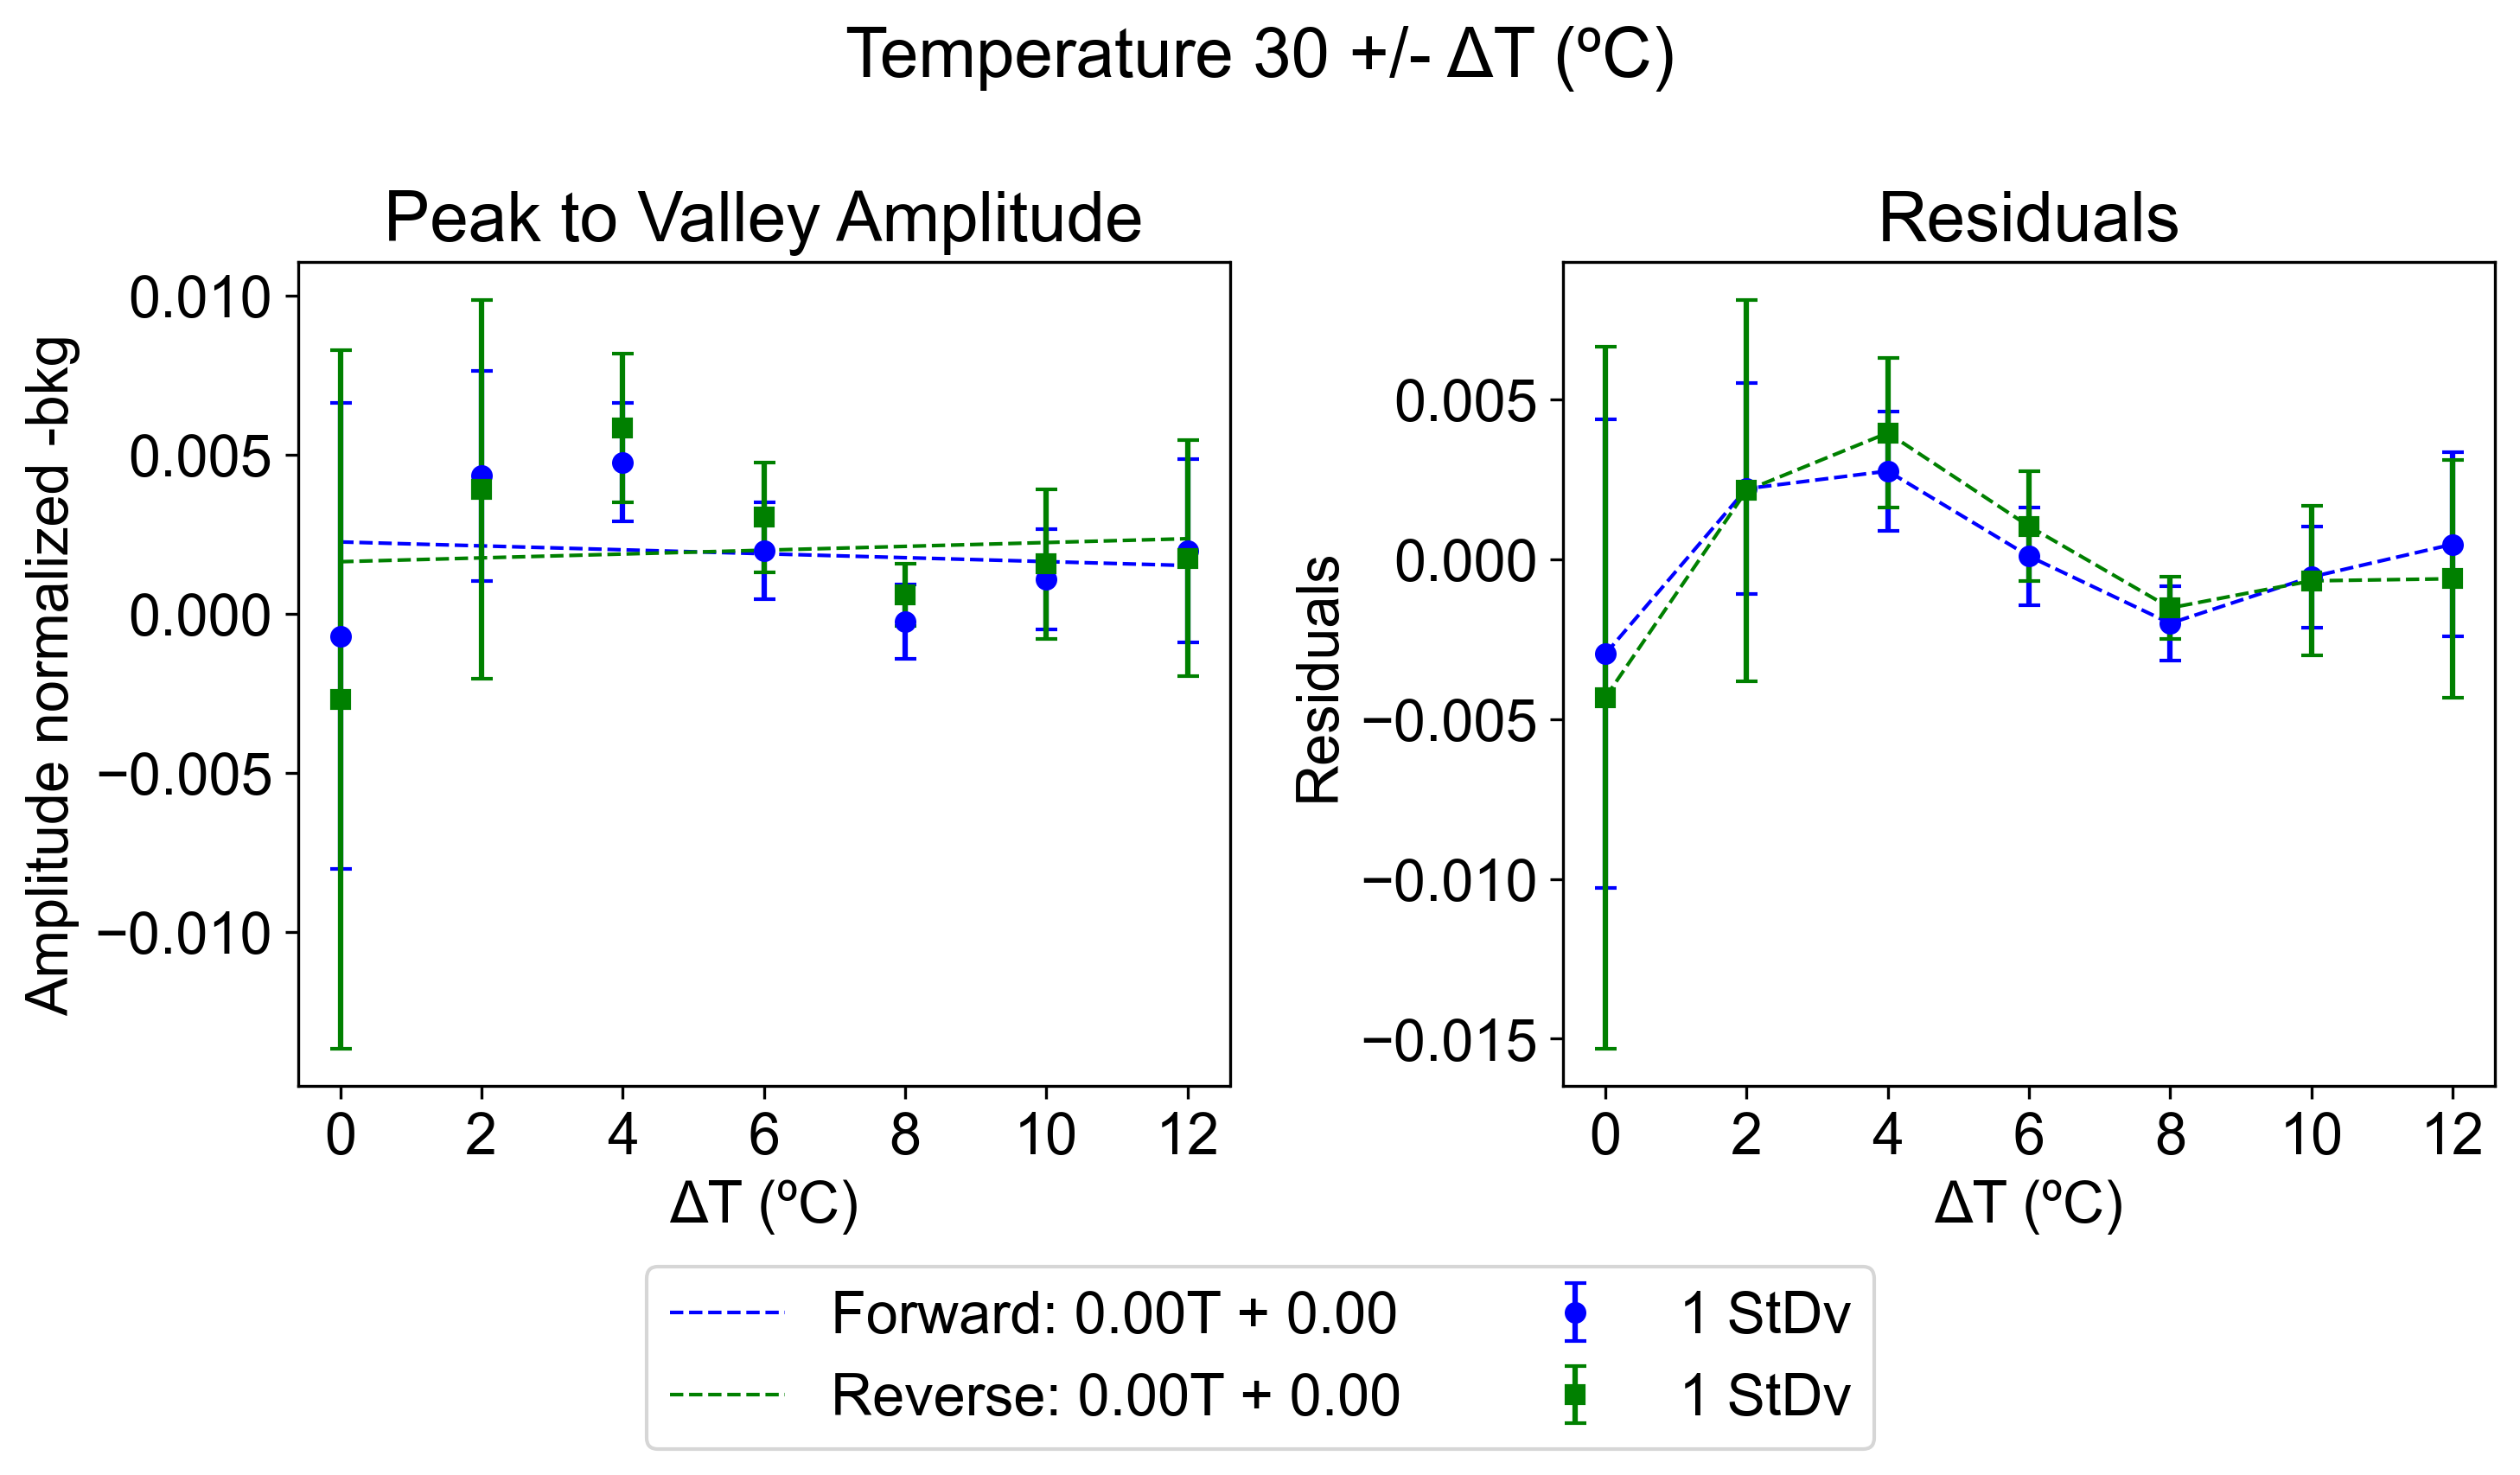

In [ ]:
# plot amplitude
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_amp_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_amp_fit[0]:.2f}T + {f_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_amp_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_amp_fit[0]:.2f}T + {r_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('Peak to Valley Amplitude')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('Amplitude normalized -bkg')

ax[1].plot(d_temps, f_amp_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_amp_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_amp_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_amp_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

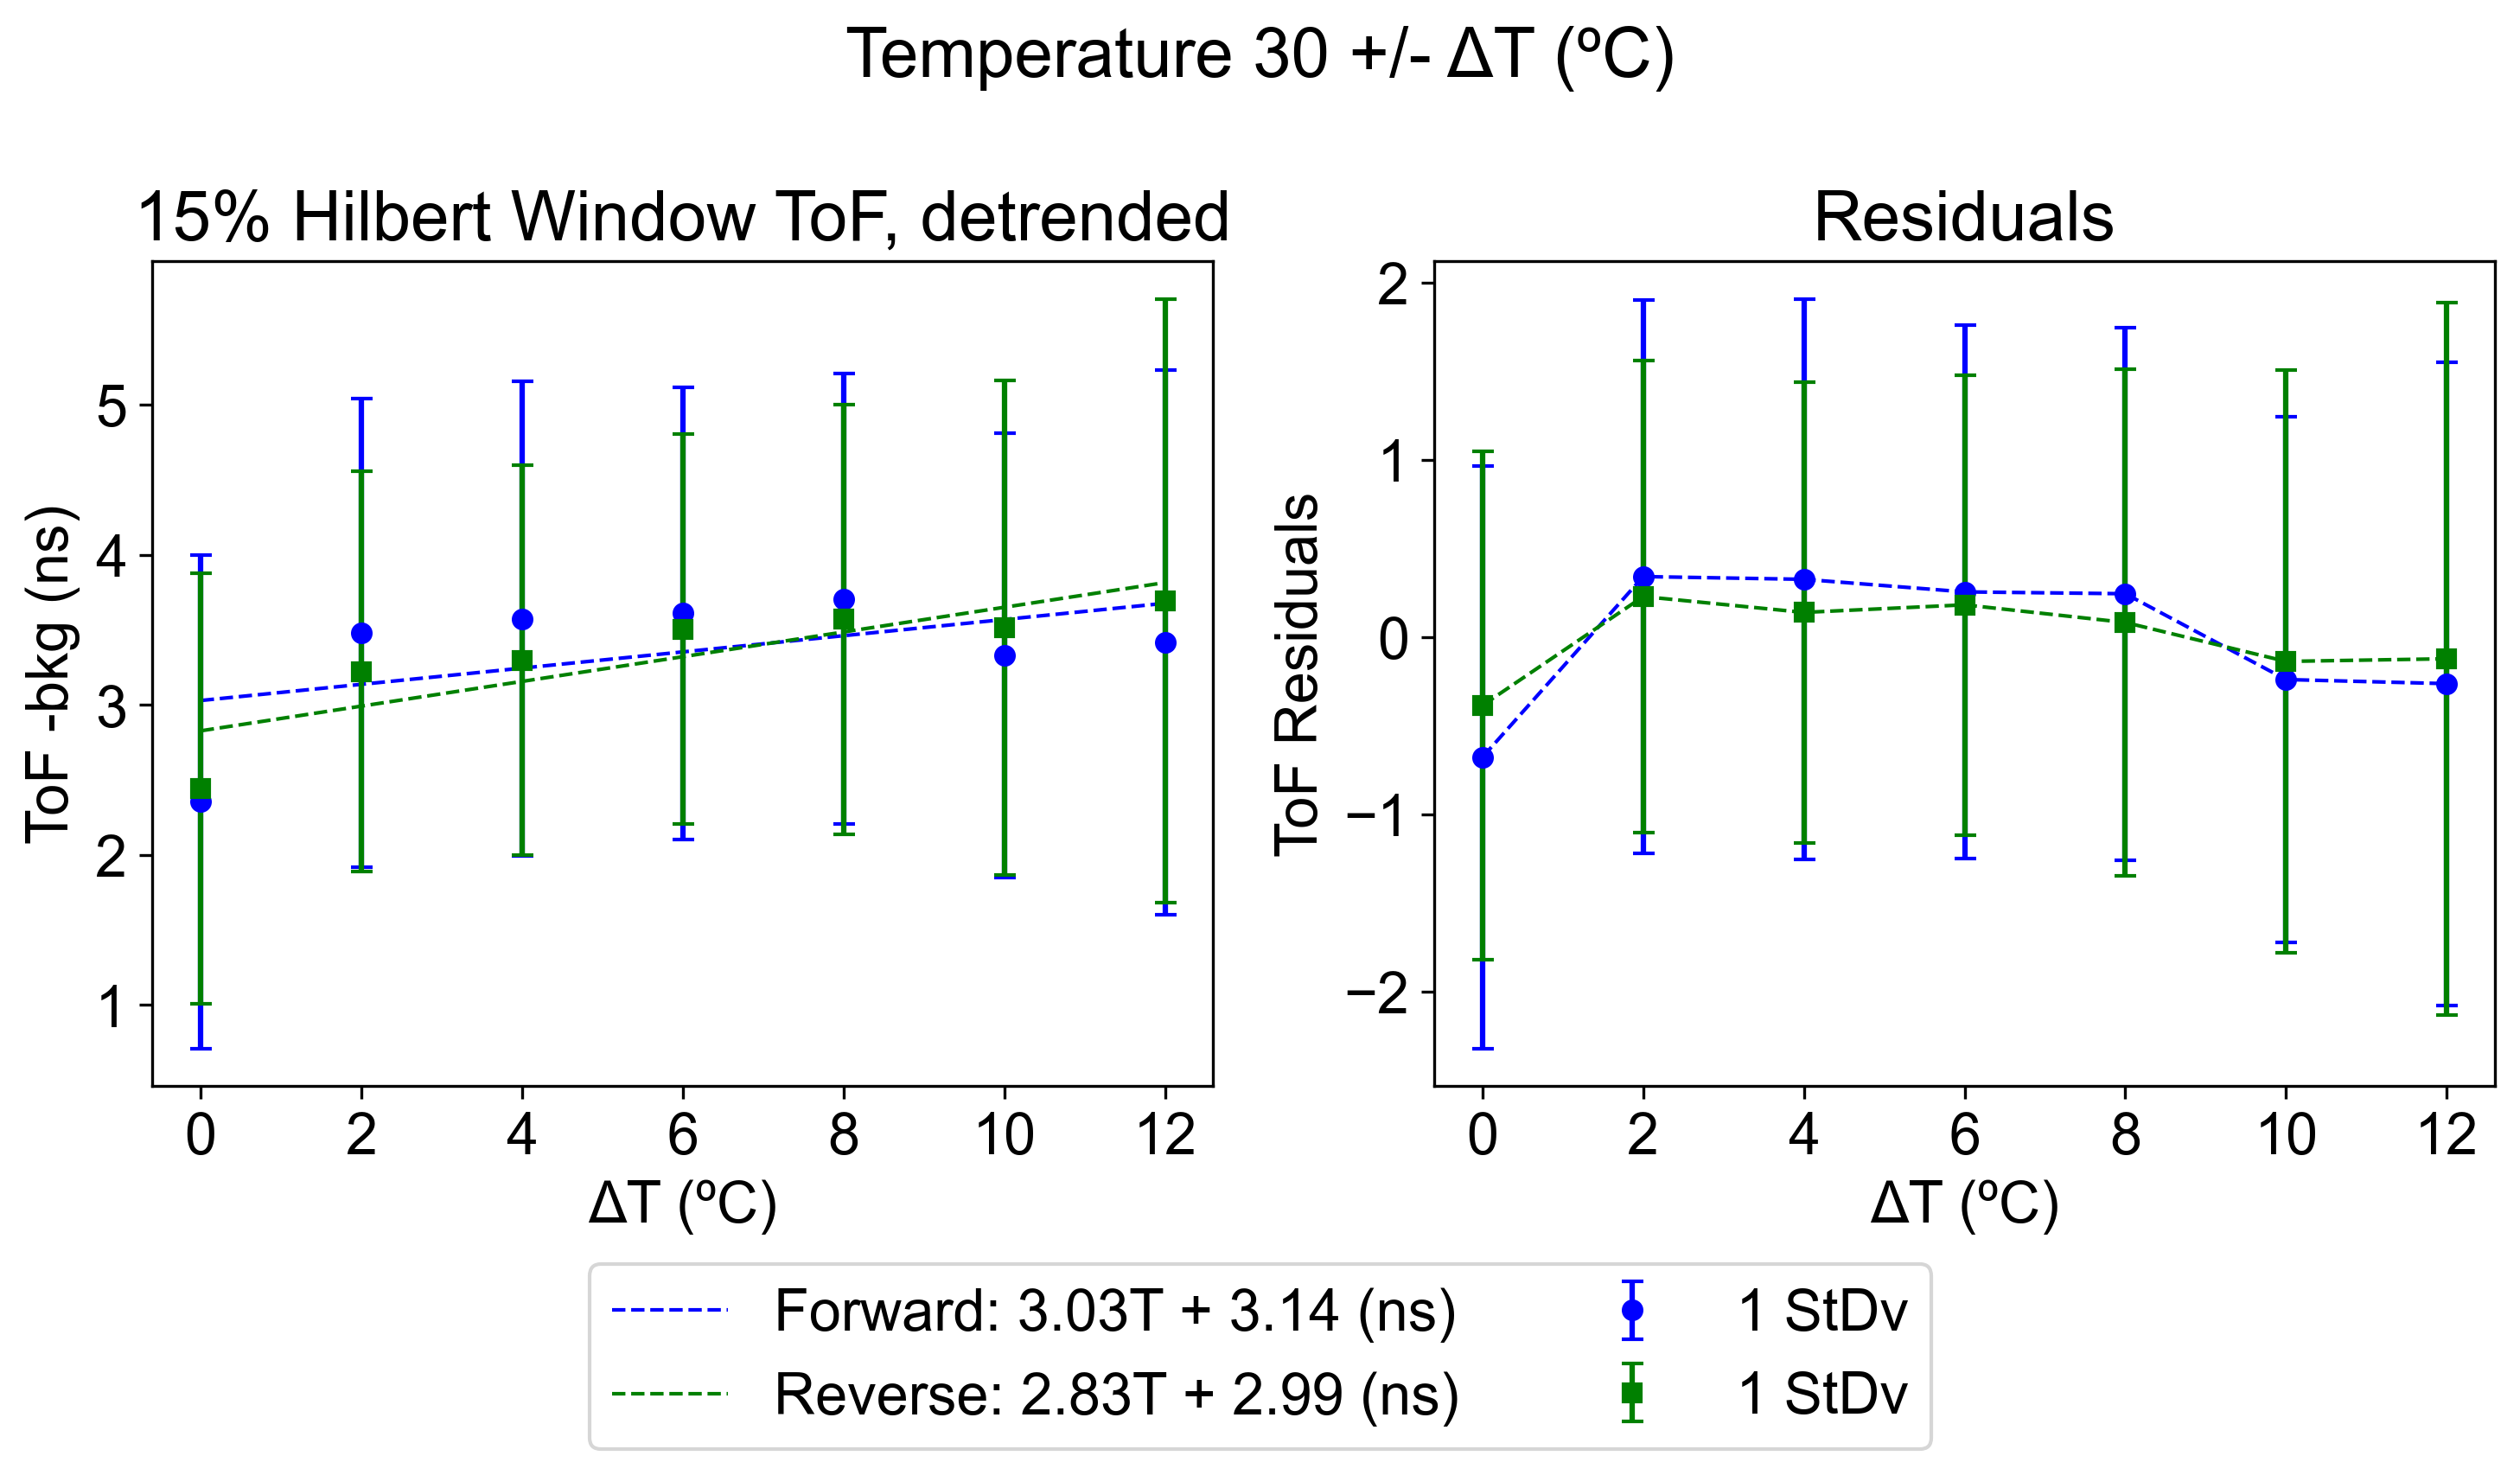

In [ ]:
# plot hilbert window tof
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_hilbert_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_hilbert_tof_fit[0]:.2f}T + {f_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, f_hilbert_tof_arr, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_hilbert_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_hilbert_tof_fit[0]:.2f}T + {r_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, r_hilbert_tof_arr, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% Hilbert Window ToF, detrended')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('ToF -bkg (ns)' )

ax[1].plot(d_temps, f_hilbert_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_hilbert_tof_residuals, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_hilbert_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_hilbert_tof_residuals, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('ToF Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)
fig.tight_layout()

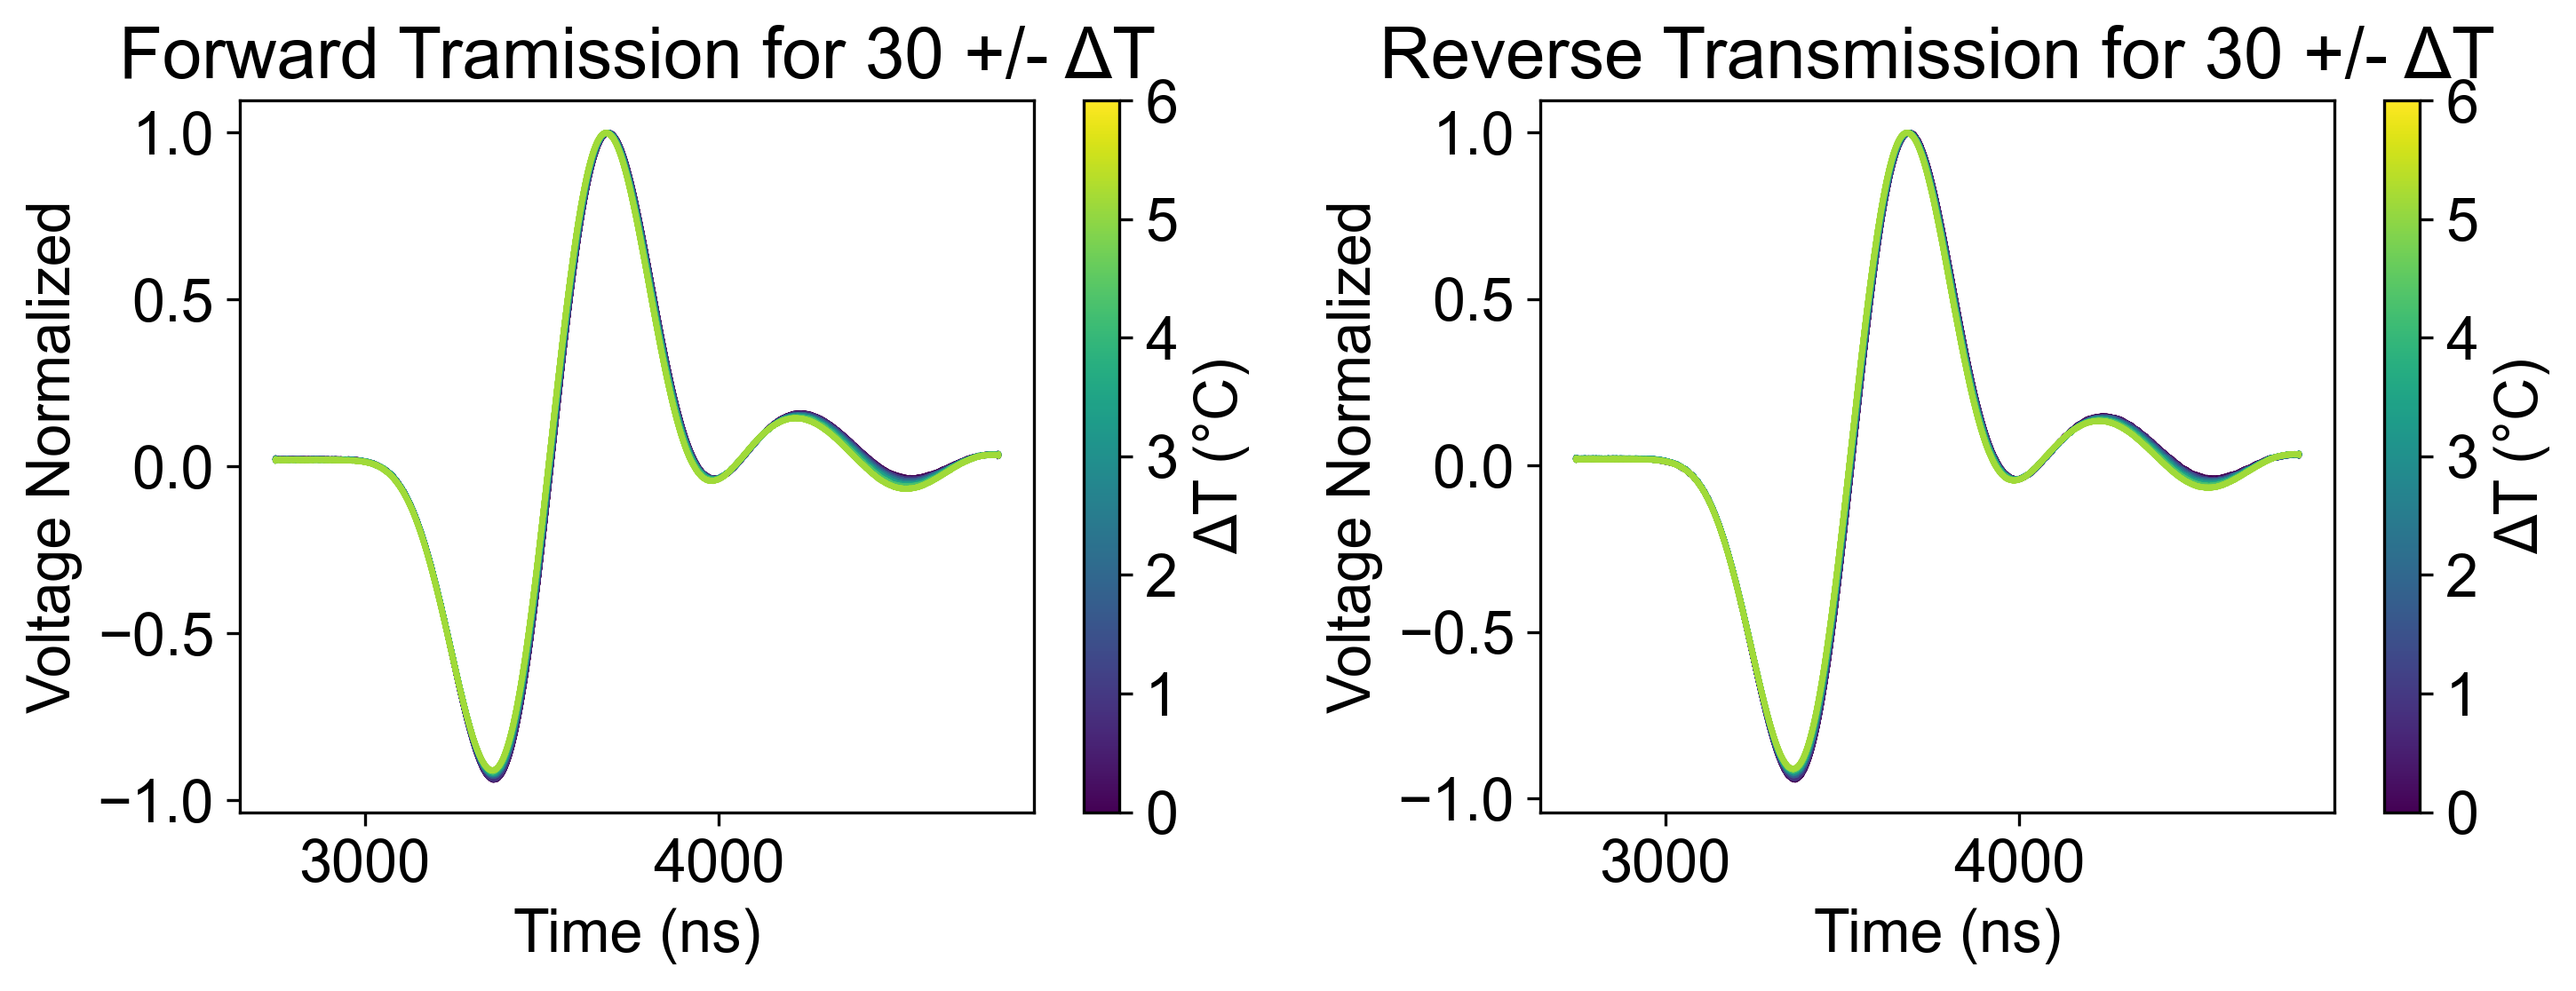

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i in range(7):
    mask = (merged_filtered_df['3000.1: CH1 Target'] == 30+i) & \
           (merged_filtered_df['3000.2: CH2 Target'] == 30-i) & \
           (merged_filtered_df.index > 750)
           
    for idx, row in merged_filtered_df.loc[mask].iloc[-10:].iterrows():
        ax[0].plot(
            row['time'][:1200],
            row['voltage_transmission_forward'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
        ax[1].plot(
            row['time'][:1200],
            row['voltage_transmission_reverse'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel('Voltage Normalized')
ax[0].set_title(f'Forward Tramission for 30 +/- ΔT')
# ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel('Voltage Normalized')
ax[1].set_title(f'Reverse Transmission for 30 +/- ΔT')
ax[1].set_xlabel('Time (ns)')

sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(vmin=0, vmax=6))
cbar = fig.colorbar(sm, ax=ax[0], label='ΔT (°C)', pad=0.05)
cbar = fig.colorbar(sm, ax=ax[1], label='ΔT (°C)', pad=0.05)

fig.tight_layout()

In [ ]:
# calculate trends and detrended data for dT experiments
import matplotlib.pyplot as plt
d_temps = range(0, 14, 2)
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []
f_simple_tof_arr, f_simple_tof_err = [], []
r_simple_tof_arr, r_simple_tof_err = [], []
f_hilbert_tof_arr, f_hilbert_tof_err = [], []
r_hilbert_tof_arr, r_hilbert_tof_err = [], []

for i in range(7):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 30 + i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 30 - i)
        & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
        & (merged_filtered_df.index > 755)
    )
    filtered_df = merged_filtered_df[mask]
    if filtered_df.empty: 
        print(i)
        continue
    
    f_amp_arr.append(filtered_df[f'amplitude_forward_normalized'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward_normalized'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse_normalized'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse_normalized'].std())
    
    f_simple_tof_arr.append(filtered_df[f'Simple_ToF_forward (ns)'].mean())
    f_simple_tof_err.append(filtered_df[f'Simple_ToF_forward (ns)'].std())
    
    r_simple_tof_arr.append(filtered_df[f'Simple_ToF_reverse (ns)'].mean())
    r_simple_tof_err.append(filtered_df[f'Simple_ToF_reverse (ns)'].std())
    
    f_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_forward (ns)'].mean())
    f_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_forward (ns)'].std())
    
    r_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].mean())
    r_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].std())
    
f_amp_fit = np.polyfit(d_temps, f_amp_arr, 1)
f_amp_fit = f_amp_fit[0] * np.array(d_temps) + f_amp_fit[1]
r_amp_fit = np.polyfit(d_temps, r_amp_arr, 1)
r_amp_fit = r_amp_fit[0] * np.array(d_temps) + r_amp_fit[1]
f_amp_residuals = f_amp_arr - f_amp_fit
r_amp_residuals = r_amp_arr - r_amp_fit

f_simple_tof_fit = np.polyfit(d_temps, f_simple_tof_arr, 1)
f_simple_tof_fit = f_simple_tof_fit[0] * np.array(d_temps) + f_simple_tof_fit[1]
r_simple_tof_fit = np.polyfit(d_temps, r_simple_tof_arr, 1)
r_simple_tof_fit = r_simple_tof_fit[0] * np.array(d_temps) + r_simple_tof_fit[1]
f_simple_tof_residuals = f_simple_tof_arr - f_simple_tof_fit
r_simple_tof_residuals = r_simple_tof_arr - r_simple_tof_fit

f_hilbert_tof_fit = np.polyfit(d_temps, f_hilbert_tof_arr, 1)
f_hilbert_tof_fit = f_hilbert_tof_fit[0] * np.array(d_temps) + f_hilbert_tof_fit[1]
r_hilbert_tof_fit = np.polyfit(d_temps, r_hilbert_tof_arr, 1)
r_hilbert_tof_fit = r_hilbert_tof_fit[0] * np.array(d_temps) + r_hilbert_tof_fit[1]
f_hilbert_tof_residuals = f_hilbert_tof_arr - f_hilbert_tof_fit
r_hilbert_tof_residuals = r_hilbert_tof_arr - r_hilbert_tof_fit

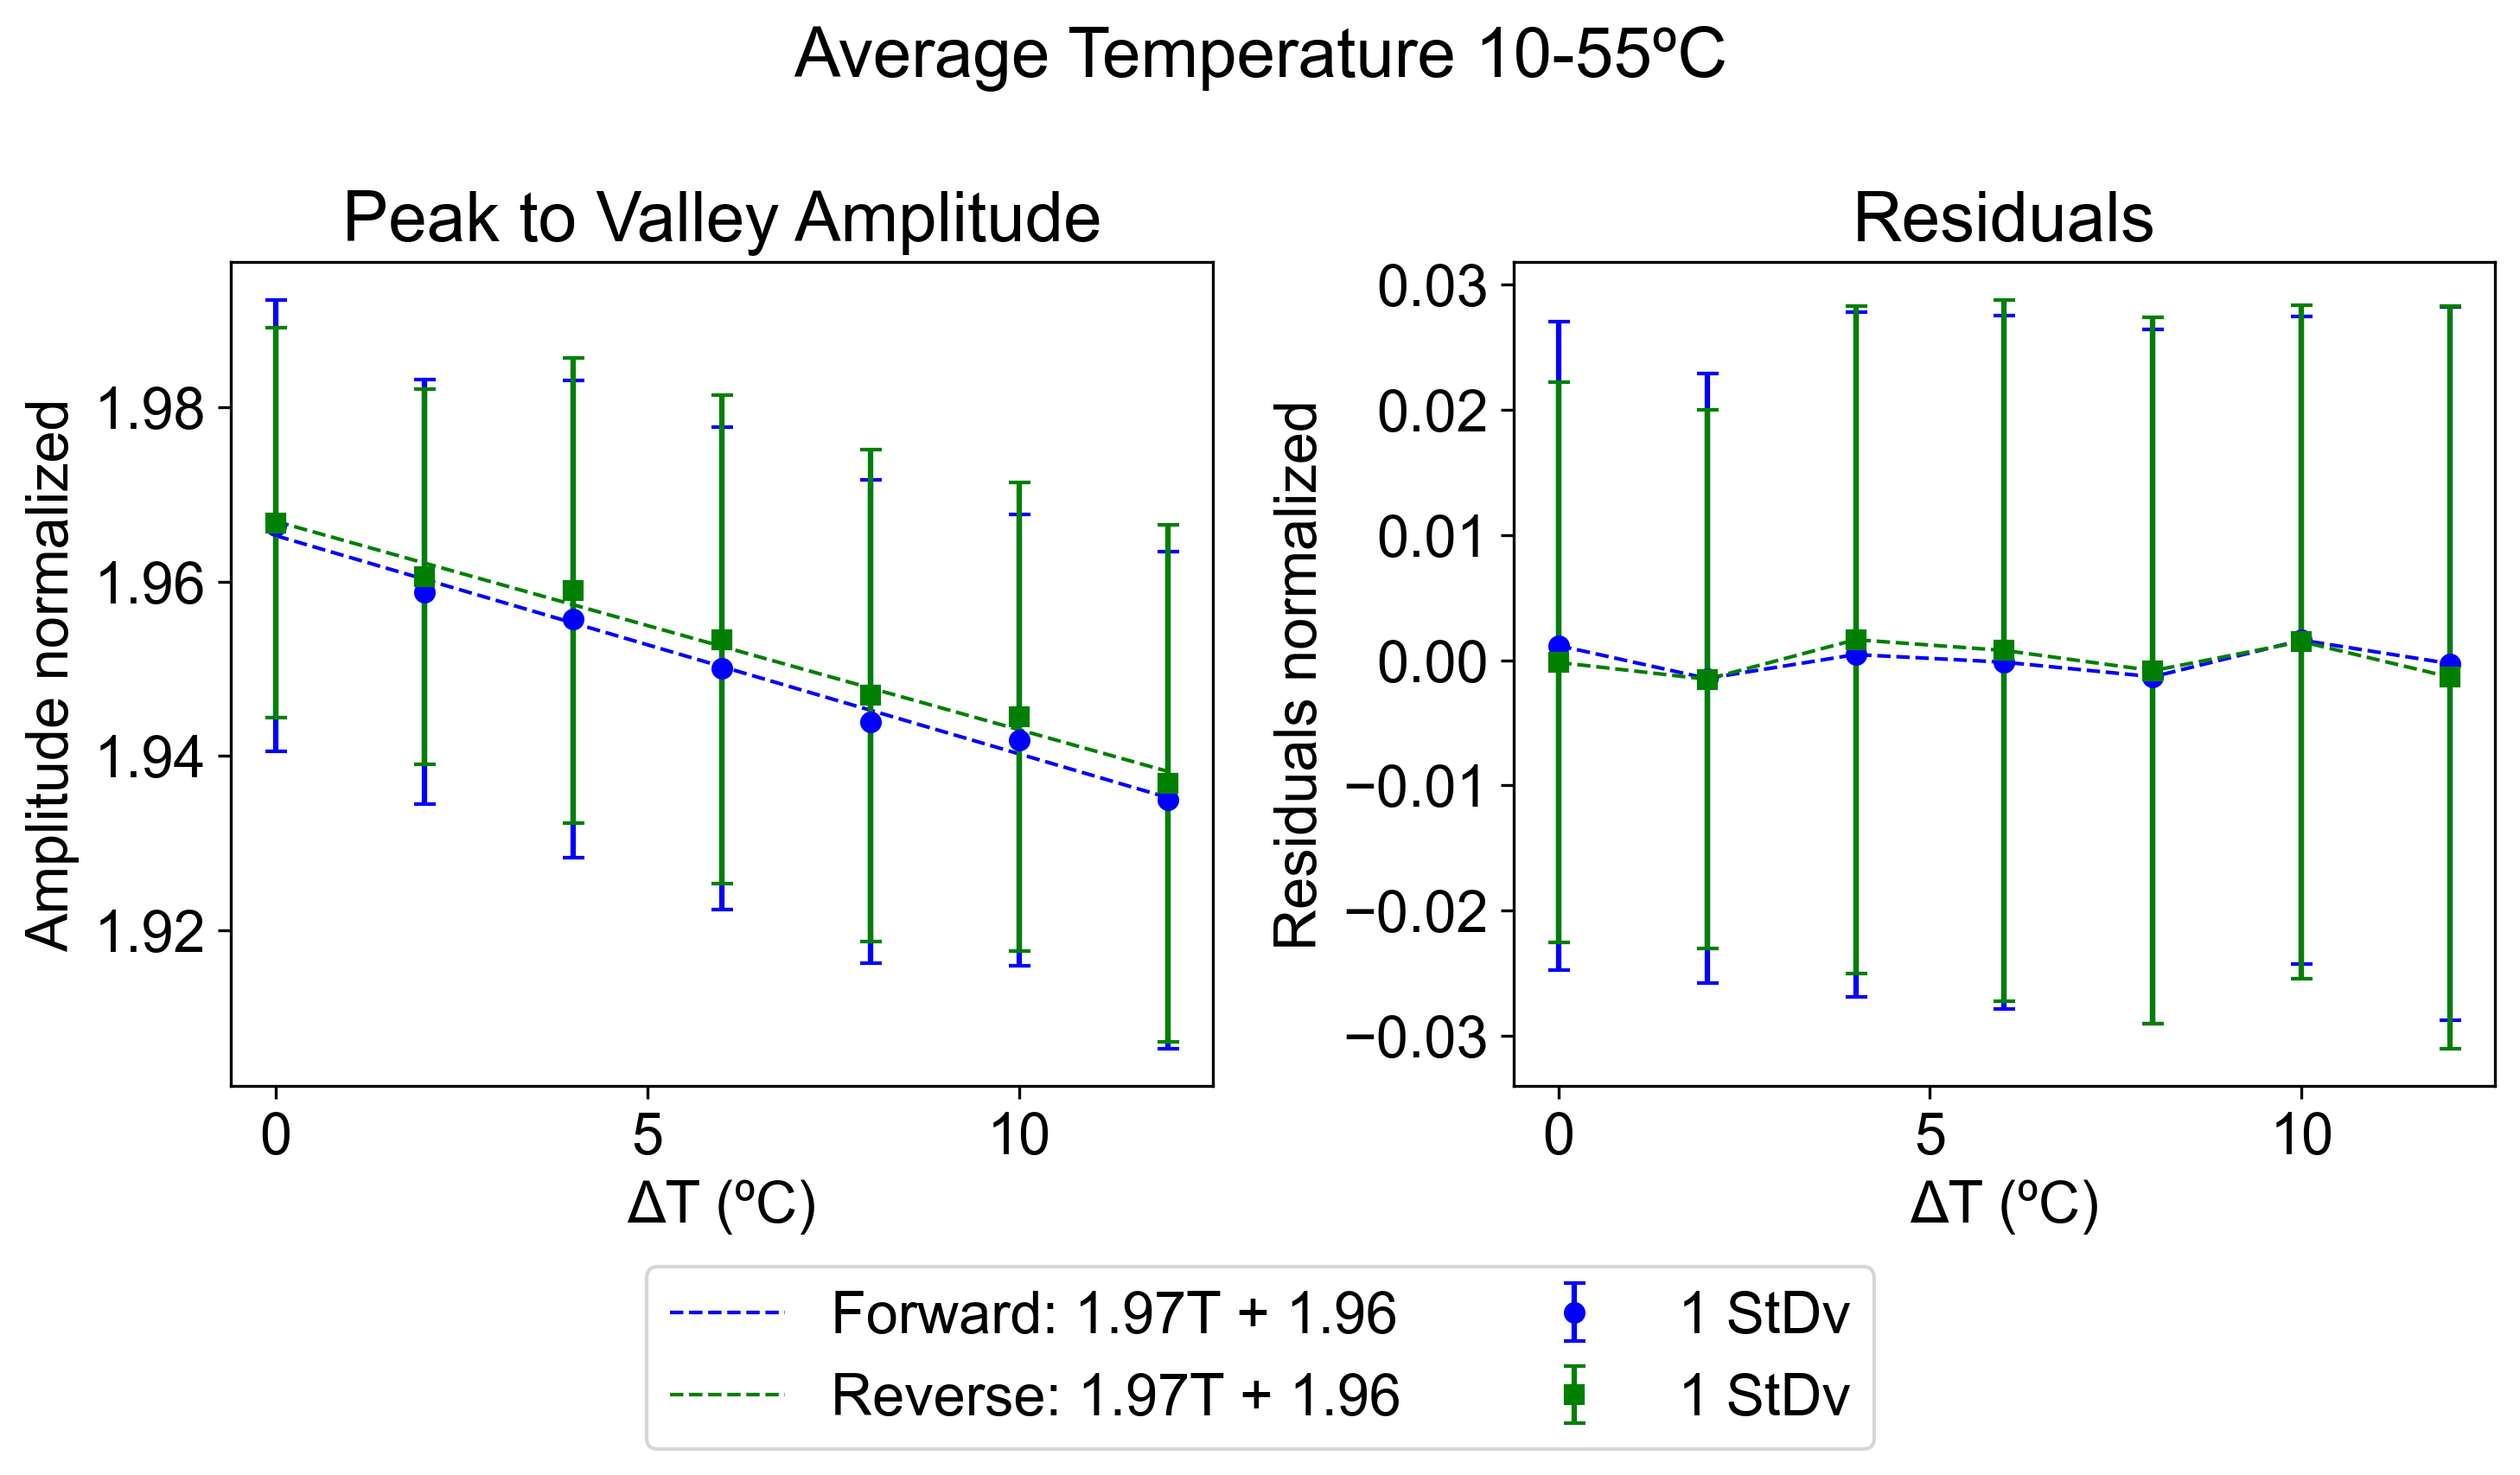

In [25]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Average Temperature 10-55ºC')

ax[0].plot(d_temps, f_amp_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_amp_fit[0]:.2f}T + {f_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_amp_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_amp_fit[0]:.2f}T + {r_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('Peak to Valley Amplitude')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_ylabel('Amplitude normalized')

ax[1].plot(d_temps, f_amp_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_amp_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_amp_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_amp_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_ylabel('Residuals normalized')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

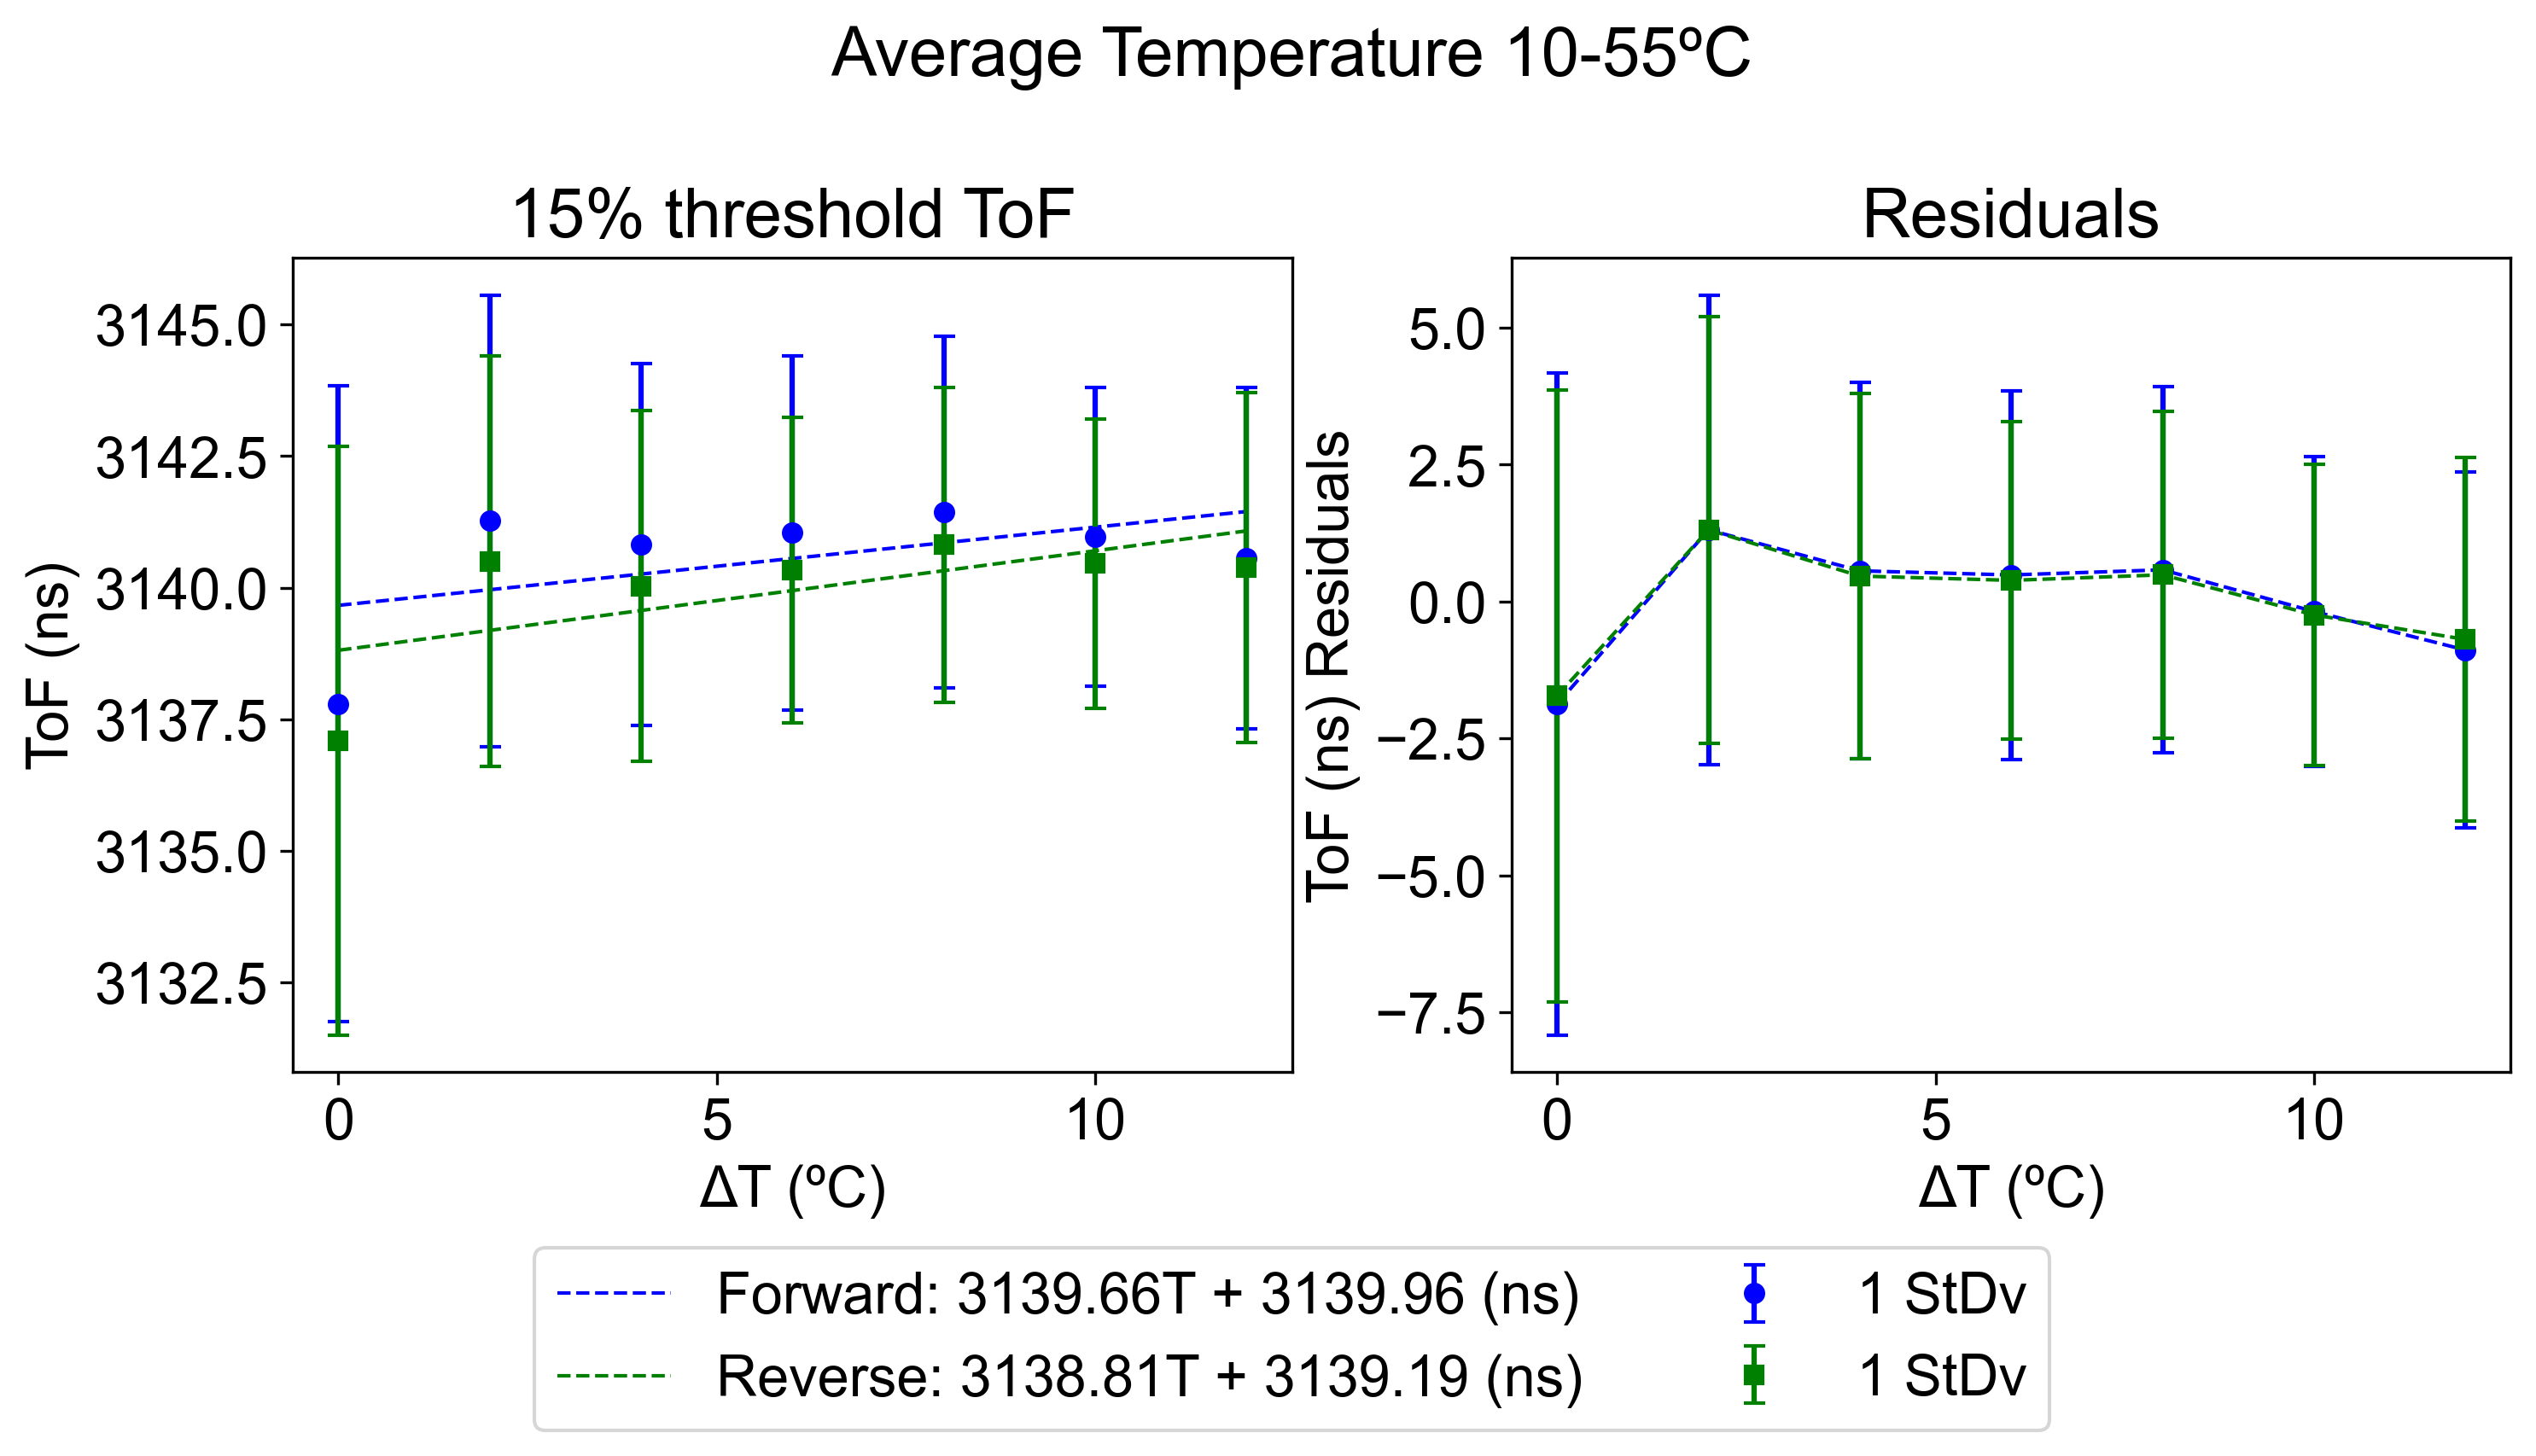

In [26]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Average Temperature 10-55ºC')

ax[0].plot(d_temps, f_simple_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_simple_tof_fit[0]:.2f}T + {f_simple_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, f_simple_tof_arr, yerr=f_simple_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_simple_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_simple_tof_fit[0]:.2f}T + {r_simple_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, r_simple_tof_arr, yerr=r_simple_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% threshold ToF')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_ylabel('ToF (ns)' )

ax[1].plot(d_temps, f_simple_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_simple_tof_residuals, yerr=f_simple_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_simple_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_simple_tof_residuals, yerr=r_simple_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_ylabel('ToF (ns) Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

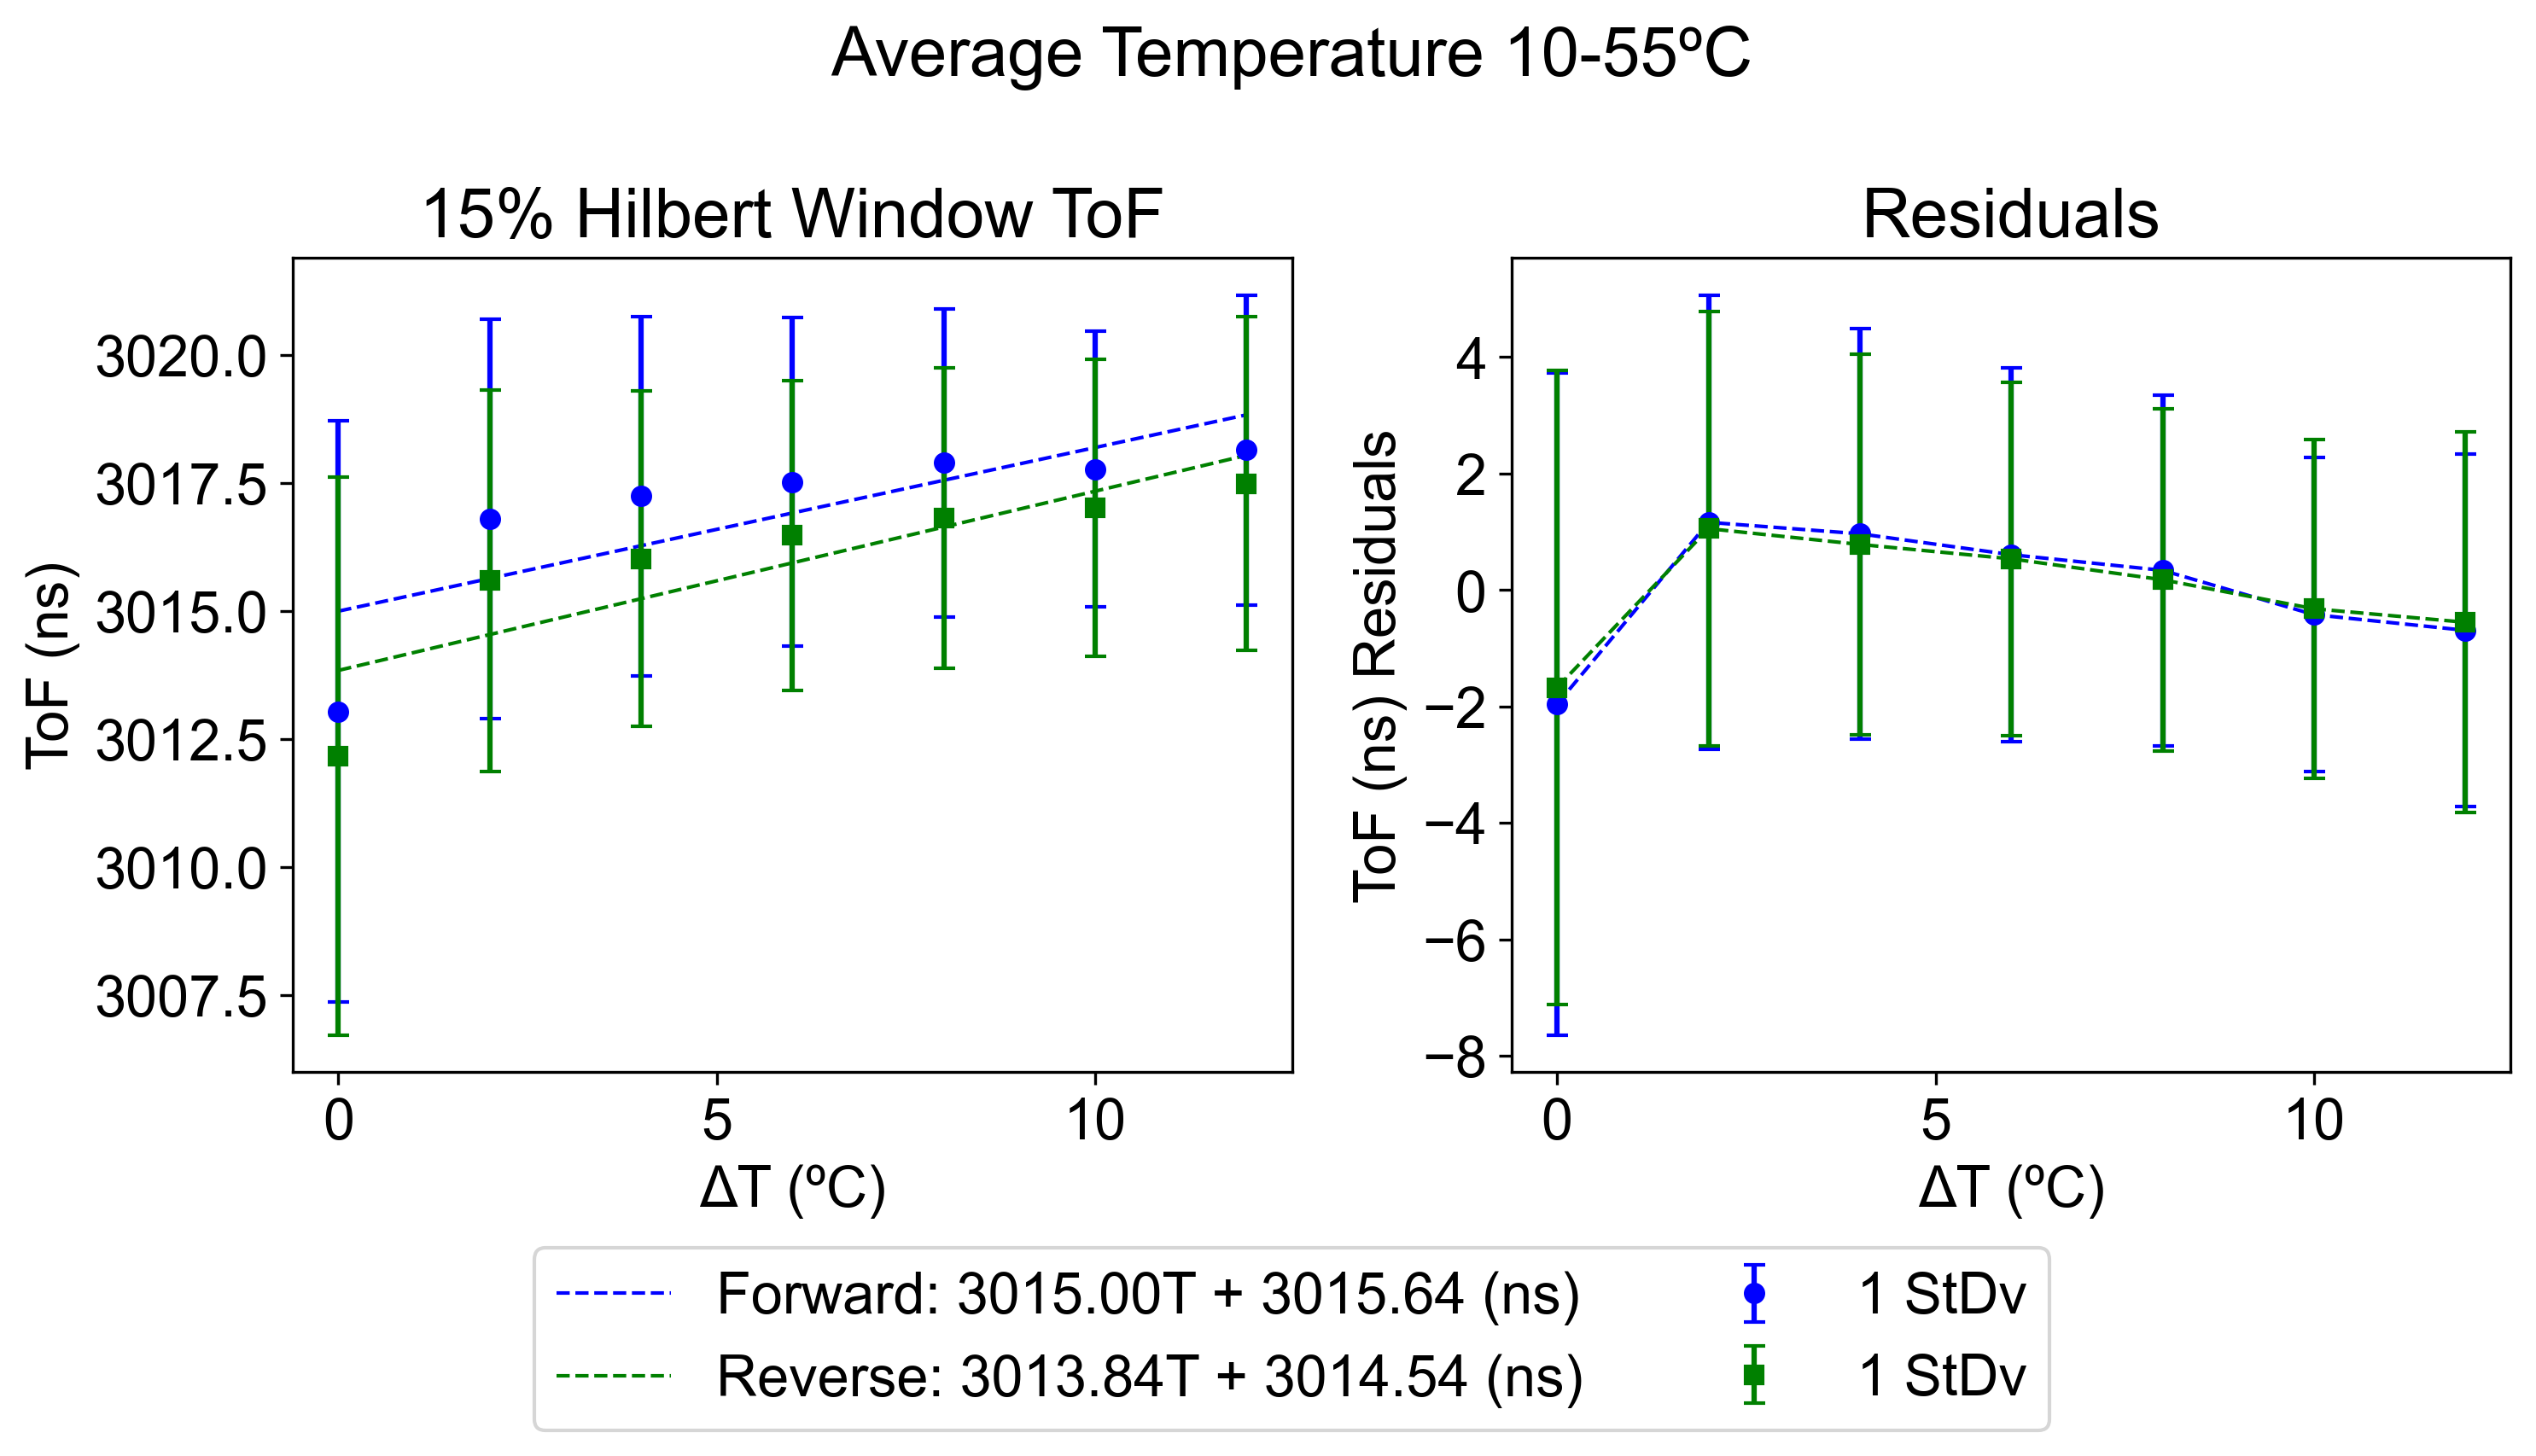

In [27]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Average Temperature 10-55ºC')

ax[0].plot(d_temps, f_hilbert_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_hilbert_tof_fit[0]:.2f}T + {f_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, f_hilbert_tof_arr, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_hilbert_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_hilbert_tof_fit[0]:.2f}T + {r_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, r_hilbert_tof_arr, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% Hilbert Window ToF')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_ylabel('ToF (ns)' )

ax[1].plot(d_temps, f_hilbert_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_hilbert_tof_residuals, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_hilbert_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_hilbert_tof_residuals, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_ylabel('ToF (ns) Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)
fig.tight_layout()

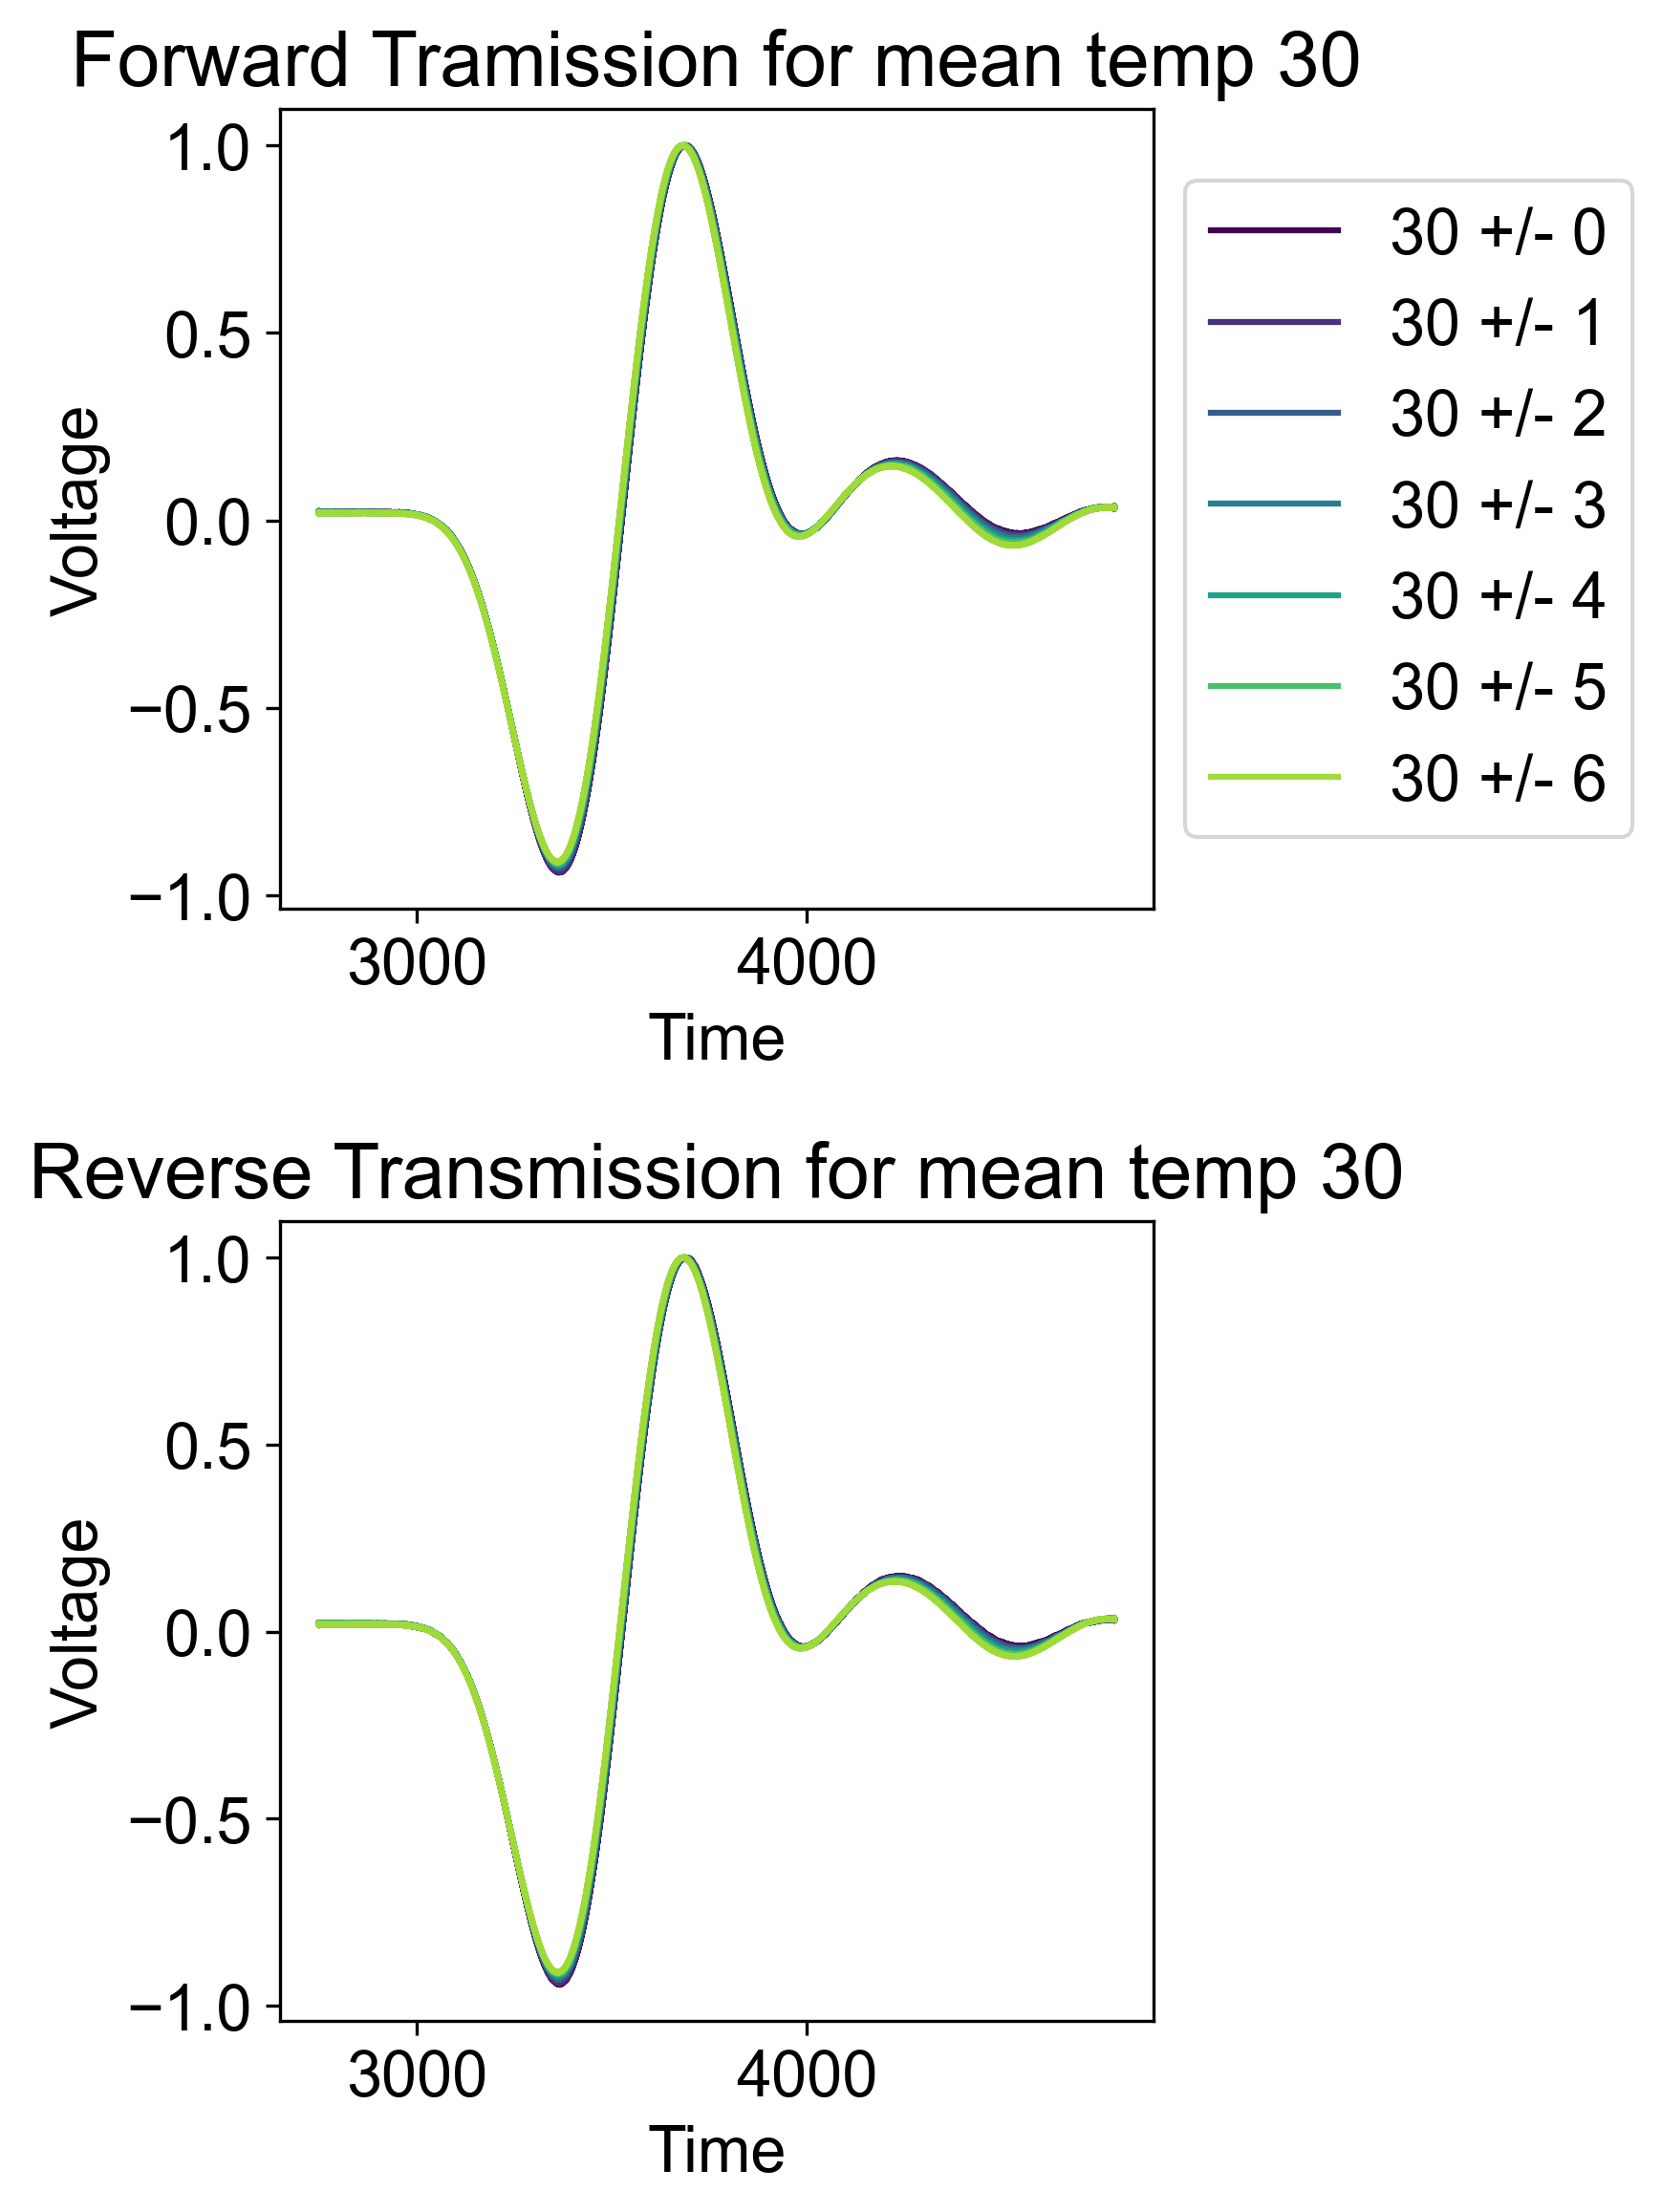

In [28]:
fig, ax = plt.subplots(2, figsize=(6, 8))
for i in range(7):
    mask = (merged_filtered_df['3000.1: CH1 Target'] == 30+i) & \
           (merged_filtered_df['3000.2: CH2 Target'] == 30-i) & \
           (merged_filtered_df.index > 750)
           
    for idx, row in merged_filtered_df.loc[mask].iloc[-10:].iterrows():
        ax[0].plot(
            row['time'][:1200],
            row['voltage_transmission_forward'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
        ax[1].plot(
            row['time'][:1200],
            row['voltage_transmission_reverse'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel('Voltage')
    ax[0].set_title(f'Forward Tramission for mean temp 30')
    ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Voltage')
    ax[1].set_title(f'Reverse Transmission for mean temp 30')
    
    fig.tight_layout()

## Stat tests

### PCA

In [29]:
import warnings
warnings.filterwarnings("ignore")

### for waveforms

Normally, data going into sklearn modules should have shape (n_samples, n_features). In the case of spectral data, each scan is a sample, and each point in time is a feature.

However in this case, we normalize the flattened data because we do not want to erase the effects of amplitude changes between scans.

In [30]:
merged_filtered_df.columns

Index(['voltage_transmission_forward', 'voltage_transmission_reverse', 'time',
       'time_collected', 'collection_index', 'exp_idx', 'Time',
       '1000.1: CH1 Object', '1000.2: CH2 Object', '1001.1: CH1 Sink',
       '1001.2: CH2 Sink', '1044.1: LR1 Temp', '1044.2: LR2 Temp',
       '1045.1: HR1 Temp', '1045.2: HR2 Temp', '3000.1: CH1 Target',
       '3000.2: CH2 Target', 'Time_str', '1200.1: Temperature is Stable',
       '1200.2: Temperature is Stable', '2010.1: Output Enable',
       '2010.2: Output Enable', '3034.1: Peltier Polarity',
       '3034.2: Peltier Polarity', 'index', 'mean_T (°C)', 'diff_T (°C)',
       'amplitude_forward_normalized', 'Simple_ToF_forward (ns)',
       'Hilbert_ToF_forward (ns)', 'amplitude_reverse_normalized',
       'Simple_ToF_reverse (ns)', 'Hilbert_ToF_reverse (ns)'],
      dtype='str')

In [31]:
merged_filtered_copy = merged_filtered_df.drop(['voltage_transmission_forward', 
                                                'voltage_transmission_reverse',
                                                'time', 
                                                '3034.2: Peltier Polarity',
                                                '3034.2: Peltier Polarity',
                                                '1200.1: Temperature is Stable',
                                                'Time_str',
                                                '2010.1: Output Enable',
                                                '2010.2: Output Enable',
                                                ], axis=1).copy()
merged_filtered_copy.tail()

,time_collected,collection_index,exp_idx,Time,1000.1: CH1 Object,1000.2: CH2 Object,1001.1: CH1 Sink,1001.2: CH2 Sink,1044.1: LR1 Temp,1044.2: LR2 Temp,...,3034.1: Peltier Polarity,index,mean_T (°C),diff_T (°C),amplitude_forward_normalized,Simple_ToF_forward (ns),Hilbert_ToF_forward (ns),amplitude_reverse_normalized,Simple_ToF_reverse (ns),Hilbert_ToF_reverse (ns)
3619,1.782765e+09,1634.0,2,1.782765e+09,37.990715,22.051050,19.303034,23.157251,19.303034,23.157251,...,Cooling,5644,30.020883,15.939665,1.883851,3142.672269,3020.280912,1.883922,3142.672269,3018.581032
3620,1.782765e+09,1635.0,2,1.782765e+09,37.991997,22.050592,19.307795,23.162226,19.307795,23.162226,...,Cooling,5645,30.021295,15.941404,1.882941,3142.672269,3020.280912,1.884585,3142.672269,3018.581032
3621,1.782765e+09,1636.0,2,1.782765e+09,37.990929,22.050806,19.306452,23.165949,19.306452,23.165949,...,Cooling,5646,30.020867,15.940123,1.882541,3142.672269,3018.581032,1.884406,3142.672269,3018.581032
3622,1.782765e+09,1637.0,2,1.782765e+09,37.990440,22.051294,19.309015,23.168665,19.309015,23.168665,...,Cooling,5647,30.020867,15.939146,1.882937,3142.672269,3018.581032,1.883958,3142.672269,3020.280912
3623,1.782765e+09,1638.0,2,1.782765e+09,37.991081,22.051600,19.310053,23.172144,19.310053,23.172144,...,Cooling,5648,30.021340,15.939482,1.883439,3142.672269,3018.581032,1.883993,3142.672269,3018.581032


In [32]:
np.stack(merged_filtered_copy.values)

array([[1782758706.1243255, 0.0, 0, ..., 1.8462707587349867,
        2947.186074429772, 2814.59543817527],
       [1782758706.8278189, 1.0, 0, ..., 1.845789866897141,
        2947.186074429772, 2814.59543817527],
       [1782758707.8368664, 2.0, 0, ..., 1.8444751647804876,
        2947.186074429772, 2814.59543817527],
       ...,
       [1782765152.1928499, 1636.0, 2, ..., 1.8844060914938465,
        3142.672268907563, 3018.581032412965],
       [1782765153.183154, 1637.0, 2, ..., 1.8839576114436816,
        3142.672268907563, 3020.280912364946],
       [1782765154.1911042, 1638.0, 2, ..., 1.883993301428564,
        3142.672268907563, 3018.581032412965]],
      shape=(3624, 25), dtype=object)

In [33]:
merged_filtered_copy

,time_collected,collection_index,exp_idx,Time,1000.1: CH1 Object,1000.2: CH2 Object,1001.1: CH1 Sink,1001.2: CH2 Sink,1044.1: LR1 Temp,1044.2: LR2 Temp,...,3034.1: Peltier Polarity,index,mean_T (°C),diff_T (°C),amplitude_forward_normalized,Simple_ToF_forward (ns),Hilbert_ToF_forward (ns),amplitude_reverse_normalized,Simple_ToF_reverse (ns),Hilbert_ToF_reverse (ns)
0,1.782759e+09,0.0,0,1.782759e+09,10.011347,9.781397,27.618616,26.006006,27.618616,26.006006,...,Cooling,0,9.896372,0.229950,1.845007,2947.186074,2814.595438,1.846271,2947.186074,2814.595438
1,1.782759e+09,1.0,0,1.782759e+09,9.979273,9.763300,27.623621,26.021418,27.623621,26.021418,...,Cooling,1,9.871286,0.215973,1.845131,2947.186074,2814.595438,1.845790,2947.186074,2814.595438
2,1.782759e+09,2.0,0,1.782759e+09,9.950434,9.751184,27.626093,26.038263,27.626093,26.038263,...,Cooling,2,9.850809,0.199249,1.844013,2947.186074,2814.595438,1.844475,2947.186074,2814.595438
3,1.782759e+09,71.0,0,1.782759e+09,9.752527,9.822718,25.937403,25.584436,25.937403,25.584436,...,Cooling,71,9.787622,-0.070190,1.843034,2950.585834,2816.295318,1.844081,2950.585834,2814.595438
4,1.782759e+09,72.0,0,1.782759e+09,9.753473,9.820673,25.918573,25.583307,25.918573,25.583307,...,Cooling,72,9.787073,-0.067200,1.843516,2950.585834,2816.295318,1.844340,2950.585834,2816.295318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3619,1.782765e+09,1634.0,2,1.782765e+09,37.990715,22.051050,19.303034,23.157251,19.303034,23.157251,...,Cooling,5644,30.020883,15.939665,1.883851,3142.672269,3020.280912,1.883922,3142.672269,3018.581032
3620,1.782765e+09,1635.0,2,1.782765e+09,37.991997,22.050592,19.307795,23.162226,19.307795,23.162226,...,Cooling,5645,30.021295,15.941404,1.882941,3142.672269,3020.280912,1.884585,3142.672269,3018.581032
3621,1.782765e+09,1636.0,2,1.782765e+09,37.990929,22.050806,19.306452,23.165949,19.306452,23.165949,...,Cooling,5646,30.020867,15.940123,1.882541,3142.672269,3018.581032,1.884406,3142.672269,3018.581032
3622,1.782765e+09,1637.0,2,1.782765e+09,37.990440,22.051294,19.309015,23.168665,19.309015,23.168665,...,Cooling,5647,30.020867,15.939146,1.882937,3142.672269,3018.581032,1.883958,3142.672269,3020.280912


In [34]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
scaler = Pipeline([('standard', StandardScaler()), ('minmax', MinMaxScaler())]) # scaler inputs are in format 
signal_keys = ['voltage_transmission_forward', 'voltage_transmission_reverse']

# X =np.stack( [ np.stack(merged_filtered_df[key].values) for key in signal_keys ])

data_rescaled = scaler.fit_transform(X.reshape(-1, 1)).reshape(X.shape)
data_rescaled.shape

NameError: name 'X' is not defined

We do not usually need all components to capture trends in the data. Almost all variance is explained in the first 6 components

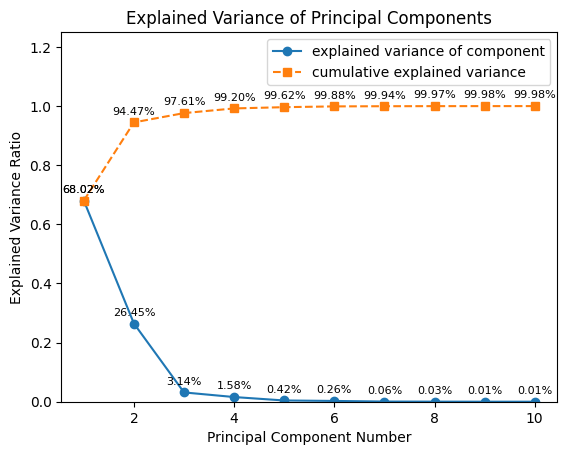

In [ ]:
from  sklearn.decomposition import PCA
from tqdm import tqdm

components=10
pca = PCA(n_components=components)
transformed = pca.fit_transform(data_rescaled.reshape(-1, data_rescaled.shape[-1])).reshape(data_rescaled.shape[0], data_rescaled.shape[1], components)

fig, ax = plt.subplots()
x = np.arange(1, components + 1)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

ax.plot(x, explained, marker='o', label='explained variance of component')
for xi, ex in zip(x, explained):  ax.text(xi, ex + 0.02, f'{ex:.2%}', ha='center', va='bottom', fontsize=8)

ax.plot(x, cumulative, marker='s', linestyle='--', label='cumulative explained variance')
for xi, cum in zip(x, cumulative):  ax.text(xi, cum + 0.02, f'{cum:.2%}', ha='center', va='bottom', fontsize=8)

ax.set_title('Explained Variance of Principal Components')
ax.set_xlabel('Principal Component Number')
ax.set_ylabel('Explained Variance Ratio')
ax.set_ylim(0, 1.25)
ax.legend()

In [ ]:
import math
import matplotlib.colors as mcolors

def plot_PCs(transformed, pc_s, color_by_column, marker_categories=0, skip_=10):
    '''Plot scatter plots of the first 6 principal components'''
    color_vals = merged_filtered_df[color_by_column].values
    cvals = color_vals[::skip_]
    norm = mcolors.Normalize(vmin=cvals.min(), vmax=cvals.max())  # fixed range, built once
    cmap = plt.cm.viridis

    markers_ = ['o','^','v', 's','x', '_','.', '+',  '*', '<', '>', 'p', 'h']
        
    combos = math.comb(pc_s, 2)
    x_, y_ = int(combos**0.5), math.ceil(combos/int(combos**0.5))
    fig, ax = plt.subplots(x_, y_, figsize=(3*y_+0.5, 3*x_))
    fig.suptitle(f'PCA Scatter Plots comparing First {pc_s} Principal Components, colored by {color_by_column} value')
    ax = ax.flatten()
    if combos < x_*y_:
        for a in ax[-(x_*y_-combos):]: fig.delaxes(a)  # remove any extra axes if the grid is larger than the number of combinations

    ind = 0
    for i in range(pc_s):
        for j in range(i+1, pc_s):
            
            if marker_categories:
                for m,label in enumerate(marker_categories):
                    ax[ind].scatter(transformed[m, :, i][::skip_], transformed[m, :, j][::skip_], 
                                     marker=markers_[m], s=y_*10, linewidths=0.25,
                                     edgecolors=cmap(norm(color_vals[::skip_])),
                                     facecolors='none', label=label)
                    
                fig.legend(labels=marker_categories, loc='lower center', ncol=len(marker_categories), bbox_to_anchor=(0.5, -0.05))
                    
            else: ax[ind].scatter(transformed[:, i][::skip_], transformed[:, j][::skip_], marker='o', s=y_*10, c=color_vals[::skip_], cmap=cmap, norm=norm)

            ax[ind].set_title(f'x:PC{i+1}, y:PC{j+1}')
            ind += 1
            
    fig.tight_layout()
    # carve out space on the right, then place a colorbar axes there
    fig.subplots_adjust(right=0.90)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height] in figure coords
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label=f'{color_by_column}')

In [ ]:
merged_filtered_df.columns # select which column to color by

Index(['voltage_transmission_forward', 'voltage_transmission_reverse', 'time',
       'time_collected', 'collection_index', 'Time', '1000.1: CH1 Object',
       '1000.2: CH2 Object', '1001.1: CH1 Sink', '1001.2: CH2 Sink',
       '1044.1: LR1 Temp', '1044.2: LR2 Temp', '1045.1: HR1 Temp',
       '1045.2: HR2 Temp', '3000.1: CH1 Target', '3000.2: CH2 Target',
       'Time_str', '1200.1: Temperature is Stable',
       '1200.2: Temperature is Stable', '2010.1: Output Enable',
       '2010.2: Output Enable', '3034.1: Peltier Polarity',
       '3034.2: Peltier Polarity', 'index', 'means', 'diff',
       'amplitude_forward', 'Simple ToF_forward', 'Hilbert ToF_forward',
       'amplitude_reverse', 'Simple ToF_reverse', 'Hilbert ToF_reverse',
       'Hilbert_ToF_diff', 'amplitude_diff'],
      dtype='str')

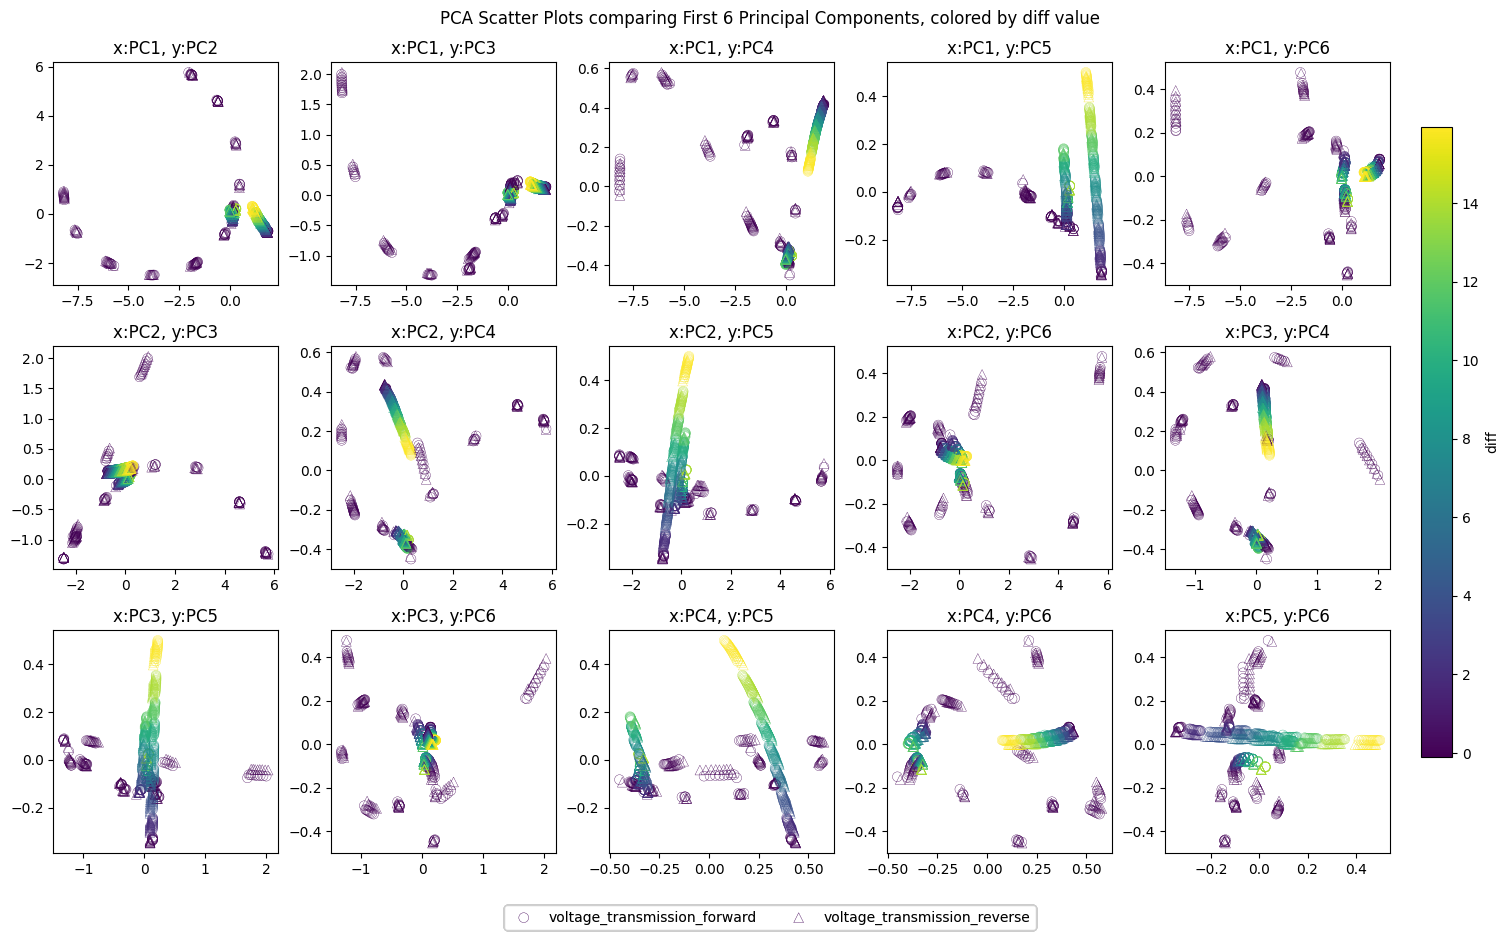

In [ ]:
plot_PCs(transformed=transformed, 
         pc_s=6,
         color_by_column='diff',
         marker_categories=['voltage_transmission_forward', 'voltage_transmission_reverse'])

In [ ]:
merged_filtered_df['amplitude_diff'] = merged_filtered_df['amplitude_forward']-merged_filtered_df['amplitude_reverse']

(array([  3.,  41.,  49.,  95.,  98.,  94.,  82.,  67.,  52.,  57.,  57.,
         71., 132., 189., 215., 219., 207., 180., 170., 209., 253., 241.,
        221., 177., 152., 129., 101.,  46.,  16.,   1.]),
 array([-5.79055509, -5.50769922, -5.22484336, -4.94198749, -4.65913163,
        -4.37627576, -4.0934199 , -3.81056403, -3.52770817, -3.2448523 ,
        -2.96199644, -2.67914057, -2.39628471, -2.11342884, -1.83057298,
        -1.54771711, -1.26486125, -0.98200538, -0.69914952, -0.41629365,
        -0.13343779,  0.14941808,  0.43227394,  0.71512981,  0.99798567,
         1.28084154,  1.5636974 ,  1.84655327,  2.12940913,  2.412265  ,
         2.69512086]),
 <BarContainer object of 30 artists>)

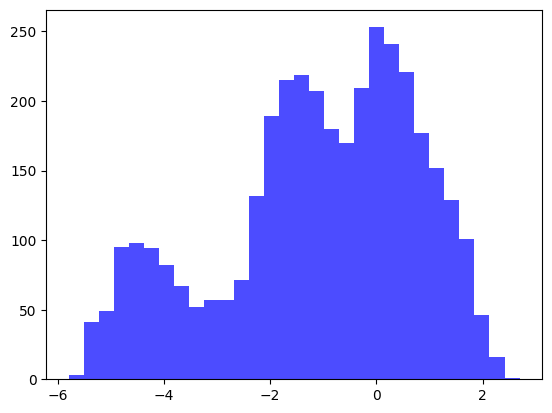

In [ ]:
plt.hist(merged_filtered_df['amplitude_diff'], bins=30, color='blue', alpha=0.7)

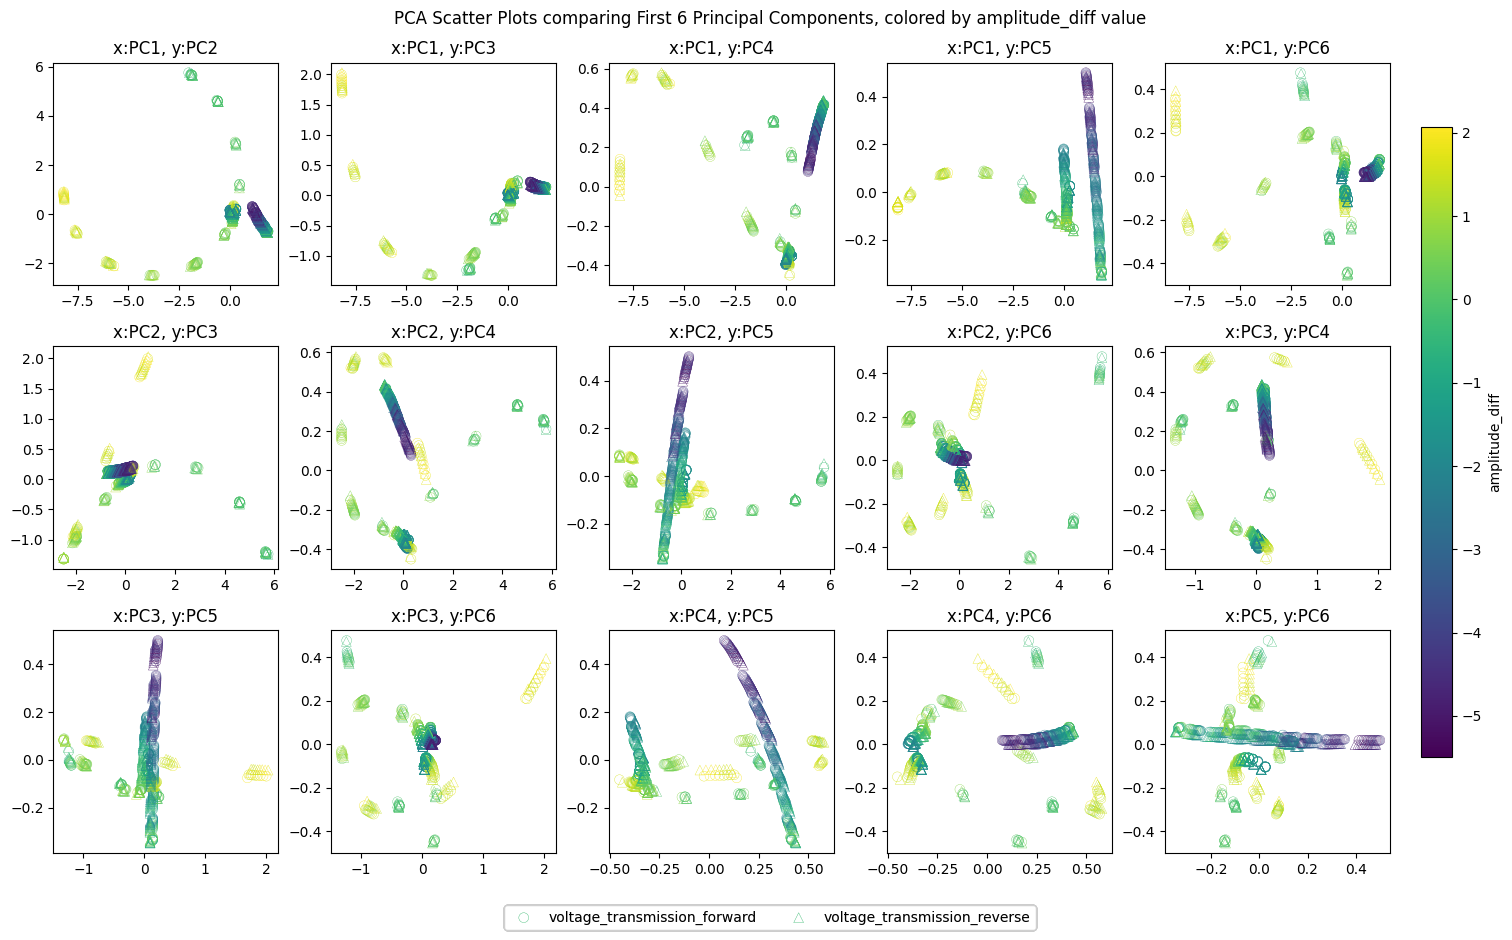

In [ ]:
plot_PCs(transformed=transformed, 
         pc_s=6,
         color_by_column='amplitude_diff',
         marker_categories=['voltage_transmission_forward', 'voltage_transmission_reverse'],
         skip_=10)